# 08. Portfolio Construction

Construct investment signals and portfolio weights from out-of-sample (OOS) predictions generated by **Ridge**, **XGBoost**, and **Random Forest** models. This notebook systematically constructs long-only and long-short portfolios across various selection and weighting regimes. Comprehensive performance and risk evaluation will follow in **Notebook 09**.

## 1. Setup & Configuration

### 1.1 Imports

In [1]:
import sys
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import warnings
import joblib

from pathlib import Path
from scipy.stats import spearmanr

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

### 1.2 Experiment Parameters

Set baseline execution configuration for signal selection, portfolio rebalancing, and gross/net exposure targets.


In [2]:
# =============================================================================
# Experiment Configuration
# =============================================================================

# Prediction horizon
PREDICTION_HORIZON = 21

# Rebalancing
# Benchmark frequency; alternative frequencies will be evaluated later.
REBALANCING_FREQUENCY = 21

# Portfolio selection
SELECTION_PERCENTS = [0.10, 0.20, 0.30]

# Benchmark selection
BENCHMARK_SELECTION = 0.10

# Long-only exposure
LONG_ONLY_GROSS_EXPOSURE = 1.00

# Long-short exposure
LONG_SHORT_LONG_EXPOSURE = 0.50
LONG_SHORT_SHORT_EXPOSURE = 0.50

# Position selection
POSITION_COUNT_MODE = "quantile"

In [3]:
# =============================================================================
# Exposure Validation
# =============================================================================

assert (
    LONG_SHORT_LONG_EXPOSURE >= 0
    and LONG_SHORT_SHORT_EXPOSURE >= 0
)

assert (
    LONG_SHORT_LONG_EXPOSURE
    + LONG_SHORT_SHORT_EXPOSURE
    > 0
)

In [4]:
# =============================================================================
# Paths
# =============================================================================

OOS_DATA_PATH = "../data/model_results/final_model/oos/"
PREDICTIONS_PATH = (OOS_DATA_PATH + "oos_predictions.parquet")

# Path to price data (OOS included)
PRICES_PATH = "../data/raw/sp500_prices_extended.parquet"

# =============================================================================
# Models
# =============================================================================

MODEL_COLUMNS = {
    "Ridge": "prediction_ridge_rank",
    "XGBoost": "prediction_xgb_rank",
    "Random Forest": "prediction_rf_rank",
}

# =============================================================================
# Required Columns
# =============================================================================

REQUIRED_COLUMNS = [
    "prediction_ridge_rank",
    "prediction_xgb_rank",
    "prediction_rf_rank",
    "forward_return_21d",
]

# =============================================================================
# Signal Configuration
# =============================================================================

PREDICTION_COLUMNS = list(MODEL_COLUMNS.values())

RANKING_METHOD = "cross_sectional_percentile"

## 2. Data Loading & Alignment

### 2.1 Out-of-Sample Predictions

Load out-of-sample predictions generated by upstream models and verify table structure.

In [5]:
# =============================================================================
# Load OOS Predictions
# =============================================================================

oos_predictions = pd.read_parquet(PREDICTIONS_PATH)

print(f"OOS predictions shape: {oos_predictions.shape}")
print(f"Date range: {oos_predictions.index.get_level_values('date').min()} "
      f"→ {oos_predictions.index.get_level_values('date').max()}")

OOS predictions shape: (184408, 7)
Date range: 2025-01-15 00:00:00 → 2026-07-10 00:00:00


In [6]:
# =============================================================================
# Prediction Columns Check
# =============================================================================

missing_prediction_columns = [
    column
    for column in PREDICTION_COLUMNS
    if column not in oos_predictions.columns
]

assert not missing_prediction_columns, (
    f"Missing prediction columns: {missing_prediction_columns}"
)

# =============================================================================
# Index Check
# =============================================================================

assert isinstance(oos_predictions.index, pd.MultiIndex)
assert oos_predictions.index.names == ["date", "ticker"]

# =============================================================================
# Prediction Availability Check
# =============================================================================

assert oos_predictions[PREDICTION_COLUMNS].notna().any().all(), (
    "At least one prediction column contains no valid observations."
)

### 2.2 Extended Price Data & Universe Realignment

Load historical price data and restrict the target universe strictly to tickers present in the OOS predictions. Retain pre-OOS history for downstream risk matrix estimation.

In [7]:
# =============================================================================
# Load Extended Price Data
# =============================================================================

prices = pd.read_parquet(PRICES_PATH)

# =============================================================================
# Align Price Universe with OOS Universe
# =============================================================================

oos_tickers = oos_predictions.index.get_level_values("ticker").unique()

price_tickers = prices.columns.get_level_values(1)

missing_price_tickers = oos_tickers.difference(price_tickers)

assert len(missing_price_tickers) == 0, (
    f"Missing price data for tickers: "
    f"{missing_price_tickers.tolist()}"
)

prices = prices.loc[
    :,
    prices.columns.get_level_values(1).isin(oos_tickers)
]

# =============================================================================
# Compute Returns
# =============================================================================

adj_close = prices["Adj Close"]

simple_returns = adj_close.pct_change()

log_returns = np.log(
    adj_close / adj_close.shift(1)
)

In [8]:
print(
    f"Price data coverage: "
    f"{prices.index.min().date()} → {prices.index.max().date()}"
)

print(f"Number of securities: {len(oos_tickers)}")

Price data coverage: 2010-01-04 → 2026-08-10
Number of securities: 496


### 2.3 Data Integrity & Temporal Alignment Checks

Execute safety assertions confirming date coverage overlap, return alignments, and availability before downstream portfolio construction.

In [9]:
# =============================================================================
# Temporal Coverage
# =============================================================================

oos_dates = (
    oos_predictions.index
    .get_level_values("date")
    .unique()
)

assert oos_dates.min() >= prices.index.min()
assert oos_dates.max() <= prices.index.max()

# =============================================================================
# Ticker Coverage
# =============================================================================

oos_tickers = (
    oos_predictions.index
    .get_level_values("ticker")
    .unique()
)

price_tickers = (
    prices.columns
    .get_level_values(1)
    .unique()
)

missing_price_tickers = oos_tickers.difference(price_tickers)

assert len(missing_price_tickers) == 0, (
    f"Missing price data for tickers: "
    f"{missing_price_tickers.tolist()}"
)

# =============================================================================
# Prediction Date Coverage
# =============================================================================

missing_prediction_dates = oos_dates.difference(
    prices.index
)

assert len(missing_prediction_dates) == 0, (
    f"Missing price data for OOS dates: "
    f"{missing_prediction_dates.tolist()}"
)

# =============================================================================
# Returns Alignment
# =============================================================================

assert simple_returns.index.equals(prices.index)
assert log_returns.index.equals(prices.index)

assert simple_returns.columns.equals(adj_close.columns)
assert log_returns.columns.equals(adj_close.columns)

# =============================================================================
# Data Availability
# =============================================================================

assert simple_returns.notna().any().all(), (
    "Some securities contain no valid simple returns."
)

assert log_returns.notna().any().all(), (
    "Some securities contain no valid log returns."
)

## 3. Signal Construction

### 3.1 Cross-sectional Ranking

Las predicciones OOS de Ridge, XGBoost y Random Forest se transforman en rankings cross-sectional diarios para ordenar los activos según la intensidad relativa de su señal. El ranking se calcula únicamente sobre los activos que disponen de una predicción válida en cada fecha, respetando el universo efectivamente disponible durante el periodo OOS. 

In [10]:
# =============================================================================
# Cross-sectional Ranking
# =============================================================================

signal_ranks = pd.DataFrame(
    index=oos_predictions.index
)

RANK_COLUMNS = {}

for model, prediction_column in MODEL_COLUMNS.items():

    rank_column = f"{model.lower().replace(' ', '_')}_rank"

    signal_ranks[rank_column] = (
        oos_predictions
        .groupby(level="date")[prediction_column]
        .rank(
            method="first",
            pct=True,
        )
    )

    RANK_COLUMNS[model] = rank_column

In [11]:
# =============================================================================
# Ranking Validation
# =============================================================================

for rank_column in RANK_COLUMNS.values():

    assert signal_ranks[rank_column].dropna().between(0, 1).all(), (
        f"Invalid values found in {rank_column}."
    )

# =============================================================================
# Cross-sectional Coverage
# =============================================================================

rank_counts = (
    signal_ranks
    .groupby(level="date")
    .size()
)

print(
    f"Cross-sectional observations per date: "
    f"Min = {rank_counts.min()} | "
    f"Max = {rank_counts.max()}"
)

Cross-sectional observations per date: Min = 494 | Max = 496


### 3.2 Quantile Formation

El ranking cross-sectional continuo se divide en diez grupos de tamaño aproximadamente equivalente, desde D1, que contiene los activos con las predicciones relativas más bajas, hasta D10, que contiene los activos con las predicciones más altas. La formación de los grupos se realiza diariamente, utilizando únicamente los activos disponibles en cada fecha.

Debido al elevado número de empates presente en las predicciones de los modelos basados en árboles, especialmente XGBoost, se utiliza un ranking determinista (method="first") para resolver los empates antes de formar los cuantiles. De esta forma se evitan grupos excesivamente desiguales y se garantiza una comparación homogénea entre modelos. Esta decisión únicamente afecta a la asignación de observaciones a grupos y no modifica las predicciones originales.


In [12]:
# =============================================================================
# Quantile Formation
# =============================================================================

quantile_data = pd.DataFrame(
    index=signal_ranks.index
)

QUANTILE_COLUMNS = {}

for model, rank_column in RANK_COLUMNS.items():

    quantile_column = (
        f"{model.lower().replace(' ', '_')}_quantile"
    )

    quantile_data[quantile_column] = (
        np.ceil(
            signal_ranks[rank_column] * 10
        )
        .clip(upper=10)
        .astype("Int64")
    )

    QUANTILE_COLUMNS[model] = quantile_column

In [13]:
# =============================================================================
# Quantile Distribution
# =============================================================================

quantile_counts = {}

for model, quantile_column in QUANTILE_COLUMNS.items():

    counts = (
        quantile_data
        .groupby(level="date")[quantile_column]
        .value_counts()
        .unstack(fill_value=0)
    )

    quantile_counts[model] = counts

for model, counts in quantile_counts.items():

    print("=" * 80)
    print(f"{model} — QUANTILE SIZE RANGE")

    print(
        f"Min = {counts.min().min()} | "
        f"Max = {counts.max().max()}"
    )

Ridge — QUANTILE SIZE RANGE
Min = 49 | Max = 50
XGBoost — QUANTILE SIZE RANGE
Min = 49 | Max = 50
Random Forest — QUANTILE SIZE RANGE
Min = 49 | Max = 50


### 3.3 Signal Distribution Analysis

Antes de utilizar los rankings para construir las carteras, se analiza su distribución cross-sectional durante el periodo OOS. El objetivo es comprobar que las señales presentan suficiente dispersión entre activos y detectar posibles concentraciones, valores extremos o diferencias estructurales entre modelos que puedan afectar a la selección y posterior asignación de pesos. Dado que los rankings se construyen mediante percentiles cross-sectional, se presta especial atención a la distribución de las predicciones originales y al comportamiento de los grupos por cuantiles.


#### 3.3.1 Distribución de las predicciones

In [14]:
# =============================================================================
# Prediction Distribution
# =============================================================================

prediction_distribution = (
    oos_predictions[
        list(MODEL_COLUMNS.values())
    ]
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
        ]
    ]
)

display(prediction_distribution)

# =============================================================================
# Unique Prediction Values
# =============================================================================

unique_predictions = pd.DataFrame(
    {
        model: [
            oos_predictions[prediction_column]
            .nunique()
        ]
        for model, prediction_column in MODEL_COLUMNS.items()
    },
    index=["Unique values"],
).T

display(unique_predictions)

,count,mean,std,min,25%,50%,75%,max
prediction_ridge_rank,184408.0,0.014807,0.004190,0.005012,0.011615,0.014853,0.017929,0.024854
prediction_xgb_rank,184408.0,0.014821,0.003660,0.013136,0.013136,0.013318,0.015174,0.057154
prediction_rf_rank,184408.0,0.015472,0.009112,0.011264,0.012054,0.013353,0.015931,0.159783


,Unique values
Ridge,182612
XGBoost,285
Random Forest,4680


El análisis descriptivo de las predicciones fuera de muestra revela marcadas diferencias en la naturaleza estadística de cada arquitectura. Mientras que el modelo lineal Ridge genera una distribución continua con una elevada granulatividad (182,612 valores únicos), los modelos basados en árboles muestran una clara concentración discreta. 

En particular, XGBoost comprime el universo de predicciones en apenas 285 valores únicos, provocando que más del $50\%$ de las observaciones colapsen en un valor idéntico ($0.013136$). Por su parte, Random Forest presenta una mayor variabilidad ($\sigma = 0.009112$) y una pronunciada asimetría hacia la cola derecha, alcanzando predicciones puntuales de hasta el $15.98\%$. 

A pesar de estas diferencias morfológicas en la distribución de las salidas, los tres modelos mantienen una media de retorno predicho altamente coherente entre sí ($\approx 1.48\% - 1.55\%$). Esta acusada presencia de empates en XGBoost y Random Forest ratifica la necesidad de aplicar un ranking determinista (method="first") para garantizar una división equitativa y homogénea del universo en cuantiles.

#### 3.3.2 Distribución de los rankings

In [15]:
# =============================================================================
# Ranking Distribution
# =============================================================================

rank_distribution = (
    signal_ranks
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
        ]
    ]
)

display(rank_distribution)

,count,mean,std,min,25%,50%,75%,max
ridge_rank,184408.0,0.501009,0.288675,0.002016,0.251012,0.50101,0.751012,1.0
xgboost_rank,184408.0,0.501009,0.288675,0.002016,0.251012,0.50101,0.751012,1.0
random_forest_rank,184408.0,0.501009,0.288675,0.002016,0.251012,0.50101,0.751012,1.0


Tras la transformación a percentiles diarios ($[0, 1]$), la distribución de las tres señales converge exactamente a una distribución uniforme teórica $\mathcal{U}(0, 1)$. Los tres modelos presentan una media y mediana centradas en $0.5010$ y una desviación estándar idéntica a la teórica ($\sigma \approx 0.2887$). 

Esta estandarización elimina las diferencias de escala previas entre algoritmos, garantizando un punto de partida homogéneo y simétrico para la división en deciles ($D1$ a $D10$).

Aclarar que la coincidencia hasta el sexto decimal se debe a que el tamaño del universo de activos ($N_t$) y la secuencia de posiciones de ranking aplicadas en cada fecha $t$ son exactamente idénticas para los tres modelos. Dado que el percentil se calcula mediante una transformación determinista fija ($r_i / N_t$), la distribución empírica resultante es matemáticamente invariable e independiente de los valores crudos predichos por cada algoritmo, dependiendo de forma exclusiva de la estructura temporal de $N_t$.

#### 3.3.3 Distribución de los cuantiles

In [16]:
# =============================================================================
# Quantile Distribution
# =============================================================================

quantile_distribution = {}

for model, quantile_column in QUANTILE_COLUMNS.items():

    counts = (
        quantile_data[quantile_column]
        .value_counts()
        .sort_index()
    )

    quantile_distribution[model] = counts

quantile_distribution = pd.DataFrame(
    quantile_distribution
)

quantile_distribution.index.name = "Quantile"

display(quantile_distribution)

# =============================================================================
# Quantile Imbalance
# =============================================================================

quantile_imbalance = {}

for model, quantile_column in QUANTILE_COLUMNS.items():

    counts = (
        quantile_data
        .groupby(level="date")[quantile_column]
        .value_counts()
        .unstack(fill_value=0)
    )

    quantile_imbalance[model] = {
        "Minimum group size": counts.min().min(),
        "Maximum group size": counts.max().max(),
        "Maximum imbalance": (
            counts.max().max()
            - counts.min().min()
        ),
    }

quantile_imbalance = pd.DataFrame(
    quantile_imbalance
).T

display(quantile_imbalance)

,Ridge,XGBoost,Random Forest
Quantile,,,
1,18228,18228,18228
2,18550,18550,18550
3,18278,18278,18278
4,18550,18550,18550
5,18596,18596,18596
6,18232,18232,18232
7,18546,18546,18546
8,18282,18282,18282
9,18546,18546,18546


,Minimum group size,Maximum group size,Maximum imbalance
Ridge,49,50,1
XGBoost,49,50,1
Random Forest,49,50,1



## 4. Benchmark Portfolio Formation

Antes de introducir metodologías de asignación de pesos basadas en la intensidad de la señal, el riesgo o la optimización, se construyen carteras benchmark mediante reglas simples y transparentes. Estas carteras permiten establecer una referencia común frente a la que evaluar posteriormente si los métodos de weighting más sofisticados aportan mejoras en términos de rentabilidad, riesgo, concentración o costes de implementación.

Se utilizarán dos benchmarks principales. El primero será una estrategia long-only basada en el decil superior del ranking, que servirá como referencia para evaluar diferentes metodologías de asignación dentro de una cartera con exposición positiva. El segundo será una estrategia long-short que combina el decil superior e inferior, permitiendo evaluar la capacidad de las señales para diferenciar entre activos con expectativas relativas altas y bajas.

En ambos casos se utilizará Equal Weight como regla de asignación inicial. De esta forma, la selección de activos y la asignación de pesos quedan separadas: los rankings determinan qué activos entran en la cartera, mientras que el benchmark asigna el mismo peso a todas las posiciones seleccionadas. Estas carteras constituirán la referencia frente a la que se compararán posteriormente las metodologías de Signal Weighting, Risk-Based Allocation y Mathematical Optimization.

**Exclusión de Elastic Net del universo de modelos**

En el marco de evaluación de algoritmos, se ha descartado la inclusión de Elastic Net. Su ventaja principal reside en la selección automática de variables y la penalización simultánea L1/L2 ante escenarios de alta dimensionalidad o multicolinealidad. Sin embargo, el pipeline previo de selección de factores ya redujo el espacio de variables a tres factores con baja correlación entre sí y contribución individual verificada.

Al haberse resuelto de forma explícita la redundancia informativa en la etapa de filtrado, Elastic Net no aportaría un valor diferencial frente a Ridge o una Regresión Lineal ordinaria. Esta decisión queda respaldada por los resultados entre los modelos lineales evaluados, los cuales muestran un comportamiento prácticamente idéntico que confirma la ausencia de multicolinealidad relevante en el conjunto final de inputs.


In [71]:
# =============================================================================
# Portfolio Weights Structure
# =============================================================================

portfolio_weights = pd.DataFrame(
    columns=[
        "date",
        "ticker",
        "model",
        "portfolio",
        "weight",
    ]
)


### 4.1 Long-only Top 10% Equal Weight

Se construye una cartera long-only utilizando el decil superior del ranking de cada modelo como universo de inversión. Todos los activos seleccionados reciben el mismo peso, de forma que la cartera mantiene una exposición bruta y neta de 100% sin introducir información adicional sobre la intensidad de la señal o el riesgo individual de los activos. 

Esta estrategia constituye el benchmark principal para evaluar posteriormente si metodologías de weighting más sofisticadas aportan valor adicional respecto a una asignación simple y robusta. La selección se realiza de forma independiente para cada modelo y fecha de rebalanceo, y los pesos se almacenan en una estructura común para facilitar su posterior comparación.


In [72]:
# =============================================================================
# Long-only Top 10% Equal Weight
# =============================================================================

long_only_weights_list = []

for model, quantile_column in QUANTILE_COLUMNS.items():

    # -------------------------------------------------------------------------
    # Select top decile
    # -------------------------------------------------------------------------

    selected = (
        quantile_data[quantile_column] == 10
    )

    selected_index = (
        quantile_data.index[selected]
    )

    # -------------------------------------------------------------------------
    # Count selected positions per date
    # -------------------------------------------------------------------------

    selected_counts = (
        pd.Series(
            1,
            index=selected_index,
        )
        .groupby(level="date")
        .sum()
    )

    # -------------------------------------------------------------------------
    # Equal weights
    # -------------------------------------------------------------------------

    weights = (
        pd.Series(
            1.0,
            index=selected_index,
        )
        .div(
            selected_counts,
            level="date",
        )
    )

    # -------------------------------------------------------------------------
    # Build model portfolio
    # -------------------------------------------------------------------------

    model_weights = (
        weights
        .rename("weight")
        .reset_index()
    )

    model_weights["model"] = model
    model_weights["portfolio"] = (
        "long_only_equal_weight"
    )

    long_only_weights_list.append(
        model_weights[
            [
                "date",
                "ticker",
                "model",
                "portfolio",
                "weight",
            ]
        ]
    )


# =============================================================================
# Combine models
# =============================================================================

long_only_weights = pd.concat(
    long_only_weights_list,
    ignore_index=True,
)

In [73]:
# =============================================================================
# Validation
# =============================================================================

print("=" * 80)
print("LONG-ONLY TOP 10% EQUAL WEIGHT — VALIDATION")
print("=" * 80)


# =============================================================================
# 1. No negative weights
# =============================================================================

assert (
    long_only_weights["weight"] >= 0
).all(), (
    "Negative weights detected."
)

print("✓ All portfolio weights are non-negative.")


# =============================================================================
# 2. One observation per ticker, date and model
# =============================================================================

duplicates = (
    long_only_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated "
    "date-ticker-model observations."
)

print(
    "✓ No duplicated date-ticker-model observations."
)


# =============================================================================
# 3. Portfolio exposure
# =============================================================================

long_only_exposure = (
    long_only_weights
    .groupby(
        [
            "date",
            "model",
        ]
    )["weight"]
    .sum()
)

assert np.allclose(
    long_only_exposure.values,
    LONG_ONLY_GROSS_EXPOSURE,
), (
    "Portfolio exposure is not equal to "
    f"{LONG_ONLY_GROSS_EXPOSURE:.2f}."
)

print(
    f"✓ Portfolio exposure = "
    f"{LONG_ONLY_GROSS_EXPOSURE:.2f}."
)


# =============================================================================
# 4. Equal-weight validation
# =============================================================================

weight_check = (
    long_only_weights
    .groupby(
        [
            "date",
            "model",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
)

assert np.allclose(
    weight_check["min_weight"],
    weight_check["max_weight"],
), (
    "Weights are not equal within at least "
    "one portfolio."
)

print("✓ Equal weighting confirmed.")


# =============================================================================
# 5. Position count
# =============================================================================

position_count = (
    long_only_weights
    .groupby(
        [
            "date",
            "model",
        ]
    )["ticker"]
    .nunique()
)

print(
    "✓ Position count:"
)

print(
    f"  Min = {position_count.min()}"
)

print(
    f"  Max = {position_count.max()}"
)


# =============================================================================
# 6. Check expected Top 10% size
# =============================================================================

expected_position_count = (
    quantile_data
    .groupby(level="date")
    .size()
    * BENCHMARK_SELECTION
)

expected_position_count = (
    expected_position_count
    .round()
    .astype(int)
)

actual_position_count = (
    position_count
    .groupby(level="date")
    .first()
)

print(
    "✓ Expected Top 10% position count:"
)

print(
    f"  Min = {expected_position_count.min()}"
)

print(
    f"  Max = {expected_position_count.max()}"
)


# =============================================================================
# 7. Weight range
# =============================================================================

print(
    "✓ Weight range:"
)

print(
    f"  Min = {long_only_weights['weight'].min():.6f}"
)

print(
    f"  Max = {long_only_weights['weight'].max():.6f}"
)

LONG-ONLY TOP 10% EQUAL WEIGHT — VALIDATION
✓ All portfolio weights are non-negative.
✓ No duplicated date-ticker-model observations.
✓ Portfolio exposure = 1.00.
✓ Equal weighting confirmed.
✓ Position count:
  Min = 50
  Max = 50
✓ Expected Top 10% position count:
  Min = 49
  Max = 50
✓ Weight range:
  Min = 0.020000
  Max = 0.020000


### 4.2 Long-short D10/D1 Equal Weight

Se construye una cartera long-short combinando el decil superior (D10) y el decil inferior (D1) del ranking de cada modelo. Los activos de D10 reciben posiciones largas con una exposición agregada del 50%, mientras que los activos de D1 reciben posiciones cortas con una exposición agregada del 50%. Dentro de cada lado se utiliza Equal Weight, de forma que todos los activos seleccionados reciben la misma magnitud de peso dentro de su respectivo lado.

Esta configuración genera una cartera market-neutral en términos de exposición, con una exposición neta objetivo de 0% y una exposición bruta de 100%. De este modo, el rendimiento de la estrategia depende principalmente de la capacidad del modelo para diferenciar entre los activos situados en los extremos superior e inferior del ranking, en lugar de depender de una exposición direccional al mercado.

La elección de una exposición del 50% por lado se mantiene constante para los tres modelos y constituye el benchmark frente al que posteriormente se evaluarán otras metodologías de weighting.

In [74]:
# =============================================================================
# Long-short D10/D1 Equal Weight
# =============================================================================

long_short_weights_list = []

TARGET_LONG_EXPOSURE = 0.50
TARGET_SHORT_EXPOSURE = -0.50

for model, quantile_column in QUANTILE_COLUMNS.items():

    # -------------------------------------------------------------------------
    # Select D10 (Longs) and D1 (Shorts)
    # -------------------------------------------------------------------------
    selected_long = quantile_data[quantile_column] == 10
    selected_short = quantile_data[quantile_column] == 1

    index_long = quantile_data.index[selected_long]
    index_short = quantile_data.index[selected_short]

    # -------------------------------------------------------------------------
    # Count selected positions per date
    # -------------------------------------------------------------------------
    count_long = (
        pd.Series(1, index=index_long)
        .groupby(level="date")
        .sum()
    )

    count_short = (
        pd.Series(1, index=index_short)
        .groupby(level="date")
        .sum()
    )

    # -------------------------------------------------------------------------
    # Calculate equal weights per side (+0.50 / N_long and -0.50 / N_short)
    # -------------------------------------------------------------------------
    weights_long = (
        pd.Series(TARGET_LONG_EXPOSURE, index=index_long)
        .div(count_long, level="date")
    )

    weights_short = (
        pd.Series(TARGET_SHORT_EXPOSURE, index=index_short)
        .div(count_short, level="date")
    )

    # -------------------------------------------------------------------------
    # Combine sides and build model portfolio
    # -------------------------------------------------------------------------
    combined_weights = pd.concat([weights_long, weights_short]).sort_index()

    model_weights = (
        combined_weights
        .rename("weight")
        .reset_index()
    )

    model_weights["model"] = model
    model_weights["portfolio"] = "long_short_equal_weight"

    long_short_weights_list.append(
        model_weights[
            [
                "date",
                "ticker",
                "model",
                "portfolio",
                "weight",
            ]
        ]
    )

# =============================================================================
# Combine models
# =============================================================================

long_short_weights = pd.concat(
    long_short_weights_list,
    ignore_index=True,
)

In [75]:
# =============================================================================
# Validation
# =============================================================================

print("=" * 80)
print("LONG-SHORT D10/D1 EQUAL WEIGHT — VALIDATION")
print("=" * 80)


# =============================================================================
# 1. No duplicated observations
# =============================================================================

duplicates = (
    long_short_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates} duplicated date-ticker-model observations."
)

print("✓ No duplicated date-ticker-model observations.")


# =============================================================================
# 2. Side exposure verification (Long = +0.50, Short = -0.50)
# =============================================================================

long_exposure = (
    long_short_weights[long_short_weights["weight"] > 0]
    .groupby(["date", "model"])["weight"]
    .sum()
)

short_exposure = (
    long_short_weights[long_short_weights["weight"] < 0]
    .groupby(["date", "model"])["weight"]
    .sum()
)

assert np.allclose(long_exposure.values, 0.50), (
    "Long side exposure is not equal to +0.50."
)

assert np.allclose(short_exposure.values, -0.50), (
    "Short side exposure is not equal to -0.50."
)

print("✓ Side exposures confirmed: Long = +0.50 | Short = -0.50.")


# =============================================================================
# 3. Gross and Net exposure verification (Gross = 1.00, Net = 0.00)
# =============================================================================

gross_exposure = (
    long_short_weights
    .assign(abs_weight=long_short_weights["weight"].abs())
    .groupby(["date", "model"])["abs_weight"]
    .sum()
)

net_exposure = (
    long_short_weights
    .groupby(["date", "model"])["weight"]
    .sum()
)

assert np.allclose(gross_exposure.values, 1.00), (
    "Gross exposure is not equal to 1.00."
)

assert np.allclose(net_exposure.values, 0.00, atol=1e-8), (
    "Net exposure is not equal to 0.00."
)

print("✓ Portfolio exposure metrics confirmed: Gross = 1.00 | Net = 0.00.")


# =============================================================================
# 4. Equal weighting per side
# =============================================================================

long_check = (
    long_short_weights[long_short_weights["weight"] > 0]
    .groupby(["date", "model"])["weight"]
    .agg(min_w="min", max_w="max")
)

short_check = (
    long_short_weights[long_short_weights["weight"] < 0]
    .groupby(["date", "model"])["weight"]
    .agg(min_w="min", max_w="max")
)

assert np.allclose(long_check["min_w"], long_check["max_w"]), (
    "Weights on the Long side are not equal."
)

assert np.allclose(short_check["min_w"], short_check["max_w"]), (
    "Weights on the Short side are not equal."
)

print("✓ Equal weighting per side confirmed.")


# =============================================================================
# 5. Position count per side (Longs vs Shorts)
# =============================================================================

long_counts = (
    long_short_weights[long_short_weights["weight"] > 0]
    .groupby(["date", "model"])["ticker"]
    .nunique()
)

short_counts = (
    long_short_weights[long_short_weights["weight"] < 0]
    .groupby(["date", "model"])["ticker"]
    .nunique()
)

print("✓ Position counts:")
print(f"  Long side  (D10): Min = {long_counts.min()} | Max = {long_counts.max()}")
print(f"  Short side  (D1): Min = {short_counts.min()} | Max = {short_counts.max()}")


# =============================================================================
# 6. Weight magnitude range
# =============================================================================

min_long_weight = long_short_weights[long_short_weights["weight"] > 0]["weight"].min()
max_long_weight = long_short_weights[long_short_weights["weight"] > 0]["weight"].max()

min_short_weight = long_short_weights[long_short_weights["weight"] < 0]["weight"].min()
max_short_weight = long_short_weights[long_short_weights["weight"] < 0]["weight"].max()

print("✓ Weight magnitude ranges:")
print(f"  Long weights  : [{min_long_weight:.6f}, {max_long_weight:.6f}]")
print(f"  Short weights : [{min_short_weight:.6f}, {max_short_weight:.6f}]")

LONG-SHORT D10/D1 EQUAL WEIGHT — VALIDATION
✓ No duplicated date-ticker-model observations.
✓ Side exposures confirmed: Long = +0.50 | Short = -0.50.
✓ Portfolio exposure metrics confirmed: Gross = 1.00 | Net = 0.00.
✓ Equal weighting per side confirmed.
✓ Position counts:
  Long side  (D10): Min = 50 | Max = 50
  Short side  (D1): Min = 49 | Max = 49
✓ Weight magnitude ranges:
  Long weights  : [0.010000, 0.010000]
  Short weights : [-0.010204, -0.010204]



### 4.3 Portfolio Exposure

En este apartado se sintetizan y consolidan las métricas agregadas de exposición para las carteras de referencia construidas en las secciones anteriores (*Long-Only Top 10%* y *Long-Short D10/D1*). Para cualquier cartera $p$ en una fecha $t$, las exposiciones se definen de la siguiente forma:

- **Exposición Larga ($E_L$):** Suma de los pesos positivos, $E_{L,t} = \sum_{w_{i,t} > 0} w_{i,t}$
- **Exposición Corta ($E_S$):** Suma de los pesos negativos, $E_{S,t} = \sum_{w_{i,t} < 0} w_{i,t}$
- **Exposición Bruta ($E_{\text{gross}}$):** Suma de las magnitudes absolutas de los pesos, $E_{\text{gross},t} = \sum |w_{i,t}| = E_{L,t} + |E_{S,t}|$
- **Exposición Neta ($E_{\text{net}}$):** Suma algebraica de todos los pesos, $E_{\text{net},t} = \sum w_{i,t} = E_{L,t} + E_{S,t}$

A continuación se calcula el perfil de exposición diario medio para cada combinación de modelo y cartera con el fin de verificar formalmente el perfil de exposición de cada cartera y comprobar la neutralidad de exposición neta en la estrategia long-short, así como la invariancia de la exposición entre modelos.

In [76]:
benchmark_portfolios = pd.concat(
    [long_only_weights, long_short_weights],
    ignore_index=True,
)

daily_exposure = (
    benchmark_portfolios
    .groupby(["portfolio", "model", "date"])
    .agg(
        long_exp=("weight", lambda x: x[x > 0].sum()),
        short_exp=("weight", lambda x: x[x < 0].sum()),
        gross_exp=("weight", lambda x: x.abs().sum()),
        net_exp=("weight", "sum"),
    )
)

exposure_summary = (
    daily_exposure
    .groupby(["portfolio", "model"])
    .mean()
    .round(2)
    .reset_index()
)

print("=" * 80)
print("BENCHMARK PORTFOLIOS — EXPOSURE SUMMARY")
print("=" * 80)
display(exposure_summary.style.hide(axis="index"))

# =============================================================================
# Validation
# =============================================================================

# Silent assertions for Long-Only
lo_mask = exposure_summary["portfolio"] == "long_only_equal_weight"
assert np.allclose(exposure_summary.loc[lo_mask, "gross_exp"], 1.00), "Error in Long-Only Gross Exposure"
assert np.allclose(exposure_summary.loc[lo_mask, "net_exp"], 1.00), "Error in Long-Only Net Exposure"
assert np.allclose(exposure_summary.loc[lo_mask, "short_exp"], 0.00), "Error in Long-Only Short Exposure"

# Silent assertions for Long-Short
ls_mask = exposure_summary["portfolio"] == "long_short_equal_weight"
assert np.allclose(exposure_summary.loc[ls_mask, "gross_exp"], 1.00), "Error in Long-Short Gross Exposure"
assert np.allclose(exposure_summary.loc[ls_mask, "net_exp"], 0.00, atol=1e-6), "Error in Long-Short Net Exposure"
assert np.allclose(exposure_summary.loc[ls_mask, "long_exp"], 0.50), "Error in Long-Short Long Exposure"
assert np.allclose(exposure_summary.loc[ls_mask, "short_exp"], -0.50), "Error in Long-Short Short Exposure"

print("✓ All exposure checks passed successfully.")

BENCHMARK PORTFOLIOS — EXPOSURE SUMMARY


portfolio,model,long_exp,short_exp,gross_exp,net_exp
long_only_equal_weight,Random Forest,1.000000,0.000000,1.000000,1.000000
long_only_equal_weight,Ridge,1.000000,0.000000,1.000000,1.000000
long_only_equal_weight,XGBoost,1.000000,0.000000,1.000000,1.000000
long_short_equal_weight,Random Forest,0.500000,-0.500000,1.000000,0.000000
long_short_equal_weight,Ridge,0.500000,-0.500000,1.000000,0.000000
long_short_equal_weight,XGBoost,0.500000,-0.500000,1.000000,0.000000


✓ All exposure checks passed successfully.


Las carteras de referencia quedan validadas con total precisión matemática en los tres modelos. La estrategia Long-Only mantiene una exposición neta constante del 100% en el decil superior ($D10$), mientras que la Long-Short logra una neutralidad de mercado perfecta ($E_{\text{net}} = 0.00$) con un 50% de exposición por lado ($D10$ vs $D1$). Sin sesgos de escala ni diferencias de exposición entre algoritmos, el marco queda listo para pasar a la Sección 5.

## 5. Portfolio Selection Sensitivity

### 5.1 Long-Only Quantile Sensitivity

Se analiza cómo cambia la composición de las carteras long-only al ampliar progresivamente el universo de activos seleccionados. Manteniendo el mismo esquema de Equal Weight, se comparan los percentiles superiores del 10%, 20% y 30% para evaluar el compromiso entre concentración en las señales más extremas y diversificación de la cartera.

In [77]:
# =============================================================================
# Top 10% vs. Top 20% vs. Top 30% — Equal Weight
# =============================================================================

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

long_only_selection_weights_list = []


for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select top percentile
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= minimum_quantile
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Count selected positions per date
        # ---------------------------------------------------------------------

        selected_counts = (
            pd.Series(
                1,
                index=selected_index,
            )
            .groupby(level="date")
            .sum()
        )

        # ---------------------------------------------------------------------
        # Equal weights
        # ---------------------------------------------------------------------

        weights = (
            pd.Series(
                1.0,
                index=selected_index,
            )
            .div(
                selected_counts,
                level="date",
            )
        )

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_only_{portfolio_name}_equal_weight"
        )

        long_only_selection_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

long_only_selection_weights = pd.concat(
    long_only_selection_weights_list,
    ignore_index=True,
)

La validación de las carteras verifica la coherencia del número de posiciones con la clasificación por cuantiles, el rango de pesos y la ordenación de la concentración.

In [78]:
# =============================================================================
# Position Count & Concentration — Long-only
# =============================================================================

print("=" * 80)
print("LONG-ONLY — POSITION COUNT & CONCENTRATION")
print("=" * 80)


# =============================================================================
# 1. Daily position count
# =============================================================================

long_only_position_counts = (
    long_only_selection_weights
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["ticker"]
    .nunique()
)


# =============================================================================
# 2. Position count range
# =============================================================================

long_only_position_summary = (
    long_only_position_counts
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )
    .agg(
        min_positions="min",
        max_positions="max",
    )
    .reset_index()
)


# =============================================================================
# 3. Weight range
# =============================================================================

long_only_weight_summary = (
    long_only_selection_weights
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
    .reset_index()
)


# =============================================================================
# 4. Combine summaries
# =============================================================================

long_only_summary = (
    long_only_position_summary
    .merge(
        long_only_weight_summary,
        on=[
            "model",
            "portfolio",
        ],
    )
)


# =============================================================================
# 5. Display results
# =============================================================================

for _, row in long_only_summary.iterrows():

    print(
        f"{row['model']} | "
        f"{row['portfolio']} | "
        f"Positions = "
        f"{int(row['min_positions'])}"
        f"–{int(row['max_positions'])} | "
        f"Weight = "
        f"{row['min_weight']:.6f}"
        f"–{row['max_weight']:.6f}"
    )

LONG-ONLY — POSITION COUNT & CONCENTRATION
Random Forest | long_only_top_10_equal_weight | Positions = 50–50 | Weight = 0.020000–0.020000
Random Forest | long_only_top_20_equal_weight | Positions = 99–100 | Weight = 0.010000–0.010101
Random Forest | long_only_top_30_equal_weight | Positions = 149–149 | Weight = 0.006711–0.006711
Ridge | long_only_top_10_equal_weight | Positions = 50–50 | Weight = 0.020000–0.020000
Ridge | long_only_top_20_equal_weight | Positions = 99–100 | Weight = 0.010000–0.010101
Ridge | long_only_top_30_equal_weight | Positions = 149–149 | Weight = 0.006711–0.006711
XGBoost | long_only_top_10_equal_weight | Positions = 50–50 | Weight = 0.020000–0.020000
XGBoost | long_only_top_20_equal_weight | Positions = 99–100 | Weight = 0.010000–0.010101
XGBoost | long_only_top_30_equal_weight | Positions = 149–149 | Weight = 0.006711–0.006711



### 5.2 Long-short Quantile Sensitivity

Se estudia la sensibilidad de las carteras long-short al tamaño de los extremos seleccionados. Para ello, se comparan estrategias que toman posiciones largas y cortas en los extremos del 10%, 20% y 30% de la distribución, manteniendo constante la exposición bruta y la neutralidad de la exposición neta.


In [79]:
# =============================================================================
# Long-short Quantile Sensitivity — Equal Weight
# =============================================================================

SELECTION_LEVELS = {
    "top_10": {
        "long_min_quantile": 10,
        "short_max_quantile": 1,
    },
    "top_20": {
        "long_min_quantile": 9,
        "short_max_quantile": 2,
    },
    "top_30": {
        "long_min_quantile": 8,
        "short_max_quantile": 3,
    },
}

long_short_selection_weights_list = []


for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, selection in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select long and short sides
        # ---------------------------------------------------------------------

        selected_long = (
            quantile_data[quantile_column]
            >= selection["long_min_quantile"]
        )

        selected_short = (
            quantile_data[quantile_column]
            <= selection["short_max_quantile"]
        )

        selected_long_index = (
            quantile_data.index[selected_long]
        )

        selected_short_index = (
            quantile_data.index[selected_short]
        )

        # ---------------------------------------------------------------------
        # Count selected positions per date
        # ---------------------------------------------------------------------

        selected_long_counts = (
            pd.Series(
                1,
                index=selected_long_index,
            )
            .groupby(level="date")
            .sum()
        )

        selected_short_counts = (
            pd.Series(
                1,
                index=selected_short_index,
            )
            .groupby(level="date")
            .sum()
        )

        # ---------------------------------------------------------------------
        # Equal weights
        # ---------------------------------------------------------------------

        long_weights = (
            pd.Series(
                TARGET_LONG_EXPOSURE,
                index=selected_long_index,
            )
            .div(
                selected_long_counts,
                level="date",
            )
        )

        short_weights = (
            pd.Series(
                TARGET_SHORT_EXPOSURE,
                index=selected_short_index,
            )
            .div(
                selected_short_counts,
                level="date",
            )
        )

        # ---------------------------------------------------------------------
        # Combine long and short sides
        # ---------------------------------------------------------------------

        weights = pd.concat(
            [
                long_weights,
                short_weights,
            ]
        ).sort_index()

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_short_{portfolio_name}_equal_weight"
        )

        long_short_selection_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

long_short_selection_weights = pd.concat(
    long_short_selection_weights_list,
    ignore_index=True,
)

La validación de las carteras long-short se estructura de forma análoga pero adaptados a la presencia simultánea de posiciones largas y cortas. Se verifica la coherencia del número de posiciones y del rango de pesos con los distintos niveles de selección y la correcta ordenación de la concentración.

In [80]:
# =============================================================================
# Position Count & Concentration — Long-short
# =============================================================================

print("=" * 80)
print("LONG-SHORT — POSITION COUNT & CONCENTRATION")
print("=" * 80)


# =============================================================================
# 1. Add portfolio side
# =============================================================================

long_short_data = (
    long_short_selection_weights
    .assign(
        side=np.where(
            long_short_selection_weights["weight"] > 0,
            "Long",
            "Short",
        )
    )
)


# =============================================================================
# 2. Daily position count
# =============================================================================

long_short_position_counts = (
    long_short_data
    .groupby(
        [
            "date",
            "model",
            "portfolio",
            "side",
        ]
    )["ticker"]
    .nunique()
)


# =============================================================================
# 3. Position count range
# =============================================================================

long_short_position_summary = (
    long_short_position_counts
    .groupby(
        [
            "model",
            "portfolio",
            "side",
        ]
    )
    .agg(
        min_positions="min",
        max_positions="max",
    )
    .reset_index()
)


# =============================================================================
# 4. Weight range
# =============================================================================

long_short_weight_summary = (
    long_short_data
    .groupby(
        [
            "model",
            "portfolio",
            "side",
        ]
    )["weight"]
    .agg(
        min_weight="min",
        max_weight="max",
    )
    .reset_index()
)


# =============================================================================
# 5. Combine summaries
# =============================================================================

long_short_summary = (
    long_short_position_summary
    .merge(
        long_short_weight_summary,
        on=[
            "model",
            "portfolio",
            "side",
        ],
    )
)


# =============================================================================
# 6. Display results
# =============================================================================

for _, row in long_short_summary.iterrows():

    print(
        f"{row['model']} | "
        f"{row['portfolio']} | "
        f"{row['side']} | "
        f"Positions = "
        f"{int(row['min_positions'])}"
        f"–{int(row['max_positions'])} | "
        f"Weight = "
        f"{row['min_weight']:.6f}"
        f"–{row['max_weight']:.6f}"
    )

LONG-SHORT — POSITION COUNT & CONCENTRATION
Random Forest | long_short_top_10_equal_weight | Long | Positions = 50–50 | Weight = 0.010000–0.010000
Random Forest | long_short_top_10_equal_weight | Short | Positions = 49–49 | Weight = -0.010204–-0.010204
Random Forest | long_short_top_20_equal_weight | Long | Positions = 99–100 | Weight = 0.005000–0.005051
Random Forest | long_short_top_20_equal_weight | Short | Positions = 98–99 | Weight = -0.005102–-0.005051
Random Forest | long_short_top_30_equal_weight | Long | Positions = 149–149 | Weight = 0.003356–0.003356
Random Forest | long_short_top_30_equal_weight | Short | Positions = 148–148 | Weight = -0.003378–-0.003378
Ridge | long_short_top_10_equal_weight | Long | Positions = 50–50 | Weight = 0.010000–0.010000
Ridge | long_short_top_10_equal_weight | Short | Positions = 49–49 | Weight = -0.010204–-0.010204
Ridge | long_short_top_20_equal_weight | Long | Positions = 99–100 | Weight = 0.005000–0.005051
Ridge | long_short_top_20_equal_wei

Los resultados muestran un comportamiento coherente con el esquema de selección y asignación Equal Weight tanto en las Long-Only como en las Long-short. A medida que se amplía el universo seleccionado del Top 10% al Top 30%, aumenta el número de posiciones y disminuye el peso individual de cada activo, reduciendo la concentración de la cartera. 

En las estrategias long-short, la ligera diferencia en el número de activos entre los extremos long y short se compensa mediante pequeños ajustes en el peso individual, manteniendo constante la exposición objetivo de cada lado.

## 6. Portfolio Weighting

Una vez definida la selección de activos, esta sección estudia distintas metodologías para transformar dicha selección en pesos concretos de cartera. El Equal Weight, establecido previamente como benchmark en la sección 4, sirve como referencia frente a metodologías que incorporan información adicional sobre la intensidad de la señal o el riesgo de los activos.


### 6.1 Heuristic Allocation — Signal Weighting

Los métodos heurísticos permiten transformar la selección de activos en pesos de forma sencilla y robusta, sin necesidad de estimar matrices de covarianzas ni resolver problemas de optimización. A diferencia del esquema Equal Weight —utilizado como benchmark en la sección anterior—, la metodología de Signal Weighting ajusta la asignación de capital en función de la intensidad de la predicción del modelo. 

De este modo, en lugar de repartir el peso a partes iguales dentro del universo seleccionado, la ponderación de cada activo se determina de manera proporcional a su ranking cross-sectional (prediction__rank). Esta representación normalizada resulta directamente comparable entre activos y algoritmos, permitiendo establecer un ordenamiento determinista mediante la regla method="first".


Una decisión clave antes de implementar la metodología es que el ranking se recalcula dentro del subconjunto seleccionado, en lugar de heredarse del universo completo. Si se utilizara directamente el ranking global, los valores dentro del D10 quedarían comprimidos en un rango muy estrecho (por ejemplo, $0.90$–$1.00$), haciendo que el tilt resultante fuera muy reducido frente a Equal Weight. Al recalcular el ranking dentro del D10, los valores se redistribuyen entre $1/N$ y $1.0$, permitiendo introducir una diferenciación significativa entre las posiciones seleccionadas.

Para long-only, el peso de cada activo se define como:

$$w_{i,t} = \frac{r_{i,t}}{\sum_{j \in S_t} r_{j,t}}$$

Para long-short, el weighting se realiza de forma independiente en cada lado para mantener $E_L = +0.50$ y $E_S = -0.50$: en el lado largo se utiliza directamente $r_{i,t}$, mientras que en el lado corto se utiliza la intensidad bajista $1 - r_{i,t}$, de modo que los activos con menor ranking reciben un mayor peso absoluto.

Se consideró y descartó una alternativa que desplazaba la señal respecto al mínimo o máximo del subgrupo (por ejemplo, $s_i = r_i - r_{\min}$ en el lado largo), con el objetivo de asignar una intensidad cercana a cero al activo situado en el límite del universo seleccionado. Esta transformación fuerza matemáticamente a que dicho activo reciba un peso exactamente igual a cero, reduciendo de forma silenciosa el tamaño efectivo de la cartera y contradiciendo el principio de diversificación establecido en las secciones anteriores. El recálculo del ranking dentro del universo seleccionado permite igualmente penalizar a los activos marginales sin excluirlos de facto de la cartera, ya que el mínimo del ranking normalizado es $1/N$ y nunca alcanza cero por construcción.

In [81]:
# =============================================================================
# Signal Weighting — Long-Only
# =============================================================================

SIGNAL_WEIGHTING_K = 1.0

signal_long_only_weights_list = []


for model, prediction_column in MODEL_COLUMNS.items():

    quantile_column = QUANTILE_COLUMNS[model]

    for portfolio_name, selection in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select portfolio universe
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= selection["long_min_quantile"]
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Retrieve model predictions for selected assets
        # ---------------------------------------------------------------------

        selected_predictions = (
            oos_predictions.loc[
                selected_index,
                prediction_column,
            ]
        )

        # ---------------------------------------------------------------------
        # Re-rank within selected universe
        # ---------------------------------------------------------------------

        selected_ranks = (
            selected_predictions
            .groupby(level="date")
            .rank(
                method="first",
                pct=True,
            )
        )

        # ---------------------------------------------------------------------
        # Apply signal intensity
        # ---------------------------------------------------------------------

        signal_strength = (
            selected_ranks
            ** SIGNAL_WEIGHTING_K
        )

        # ---------------------------------------------------------------------
        # Normalize weights within each date
        # ---------------------------------------------------------------------

        weight_denominator = (
            signal_strength
            .groupby(level="date")
            .transform("sum")
        )

        weights = (
            signal_strength
            / weight_denominator
        )

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_only_{portfolio_name}_signal_weight"
        )

        signal_long_only_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

signal_long_only_weights = pd.concat(
    signal_long_only_weights_list,
    ignore_index=True,
)

La validación de las carteras con Signal Weighting se ejecuta de forma centralizada mediante la función validate_signal_portfolios(). Este módulo verifica de forma progresiva la integridad estructural del conjunto de datos —descartando duplicados y pesos negativos— y asegura una exposición total del $100\%$ con una diferenciación efectiva de los pesos. Asimismo, confirma que la ponderación por señal mantenga intacto el número de activos seleccionado por cuantiles y comprueba que el sesgo (tilt) hacia los activos con mayor convicción aumente de forma coherente y monótona al concentrar el filtro de selección.

In [34]:
from src.portfolio.validation import validate_portfolio

validate_portfolio(
    weights_df=signal_long_only_weights,
    scheme_name="signal_weight",
)

PORTFOLIO VALIDATION REPORT: SIGNAL_WEIGHT
✓ Core Integrity Passed: Non-negative weights, zero duplicates, exact 1.00 exposure.

--- POSITION COUNT SUMMARY ---

✓ Ridge: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149
✓ XGBoost: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149
✓ Random Forest: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149

--- WEIGHT RANGE & CONCENTRATION ---

✓ long_only_top_10_signal_weight: Range = [0.000784, 0.039216]
✓ long_only_top_20_signal_weight: Range = [0.000198, 0.020000]
✓ long_only_top_30_signal_weight: Range = [0.000089, 0.013333]
✓ Concentration Check Passed: Monotonicity holds across 100% of dates (1116/1116).



### 6.2 Risk-Based Allocation

En esta sección se modifica el mecanismo de asignación de pesos utilizado en las carteras benchmark. La señal del modelo continúa utilizándose como mecanismo de selección de activos, pero deja de determinar directamente la intensidad de los pesos. En su lugar, los pesos se obtienen a partir de información sobre el riesgo de los activos seleccionados.

En el enfoque Risk-Based, las predicciones de los modelos de machine learning se emplean exclusivamente para seleccionar el universo de activos en cada fecha, delegando la asignación de pesos a métricas de riesgo observadas en el mercado. De esta forma se busca comprobar si la gestión explícita del riesgo logra mejorar el perfil de rentabilidad-riesgo frente a la ponderación por defecto (Equal Weight), sin modificar la selección producida por el modelo.

Para estimar el riesgo se calcula una volatilidad rolling de corto plazo de 21 sesiones de trading ($\approx 1$ mes) a partir de los retornos diarios simples:

$$\sigma_{i,t} = \text{Std}(r_{i,t-20}, \dots, r_{i,t-1})$$

Esta ventana permite reaccionar con agilidad a cambios de régimen en el mercado, proporcionando un compromiso entre actualidad de la estimación y disponibilidad de observaciones. La estimación utiliza estrictamente información disponible antes de la decisión de inversión en la fecha $t$, garantizando la ausencia de look-ahead bias. Además, para poder calcular las métricas desde el primer día del período fuera de muestra (OOS, iniciado el 15 de enero de 2025), se emplean las 21 sesiones de mercado inmediatamente anteriores procedentes del período buffer previo a test.

Dentro de este marco se implementan dos metodologías:

- **Inverse Volatility**: Asigna a cada activo un peso inversamente proporcional a su volatilidad individual reciente ($w_{i,t} \propto 1/\sigma_{i,t}$):

$$w_{i,t} = \frac{1/\sigma_{i,t}}{\sum_{j \in S_t} 1/\sigma_{j,t}}$$

De este modo, los valores más estables reciben una mayor asignación de capital mientras que los más volátiles se penalizan. Se utiliza la volatilidad total en lugar de la downside volatility para mantener una definición neutra de riesgo que no introduzca hipótesis adicionales sobre la asimetría de los retornos, reservando esta última para posibles análisis de robustez.

- **Risk Parity**: Pasa del riesgo individual al análisis del riesgo conjunto de la cartera mediante la matriz de covarianzas $\boldsymbol{\Sigma}_t$. Dado que el número de activos seleccionados ($50$ a $150$) supera las $21$ observaciones de la ventana temporal, la matriz muestral resulta inestable y ruidosa. Para resolverlo, se aplica la regularización de Ledoit-Wolf Shrinkage, que combina la covarianza observada ($\boldsymbol{\Sigma}_{\text{sample}}$) con una matriz objetivo estructurada ($\boldsymbol{\Sigma}_{\text{target}}$):

$$\boldsymbol{\Sigma}_{\text{LW}} = (1 - \lambda)\boldsymbol{\Sigma}_{\text{sample}} + \lambda\boldsymbol{\Sigma}_{\text{target}}$$

La intensidad de suavizado $\lambda$ se estima automáticamente mediante el procedimiento de Ledoit-Wolf.. A partir de esta matriz regularizada, la contribución total al riesgo ($RC_i$) de un activo en una cartera con pesos $\mathbf{w}$ y volatilidad $\sigma_p = \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_{\text{LW}} \mathbf{w}}$ viene dada por:

$$RC_i = w_i \cdot \frac{(\boldsymbol{\Sigma}_{\text{LW}} \mathbf{w})_i}{\sigma_p}$$

El algoritmo de Risk Parity pasa del análisis del riesgo individual al riesgo conjunto de la cartera mediante la matriz de covarianzas $\boldsymbol{\Sigma}_t$. El objetivo no es asignar el mismo capital a cada activo, sino conseguir que cada posición contribuya aproximadamente en la misma proporción al riesgo total de la cartera ($RC_1 = RC_2 = \dots = RC_N$). Por ello, un activo con mayor volatilidad o mayor exposición al riesgo conjunto puede recibir un peso inferior a otro activo más estable o menos correlacionado con el resto de posiciones.

#### 6.2.1 Inverse Volatility

La volatilidad utilizada para la asignación de pesos es conceptualmente similar a la rolling volatility construida previamente como factor, pero no constituye exactamente la misma variable. En la fase de feature engineering se calculó una volatilidad rolling de 252 sesiones, diseñada para capturar una medida de riesgo de medio-largo plazo y utilizarse como predictor del modelo. 

En cambio, para Inverse Volatility se emplea una ventana de 21 sesiones, con el objetivo de obtener una estimación de riesgo reciente que pueda adaptarse rápidamente a cambios en las condiciones de mercado. Además, en esta fase la estimación se desplaza una sesión (shift(1)) para garantizar que únicamente utiliza información disponible antes de la formación de la cartera y evitar cualquier look-ahead bias.

Por tanto, la elección de 21 sesiones no busca replicar el factor de volatilidad utilizado por los modelos, sino proporcionar una medida independiente y contemporánea del riesgo utilizada exclusivamente para la asignación de pesos.

In [20]:
# =============================================================================
# Inverse Volatility — Risk-Based Allocation
# =============================================================================

VOLATILITY_WINDOW = 21

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

inverse_volatility_weights_list = []


# =============================================================================
#  Rolling volatility
# =============================================================================

rolling_volatility = (
    log_returns
    .shift(1)
    .rolling(
        window=VOLATILITY_WINDOW,
        min_periods=VOLATILITY_WINDOW,
    )
    .std()
)


# =============================================================================
#  Build portfolios
# =============================================================================

for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select top percentile
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= minimum_quantile
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Extract date and ticker
        # ---------------------------------------------------------------------

        selected_dates = selected_index.get_level_values("date")
        selected_tickers = selected_index.get_level_values("ticker")

        selected_volatility = pd.Series(
            rolling_volatility
            .stack()
            .reindex(
                pd.MultiIndex.from_arrays(
                    [
                        selected_dates,
                        selected_tickers,
                    ],
                    names=["date", "ticker"],
                )
            )
            .values,
            index=selected_index,
        )

        # ---------------------------------------------------------------------
        # Remove observations without sufficient volatility history
        # ---------------------------------------------------------------------

        valid_volatility = (
            selected_volatility.notna()
            & (selected_volatility > 0)
        )

        selected_volatility = (
            selected_volatility[valid_volatility]
        )

        # ---------------------------------------------------------------------
        # Inverse volatility signal
        # ---------------------------------------------------------------------

        inverse_volatility = (
            1.0 / selected_volatility
        )

        # ---------------------------------------------------------------------
        # Normalize weights within each date
        # ---------------------------------------------------------------------

        inverse_volatility_sum = (
            inverse_volatility
            .groupby(level="date")
            .transform("sum")
        )

        weights = (
            inverse_volatility
            .div(inverse_volatility_sum)
        )

        # ---------------------------------------------------------------------
        # Build model portfolio
        # ---------------------------------------------------------------------

        model_weights = (
            weights
            .rename("weight")
            .reset_index()
        )

        model_weights["model"] = model

        model_weights["portfolio"] = (
            f"long_only_{portfolio_name}_inverse_volatility"
        )

        inverse_volatility_weights_list.append(
            model_weights[
                [
                    "date",
                    "ticker",
                    "model",
                    "portfolio",
                    "weight",
                ]
            ]
        )


# =============================================================================
# Combine models and selection levels
# =============================================================================

inverse_volatility_weights = pd.concat(
    inverse_volatility_weights_list,
    ignore_index=True,
)

La validación de las carteras con *Inverse Volatility* combina la auditoría común con una verificación específica del modelo. Por un lado, la función orquestadora `validate_portfolio()` evalúa la integridad de los datos, la exposición total del $100\%$, el recuento de posiciones y la concentración por niveles. Por otro lado, la función específica `validate_inverse_volatility_weights()` comprueba que los pesos asignados coincidan exactamente con la fórmula de ponderación inversamente proporcional a la volatilidad ($w_i = \frac{1/\sigma_i}{\sum 1/\sigma_k}$), asegurando la precisión matemática del método.

In [36]:
from src.portfolio.validation import validate_portfolio

validate_portfolio(
    weights_df=inverse_volatility_weights,
    scheme_name="inverse_volatility",
)

PORTFOLIO VALIDATION REPORT: INVERSE_VOLATILITY
✓ Core Integrity Passed: Non-negative weights, zero duplicates, exact 1.00 exposure.

--- POSITION COUNT SUMMARY ---

✓ Ridge: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149
✓ XGBoost: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149
✓ Random Forest: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149

--- WEIGHT RANGE & CONCENTRATION ---

✓ long_only_top_10_inverse_volatility: Range = [0.002976, 0.228303]
✓ long_only_top_20_inverse_volatility: Range = [0.001378, 0.119804]
✓ long_only_top_30_inverse_volatility: Range = [0.000877, 0.079681]
⚠️ Concentration Monotonicity Warnings (1116 dates total):
   - long_only_top_10_inverse_volatility < long_only_top_20_inverse_volatility in 38 dates (3.41%)
   - long_only_top_20_inverse_volatility < long_only_top_30_inverse_volatility in 50 dates (4.48%)



In [37]:
from src.portfolio.validation import validate_inverse_volatility_weights

validate_inverse_volatility_weights(
    weights_df = inverse_volatility_weights, rolling_volatility=rolling_volatility)


--- SPECIFIC MODEL CHECK: INVERSE VOLATILITY ---

✓ Mathematical Exactness Passed: Weights match inverse volatility allocation.
✓ Maximum absolute numerical discrepancy = 4.16e-17


#### 6.2.2 Risk Parity

    

In [21]:
from src.portfolio.risk_parity import compute_risk_contributions
from src.portfolio.risk_parity import compute_risk_parity_weights


# =============================================================================
# Risk Parity — Portfolio Construction
# =============================================================================

SELECTION_LEVELS = {
    "top_10": 10,
    "top_20": 9,
    "top_30": 8,
}

risk_parity_weights_list = []
risk_parity_covariances = {}


# =============================================================================
# Date → Integer Position Mapping
# =============================================================================

date_to_pos = {
    date: i
    for i, date in enumerate(log_returns.index)
}


# =============================================================================
# Build portfolios
# =============================================================================

for model, quantile_column in QUANTILE_COLUMNS.items():

    for portfolio_name, minimum_quantile in SELECTION_LEVELS.items():

        # ---------------------------------------------------------------------
        # Select assets
        # ---------------------------------------------------------------------

        selected = (
            quantile_data[quantile_column]
            >= minimum_quantile
        )

        selected_index = (
            quantile_data.index[selected]
        )

        # ---------------------------------------------------------------------
        # Process each date independently
        # ---------------------------------------------------------------------

        for date in selected_index.get_level_values(
            "date"
        ).unique():

            date_index = selected_index[
                selected_index.get_level_values("date")
                == date
            ]

            tickers = (
                date_index
                .get_level_values("ticker")
                .tolist()
            )

            # -----------------------------------------------------------------
            # Historical 21-day return window
            # -----------------------------------------------------------------

            pos = date_to_pos[date]

            if pos < VOLATILITY_WINDOW:
                continue

            returns_window = (
                log_returns
                .iloc[
                    pos - VOLATILITY_WINDOW : pos
                ][tickers]
            )

            # -----------------------------------------------------------------
            # Skip incomplete windows
            # -----------------------------------------------------------------

            if len(returns_window) < VOLATILITY_WINDOW:
                continue

            # -----------------------------------------------------------------
            # Remove assets with missing observations
            # -----------------------------------------------------------------

            valid_tickers = (
                returns_window
                .columns[
                    returns_window
                    .notna()
                    .all()
                ]
                .tolist()
            )

            returns_window = (
                returns_window[
                    valid_tickers
                ]
            )

            if len(valid_tickers) < 2:
                continue

            # -----------------------------------------------------------------
            # Risk Parity optimization
            # -----------------------------------------------------------------

            weights, covariance_matrix = (
                compute_risk_parity_weights(
                    returns_window.values
                )
            )

            portfolio_name_full = (
                f"long_only_{portfolio_name}_risk_parity"
            )

            # -----------------------------------------------------------------
            # Store covariance matrix
            # -----------------------------------------------------------------

            risk_parity_covariances[
                (
                    date,
                    model,
                    portfolio_name_full,
                )
            ] = covariance_matrix

            # -----------------------------------------------------------------
            # Build date-level weights
            # -----------------------------------------------------------------

            date_weights = pd.DataFrame(
                {
                    "date": date,
                    "ticker": valid_tickers,
                    "weight": weights,
                }
            )

            date_weights["model"] = model
            date_weights["portfolio"] = portfolio_name_full

            risk_parity_weights_list.append(
                date_weights[
                    [
                        "date",
                        "ticker",
                        "model",
                        "portfolio",
                        "weight",
                    ]
                ]
            )


# =============================================================================
# Combine portfolios
# =============================================================================

risk_parity_weights = pd.concat(
    risk_parity_weights_list,
    ignore_index=True,
)

La validación de las carteras de Risk Parity / Equal Risk Contribution combina la orquestación general con un diagnóstico de convergencia específico del modelo. Por una parte, validate_portfolio() asegura el cumplimiento de las restricciones estructurales (ausencia de duplicados, pesos positivos y exposición total del $100\%$). Por otra parte, la función dedicada validate_equal_risk_contribution_weights() evalúa numéricamente las desviaciones relativas entre la contribución al riesgo de cada activo y su valor objetivo ($\text{Riesgo Total} / N$), desglosando métricas de error medio, mediana, percentil 95 y máximo por nivel de selección para verificar la correcta convergencia del optimizador.

In [85]:
from src.portfolio.validation import (validate_portfolio)

validate_portfolio(
    weights_df=risk_parity_weights,
    scheme_name="risk_parity",
)

PORTFOLIO VALIDATION REPORT: RISK_PARITY
✓ Core Integrity Passed: Non-negative weights, zero duplicates, exact 1.00 exposure.

--- POSITION COUNT SUMMARY ---

✓ Ridge: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149
✓ XGBoost: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149
✓ Random Forest: TOP 10 = 50–50 | TOP 20 = 99–100 | TOP 30 = 149–149

--- WEIGHT RANGE & CONCENTRATION ---

✓ long_only_top_10_risk_parity: Range = [0.003721, 0.170021]
✓ long_only_top_20_risk_parity: Range = [0.001316, 0.137291]
✓ long_only_top_30_risk_parity: Range = [0.000692, 0.121113]
⚠️ Concentration Monotonicity Warnings (1116 dates total):
   - long_only_top_10_risk_parity < long_only_top_20_risk_parity in 194 dates (17.38%)
   - long_only_top_20_risk_parity < long_only_top_30_risk_parity in 251 dates (22.49%)



In [40]:
from src.portfolio.validation import (validate_equal_risk_contribution_weights)

validate_equal_risk_contribution_weights(
    weights_df=risk_parity_weights,
    covariances=risk_parity_covariances,
    compute_risk_contributions_fn=compute_risk_contributions,
    scheme_name="risk_parity",
);


--- SPECIFIC MODEL CHECK: EQUAL RISK CONTRIBUTION ---
✓ Portfolios validated = 3,348
✓ Mean relative deviation = 0.277731%
✓ Median relative deviation = 0.209516%
✓ 95th percentile relative deviation = 0.734043%
✓ Maximum relative deviation = 2.133380%

--- RISK CONTRIBUTION DEVIATION BY SELECTION LEVEL ---
            mean  median    p95    max
selection                             
top_10    0.110%  0.096% 0.247% 0.619%
top_20    0.276%  0.244% 0.576% 1.056%
top_30    0.447%  0.391% 0.986% 2.133%


Las desviaciones observadas en la asignación de Risk Parity no constituyen un defecto de implementación, sino una decisión metodológica motivada por el compromiso entre dimensionalidad y ventana temporal de estimación ($21$ sesiones). Al ampliar el universo seleccionado —desde $\sim 50$ activos en el Top 10% hasta $\sim 150$ en el Top 30%—, aumenta la exigencia sobre la matriz de covarianzas, reflejándose en un incremento progresivo de la desviación media (del $0,11\%$ en Top 10% al $0,45\%$ en Top 30%) y de los máximos observados ($0,62\%$ frente a $2,13\%$).Aunque el uso de Ledoit-Wolf Shrinkage ya regulariza adecuadamente la matriz, forzar tolerancias más estrictas en los universos ampliados solo ajustaría el solver al ruido de estimación. Puesto que el universo principal de inversión es el Top 10% —donde la precisión es prácticamente perfecta (mediana de $0,096\%$ y máximo de $0,62\%$ )—, la precisión alcanzada se considera óptima y suficiente para los objetivos del estudio.


### 6.3 Mathematical Optimization (Mean-Variance / Maximum Sharpe)

En esta sección se introduce una metodología de construcción de carteras que combina directamente la señal predictiva del modelo con la estructura de riesgo de los activos seleccionados. A diferencia de los métodos anteriores, donde la predicción se utilizaba principalmente para seleccionar activos o determinar la intensidad de sus pesos, aquí la señal se transforma en una estimación de retorno activo esperado y se incorpora explícitamente al problema de optimización.

El procedimiento se divide en dos etapas. En primer lugar, la posición relativa proporcionada por el modelo se calibra para obtener una estimación de alpha esperado. En segundo lugar, esta expectativa de alpha se combina con una matriz de covarianzas de los activos mediante un problema de optimización media-varianza para determinar los pesos de la cartera.

Esta separación permite distinguir dos fuentes de valor: la calidad de la señal predictiva, responsable de identificar oportunidades de inversión, y la calidad de la construcción de cartera, responsable de asignar el capital de forma eficiente teniendo en cuenta simultáneamente rentabilidad esperada y riesgo. De este modo, se puede evaluar si una mejora en el comportamiento de las carteras procede de una mejor selección de activos o de una asignación más eficiente del capital.

#### 6.3.1 Signal Calibration — Rank to Expected Alpha

Los modelos de Machine Learning utilizados en este trabajo se entrenan para optimizar pérdidas continuas y seleccionar los mejores activos. Sin embargo, debido a la compresión de varianza (shrinkage) típica de los árboles de decisión en entornos con baja relación señal-ruido, la escala absoluta de las predicciones brutas ($\texttt{pred}$) no refleja la magnitud real de los retornos futuros ($\texttt{target}$). No obstante, su orden relativo (cross-sectional ranking) conserva una elevada capacidad predictiva. Por este motivo, la señal no se utiliza para estimar rentabilidades absolutas directas, sino para determinar el orden de preferencia de los activos, aplicando posteriormente una etapa de calibración que transforma la posición relativa de cada activo en una estimación de alpha esperado.

La calibración se descompone en dos componentes de naturaleza distinta, en lugar de ajustarse como una única función monolítica:

$$r_{i,t}^{\text{rank}} \longrightarrow \underbrace{\text{shape}(\text{pct}_{i,t})}_{\text{forma relativa}} \times \underbrace{\text{scale}_{t}}_{\text{nivel de régimen}} = \hat{\alpha}_{i,t}$$

Esta separación responde a que ambos componentes requieren tamaños muestrales muy distintos para estimarse con fiabilidad: el shape es una función de 10 puntos (deciles) que necesita mucho histórico para no ser ruidosa, mientras que el scale es un único escalar que converge con relativamente pocas observaciones recientes. Tratarlos por separado permite que cada uno use la ventana de datos que le corresponde según su propia complejidad, en vez de forzar un único horizonte de calibración subóptimo para ambos a la vez.

**Diseño Metodológico de la Calibración**

1. **Predicciones Out-Of-Fold (OOF) y Promediado de Caminos (Path Averaging)**: Las predicciones históricas proceden exclusivamente de la fase de Combinatorial Purged Cross-Validation (CPCV), garantizando que el modelo jamás vio esas observaciones durante su entrenamiento. Dado que el esquema CPCV evalúa una misma fecha en múltiples combinaciones ($\binom{N}{k}$ paths), las predicciones repetidas para cada pareja $(\text{date}, \text{ticker})$ se promedian en un valor único $\bar{p}_{i,t}$, reduciendo la varianza y asegurando la unicidad muestral.

2. **Normalización por Percentil Cross-Sectional**: En cada fecha $t$, el valor $\bar{p}_{i,t}$ se convierte en su percentil relativo $\text{pct}_{i,t} = \text{rank}(\bar{p}_{i,t}) / N_t \in [0, 1]$, aislando la señal de posibles desplazamientos en la escala global del modelo a lo largo del tiempo.

3. **Purga Temporal de 21 Días**: Para ajustar ambos componentes en una fecha de recalibración $t$, solo se utilizan parejas históricas $(\text{pct}_{i,t'}, r_{i,t':t'+21})$ cuya ventana de retorno ya haya finalizado por completo ($t' + 21 \le t$). Esta regla de purga estricta garantiza la ausencia de sesgo de anticipación (look-ahead bias) tanto durante la muestra histórica como en el avance del periodo Out-Of-Sample (OOS).

   Se evaluó explotar adicionalmente el periodo de transición entre el fin de validation y el inicio de OOS —predicciones del modelo final sobre ese tramo, ya purgadas para cuando arranca la evaluación OOS— como fuente de información fresca previa al arranque. Se optó por no implementarlo: hacerlo exige reconstruir para ese tramo todo el pipeline de generación de features (incluyendo winsorización y ranking) que hasta ahora nunca se había ejecutado más allá del corte de validation, no solo correr inferencia sobre predicciones ya disponibles. Dado que se trata de 1-2 meses de información frente a los ~4 meses que exige la ventana corta del scale, el beneficio esperado es acotado, y este método de construcción de cartera (Maximum Sharpe) es uno más entre varios ya implementados en el proyecto, no el foco central del análisis — el coste de ingeniería no compensa la ganancia marginal en este punto del trabajo.

4. **Componente Shape — Regresión Isotónica sobre Retornos Relativos**: Las parejas válidas se agrupan en 10 deciles de percentil, calculando en cada uno el retorno medio relativo a la media cross-sectional del universo en esa misma fecha ($r_{i,t}^{\text{rel}} = r_{i,t} - \bar{r}_t^{\text{universo}}$), no el retorno absoluto. Usar el retorno relativo es la decisión que hace posible la separación shape/scale: si el shape se ajustara sobre retornos absolutos, arrastraría implícitamente el nivel de régimen de mercado de cada periodo histórico, contaminando la forma con el mismo efecto que se quiere aislar en el scale. Sobre estos 10 puntos se ajusta una Regresión Isotónica (Pool Adjacent Violators) con restricción monótona no decreciente, utilizando una ventana expansiva (expanding window) sobre todo el histórico purgado disponible.

5. **Componente Scale — Múltiplo Reciente del Spread de Deciles, con Shrink al Arranque**: Se define $\text{spread}_t = \bar{r}^{\text{rel}}_{\text{decil 10}} - \bar{r}^{\text{rel}}_{\text{decil 1}}$, calculado sobre una ventana corta y móvil de las últimas ~4 veces el horizonte de predicción (aprox. 85 sesiones, ~4 meses de historia purgada), y normalizado contra el spread de referencia del histórico largo usado para el shape: $\text{scale}_t = \text{spread}_t^{\text{reciente}} / \text{spread}^{\text{histórico}}$.

   A diferencia del shape, el scale es altamente sensible a la composición de su ventana corta al arranque del periodo OOS, momento en el que la ventana de ~4 meses está compuesta mayoritariamente por observaciones históricas OOF en lugar de datos genuinamente OOS —al no explotarse la ventana de transición (punto 3), no hay tramo intermedio que amortigüe esta dependencia—. Para evitar heredar de lleno el nivel de escala del histórico en esta etapa inicial, se aplica un shrink hacia el valor neutro ($\text{scale}_t = 1.0$, sin ajuste de nivel) proporcional a la fracción de la ventana que aún procede del histórico previo:
   $$\text{scale}_t^{\text{ajustado}} = 1.0 + w_t^{\text{OOS}} \cdot (\text{scale}_t - 1.0), \qquad w_t^{\text{OOS}} = \frac{\text{obs. OOS reales en la ventana}}{\text{tamaño total de la ventana}}$$
   De este modo, $\text{scale}_t^{\text{ajustado}}$ parte cercano a 1.0 cuando la evaluación OOS acaba de comenzar y converge gradualmente a $\text{scale}_t$ sin corrección una vez que la ventana corta está compuesta enteramente por observaciones OOS reales (transcurridos los primeros ~4 meses de evaluación).

6. **Combinación y Frecuencia de Reajuste**: El alpha esperado final se obtiene como $\hat{\alpha}_{i,t} = \text{shape}(\text{pct}_{i,t}) \times \text{scale}_t^{\text{ajustado}}$. Al ser $\text{scale}_t^{\text{ajustado}}$ positivo por construcción, se preserva la monotonicidad de la curva shape sin alterar el orden relativo entre deciles. Ambos componentes se reajustan con frecuencia mensual, evitando reaccionar a ruido de muy corto plazo; el shape se recalcula sobre el expanding window acumulado hasta esa fecha, y el scale sobre la ventana corta móvil correspondiente a ese mismo mes.

**Sesgo en el Arranque Inicial y Disolución Progresiva**

Al inicio del periodo OOS, ninguno de los dos componentes dispone de datos genuinamente OOS suficientes, pero el efecto difiere entre ellos. El shape, al depender de un histórico largo (CPCV sobre 14 años de train/validation), arrastra un sesgo de arranque menor y de signo pesimista, no optimista: al proceder de submodelos entrenados con una fracción $(K-1)/K$ de los datos disponibles para el modelo final, su capacidad discriminativa inicial es ligeramente inferior a la del modelo en producción. Este sesgo se diluye de forma monótona y lenta a medida que las parejas OOS reales se incorporan a la ventana expanding, y dado el tamaño del histórico frente al periodo OOS, su magnitud es pequeña desde el principio.

El scale es el componente realmente expuesto al arranque, precisamente por depender de una ventana corta: mientras el shape absorbe sin problema las primeras semanas OOS por su gran tamaño muestral de fondo, la ventana de ~4 meses del scale está, en ese mismo periodo, compuesta casi en su totalidad por observaciones históricas OOF. El shrink del punto 5 es la respuesta directa a esta asimetría entre componentes: evita que el nivel de régimen del histórico largo se traslade sin corrección al ajuste de escala mientras la ventana corta todavía carece de datos genuinamente recientes, dejando que el scale se acerque a su valor sin ajustar de forma gradual, a medida que la ventana se llena de observaciones OOS reales. Como control de robustez, se puede comparar el shape y el scale (con y sin shrink) obtenidos con datos históricos frente a los obtenidos exclusivamente con parejas OOS reales una vez la muestra sea suficiente en ambos componentes.

In [5]:
oos_predictions = pd.read_parquet("../data/model_results/final_model/oos/oos_predictions.parquet")

from src.portfolio.mean_variance_opt import build_phase1_calibration_dataset

calibration_datasets = build_phase1_calibration_dataset(
    oos_predictions=oos_predictions,
)

PROCESSING PHASE 1 DATASET: RIDGE
✓ OOF range: 2011-01-03 → 2024-11-27 (1,627,370 obs)
✓ OOS range: 2025-01-15 → 2026-07-10 (184,408 obs)
✓ Phase 1 complete. Total unified observations: 1,811,778

PROCESSING PHASE 1 DATASET: XGBOOST
✓ OOF range: 2011-01-03 → 2024-11-27 (1,627,370 obs)
✓ OOS range: 2025-01-15 → 2026-07-10 (184,408 obs)
✓ Phase 1 complete. Total unified observations: 1,811,778

PROCESSING PHASE 1 DATASET: RANDOM FOREST
✓ OOF range: 2011-01-03 → 2024-11-27 (1,627,370 obs)
✓ OOS range: 2025-01-15 → 2026-07-10 (184,408 obs)
✓ Phase 1 complete. Total unified observations: 1,811,778



In [6]:
from src.portfolio.mean_variance_opt import fit_phase2_expanding_calibration

oos_calibrators, calibrated_datasets = fit_phase2_expanding_calibration(
    calibration_datasets=calibration_datasets,
    calibration_frequency="MS",
    n_bins=10,
    horizon_days=21,
    scale_window_days=85,
)

RUNNING PHASE 2 (SHAPE x SCALE CALIBRATION): RIDGE
✓ Phase 2 completed for Ridge. Calibrators generated: 19

RUNNING PHASE 2 (SHAPE x SCALE CALIBRATION): XGBOOST
✓ Phase 2 completed for XGBoost. Calibrators generated: 19

RUNNING PHASE 2 (SHAPE x SCALE CALIBRATION): RANDOM FOREST
✓ Phase 2 completed for Random Forest. Calibrators generated: 19



In [7]:
from src.portfolio.mean_variance_opt import build_phase3_individual_scales

individual_calibration_datasets = build_phase3_individual_scales(
    calibrated_datasets=calibrated_datasets
)

RUNNING PHASE 3: INDIVIDUAL MODEL SCALE ESTIMATION (NO ENSEMBLE)
✓ Processed Ridge:
  - Total Observations: 1,811,778 (OOF: 1,627,370 | OOS: 184,408)
  - Alpha Var Range: [0.000000, 0.000600]
✓ Processed XGBoost:
  - Total Observations: 1,811,778 (OOF: 1,627,370 | OOS: 184,408)
  - Alpha Var Range: [0.000000, 0.002274]
✓ Processed Random Forest:
  - Total Observations: 1,811,778 (OOF: 1,627,370 | OOS: 184,408)
  - Alpha Var Range: [0.000000, 0.001169]

✓ Phase 3 completed for all individual models.



In [ ]:
# =============================================================================
# APPLY EXPANDING CALIBRATION ON OOS PREDICTIONS & VALIDATION
# =============================================================================

PREDICTION_COLUMNS = {
    "Ridge": "prediction_ridge_rank",
    "XGBoost": "prediction_xgb_rank",
    "Random Forest": "prediction_rf_rank",
}

# Assumes `oos_predictions` and `oos_calibrators` exist in the pipeline
oos_expected_alpha = oos_predictions.copy()

for model, prediction_column in PREDICTION_COLUMNS.items():

    alpha_column = f"expected_alpha_{model.lower().replace(' ', '_')}"

    # 1. Continuous cross-sectional percentile rank [0, 1]
    percentile = oos_expected_alpha[prediction_column].groupby(
        level="date"
    ).rank(method="average", pct=True)

    expected_alpha = pd.Series(
        np.nan,
        index=oos_expected_alpha.index,
        name=alpha_column,
    )

    for date in (
        oos_expected_alpha.index.get_level_values("date").unique().sort_values()
    ):

        # Find latest available calibration date
        available_calibrations = [
            cal_date
            for cal_date in oos_calibrators[model]
            if cal_date <= date
        ]

        if not available_calibrations:
            continue

        latest_calibration_date = max(available_calibrations)
        calibrator_dict = oos_calibrators[model][latest_calibration_date]

        # Extract Shape model and Scale factor
        iso_model = calibrator_dict["iso_model"]
        scale_adjusted = calibrator_dict["scale_adjusted"]

        # Predict using Shape x Scale
        date_mask = oos_expected_alpha.index.get_level_values("date") == date
        date_pcts = percentile.loc[date_mask]

        raw_shape = iso_model.predict(date_pcts.to_numpy())
        expected_alpha.loc[date_mask] = raw_shape * scale_adjusted

    oos_expected_alpha[alpha_column] = expected_alpha

    # 2. Cross-Sectional Alpha Variance (Required for MVO Scale)
    var_column = f"alpha_var_{model.lower().replace(' ', '_')}"
    oos_expected_alpha[var_column] = oos_expected_alpha.groupby(level="date")[
        alpha_column
    ].transform("var")

Este siguiente bloque evalúa la fiabilidad operativa y la calidad cuantitativa de las predicciones fuera de muestra (*Out-of-Sample*) para los modelos Ridge, XGBoost y Random Forest antes de integrarlos en la optimización de carteras (MVO). La validación se articula en tres ejes clave:

* **Calidad y ordenamiento del *alpha*:** Inspección de estadísticas descriptivas, detección de *outliers* transversales y capacidad predictiva mediante la monotonicidad de retornos por deciles ($D_{10} - D_1$).

* **Estabilidad y dinámica temporal:** Evolución del factor de ajuste (*shrink-to-neutral*), frecuencia de activación del mecanismo de respaldo (*equal-weight fallback*) y sanidad de la varianza transversal.

* **Consistencia inter-modelo:** Grado de acuerdo en el ordenamiento de activos entre modelos mediante la correlación de rangos de Spearman.

In [9]:
# =============================================================================
# VALIDATION 1: EXPECTED ALPHA SUMMARY STATISTICS
# =============================================================================

from src.portfolio.mean_variance_opt import validate_expected_alphas
validate_expected_alphas(df=oos_expected_alpha, models=PREDICTION_COLUMNS)


OOS EXPECTED ALPHA SUMMARY STATISTICS & CALIBRATION ACCURACY
Ridge: Missing = 0 | Mean = -0.000002 | Std = 0.011494 | Min = -0.022261 | Max = 0.066729 | P95 = 0.026156 | P99 = 0.040877
   Outliers (|z| > 4 within date) = 0 (0.00%)
XGBoost: Missing = 0 | Mean = 0.000411 | Std = 0.020576 | Min = -0.034430 | Max = 0.132573 | P95 = 0.041038 | P99 = 0.085209
   Outliers (|z| > 4 within date) = 0 (0.00%)
Random Forest: Missing = 0 | Mean = 0.000001 | Std = 0.016752 | Min = -0.027521 | Max = 0.087529 | P95 = 0.033726 | P99 = 0.067177
   Outliers (|z| > 4 within date) = 0 (0.00%)


Los resultados muestran una excelente integridad en los *alphas* esperados fuera de muestra, sin datos ausentes (*missing values*) en ninguno de los tres modelos. Todas las distribuciones presentan medias bien centradas en cero, lo que confirma una calibración adecuada sin sesgos estructurales significativos. 

Se observa una jerarquía clara en la dispersión: XGBoost genera la mayor volatilidad implícita ($\sigma = 2.06\%$) y las colas más anchas ($P_{99} = 8.52\%$), seguido por Random Forest ($\sigma = 1.68\%$) y Ridge ($\sigma = 1.15\%$). Destaca la completa ausencia de valores atípicos extremados transversales ($\vert{}z\vert{} > 4$), garantizando insumos estables y bien comportados para la posterior etapa de optimización.

In [10]:

# =============================================================================
# VALIDATION 2: OOS EXPECTED ALPHA CALIBRATION DECILES
# =============================================================================

from src.portfolio.mean_variance_opt import validate_alpha_decile_monotonicity
validate_alpha_decile_monotonicity(
    df=oos_expected_alpha, models=PREDICTION_COLUMNS
)

OOS ALPHA DECILE MONOTONICITY & RANKING EFFICIENCY

Model: Ridge
✓ D1 mean return                  = 1.283955%
✓ D10 mean return                 = 2.568007%
✓ D10 - D1 spread                 = 1.284053%
✓ Monotonic relationship (pooled) = False
✓ Monthly monotonicity rate       = 0.0% (19 months evaluated)

Model: XGBoost
✓ D1 mean return                  = 1.008378%
✓ D10 mean return                 = 2.728071%
✓ D10 - D1 spread                 = 1.719693%
✓ Monotonic relationship (pooled) = False
✓ Monthly monotonicity rate       = 0.0% (19 months evaluated)

Model: Random Forest
✓ D1 mean return                  = 0.830826%
✓ D10 mean return                 = 3.108121%
✓ D10 - D1 spread                 = 2.277295%
✓ Monotonic relationship (pooled) = False
✓ Monthly monotonicity rate       = 0.0% (19 months evaluated)



La evaluación por deciles confirma una capacidad de discriminación global muy positiva, encabezada por Random Forest con un *spread* acumulado entre el decil superior e inferior ($D_{10} - D_1$) del **2.28%** ($D_1 = 0.83\%$ frente a $D_{10} = 3.11\%$), seguido por XGBoost (**1.72%**) y Ridge (**1.28%**). Aunque la ordenación agregada (*pooled*) no resulta estrictamente monótona debido a pequeñas fluctuaciones en deciles intermedios, la separación de extremos demuestra que los modelos diferencian eficazmente los activos de mayor y menor potencial.

Por su parte, el resultado del 0.0% en la tasa de monotonicidad mensual a lo largo de los 19 meses analizados constituye un hallazgo que responde a la exigencia de la prueba y no a una deficiencia del modelo o de la calibración. Exigir una secuencia perfectamente ascendente a través de los diez deciles en un horizonte mensual es un criterio sumamente estricto frente al ruido inherente a la renta variable en el corto plazo, donde desviaciones mínimas en deciles centrales bastan para invalidar la condición sin restar validez al *spread* generado entre los extremos.

In [11]:
# =============================================================================
# VALIDATION 3: SCALE_ADJUSTED TEMPORAL EVOLUTION (SHRINK BEHAVIOR)
# =============================================================================

from src.portfolio.mean_variance_opt import validate_scale_adjusted_evolution
validate_scale_adjusted_evolution(
    calibrators=oos_calibrators, models=PREDICTION_COLUMNS
)

SCALE_ADJUSTED EVOLUTION — SHRINK-TO-NEUTRAL CHECK

Model: Ridge
✓ First calibration scale_adjusted              = 1.0000 (expected: close to 1.0)
✓ Last calibration scale_adjusted               = 3.2120
✓ Mean |scale_adjusted - 1.0| (first 4 months)  = 0.3500
✓ Mean |scale_adjusted - 1.0| (after 4 months)   = 1.7955
✓ Shrink behaving as expected (early <= late)   = True

Model: XGBoost
✓ First calibration scale_adjusted              = 1.0000 (expected: close to 1.0)
✓ Last calibration scale_adjusted               = 6.7916
✓ Mean |scale_adjusted - 1.0| (first 4 months)  = 0.3500
✓ Mean |scale_adjusted - 1.0| (after 4 months)   = 3.4415
✓ Shrink behaving as expected (early <= late)   = True

Model: Random Forest
✓ First calibration scale_adjusted              = 1.0000 (expected: close to 1.0)
✓ Last calibration scale_adjusted               = 6.5152
✓ Mean |scale_adjusted - 1.0| (first 4 months)  = 0.3500
✓ Mean |scale_adjusted - 1.0| (after 4 months)   = 2.9698
✓ Shrink behaving as expe

La prueba del factor de escala ajustado (*scale_adjusted*) confirma que el mecanismo de contracción hacia la neutralidad (*shrink-to-neutral*) funciona exactamente como se esperaba. Los tres modelos inician en $1.0000$ y muestran una desviación media de los primeros cuatro meses notablemente inferior a la de los meses posteriores, lo que valida que la intensidad de la calibración evoluciona de forma progresiva a medida que se acumula información fuera de muestra.

Por otro lado, la coincidencia exacta en el valor de desviación media de los primeros cuatro meses ($0.3500$) en Ridge, XGBoost y Random Forest no constituye un error de cálculo ni una anomalía estadística. Este comportamiento responde a que la ponderación fuera de muestra aplicada en este tramo inicial es estructuralmente idéntica para los tres modelos por construcción del algoritmo.

In [19]:

# =============================================================================
# VALIDATION 4: EQUAL-WEIGHT FALLBACK EXPOSURE (SHARPE OPTIMIZER)
# =============================================================================

from src.portfolio.mean_variance_opt import validate_equal_weight_fallback_rate
validate_equal_weight_fallback_rate(
    df=oos_expected_alpha, models=PREDICTION_COLUMNS
)

# =============================================================================
# VALIDATION 5: ALPHA CROSS-SECTIONAL VARIANCE DEGENERACY CHECK
# =============================================================================

from src.portfolio.mean_variance_opt import validate_alpha_cross_sectional_variance
validate_alpha_cross_sectional_variance(
    df=oos_expected_alpha, models=PREDICTION_COLUMNS
)

# =============================================================================
# VALIDATION 6: CROSS-MODEL AGREEMENT ON CALIBRATED ALPHA RANKING
# =============================================================================

from src.portfolio.mean_variance_opt import validate_cross_model_rank_agreement
validate_cross_model_rank_agreement(
    df=oos_expected_alpha, models=PREDICTION_COLUMNS
)

FRACTION OF DATES TRIGGERING EQUAL-WEIGHT FALLBACK
Ridge: Fallback triggered on 62 / 372 dates (16.67%)
XGBoost: Fallback triggered on 62 / 372 dates (16.67%)
Random Forest: Fallback triggered on 42 / 372 dates (11.29%)
ALPHA CROSS-SECTIONAL VARIANCE (MVO SCALE INPUT) SANITY CHECK
Ridge: Mean = 0.00013232 | Min = 0.00000000 | P5 = 0.00000000 | Near-zero dates (< 1e-12) = 62 (16.67%)
XGBoost: Mean = 0.00042390 | Min = 0.00000000 | P5 = 0.00000000 | Near-zero dates (< 1e-12) = 62 (16.67%)
Random Forest: Mean = 0.00028106 | Min = 0.00000000 | P5 = 0.00000000 | Near-zero dates (< 1e-12) = 42 (11.29%)
CROSS-MODEL RANK AGREEMENT (SPEARMAN, BY DATE)
Ridge vs XGBoost: Mean rank corr = 0.8372 | Min = 0.7997 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
Ridge vs Random Forest: Mean rank corr = 0.8739 | Min = 0.8300 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
XGBoost vs Random Forest: Mean rank corr = 0.9634 | Min = 0.9504 | % dates corr < 0.3 = 0.00% | Dates skipped =

El análisis integrado de las métricas de *fallback*, varianza transversal y concordancia entre modelos muestra una clara coherencia operativa en la gestión de escenarios de mercado desfavorables:

El detonante principal de las fechas de respaldo (*equal-weight fallback*) responde al *momentum crash* experimentado por el S&P 500 a principios de 2025 tras el anuncio de las medidas arancelarias. Durante este episodio de fuerte corrección, las señales cuantitativas sufrieron un deterioro generalizado, llevando al algoritmo de calibración a fijar el parámetro de escala en cero para proteger la cartera. Esto generó una tasa de activación del $16.67\%$ (62 de 372 fechas) en Ridge y XGBoost. Por su parte, Random Forest mostró una tasa menor del $11.29\%$ (42 fechas) debido a una recuperación más rápida del modelo, que logró detectar la estabilización del mercado y salir del sesgo negativo un mes antes que sus alternativas.

Esta misma dinámica se refleja con absoluta fidelidad en la **varianza transversal del *alpha***, donde los días con varianza casi nula ($< 1e-12$) coinciden exactamente con las fechas de *fallback* de cada modelo (62 en Ridge/XGBoost y 42 en Random Forest), confirmando que el escalado para la optimización MVO es completamente consistente. Finalmente, la **concordancia en el *ranking* (Spearman)** evidencia un elevado grado de consenso transversal entre las predicciones activas, destacando la fuerte alineación entre XGBoost y Random Forest ($\rho = 0.9634$), mientras que las fechas omitidas en la correlación corresponden con precisión matemática al periodo en que las señales se neutralizaron por el *fallback*.

#### 6.3.2 Portfolio Construction — Mean-Variance Optimization

Una vez obtenidas las estimaciones de alpha esperado ($\hat{\boldsymbol{\alpha}}_t$), estas se combinan con la estructura de dependencia entre los activos seleccionados para determinar los pesos de la cartera mediante optimización media-varianza. El objetivo es asignar el capital buscando maximizar el retorno activo esperado por unidad de riesgo:

$$\max_{\mathbf{w}} \frac{\mathbf{w}^\top \hat{\boldsymbol{\alpha}}_t}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_t \mathbf{w}}}$$

donde $\hat{\boldsymbol{\alpha}}_t$ representa el vector de alphas calibrados y $\boldsymbol{\Sigma}_t$ la matriz de covarianzas estimada en la fecha $t$.

La estimación del riesgo mantiene la misma metodología utilizada en Risk Parity, empleando una ventana rolling de 21 sesiones de trading con información strictly anterior a la fecha de inversión. Dado que el número de activos elegibles supera ampliamente el horizonte temporal de 21 días, la matriz de covarianzas se regulariza mediante Ledoit-Wolf Shrinkage, reduciendo la inestabilidad muestral.

La optimización incorpora restricciones sobre los pesos para evitar concentraciones excesivas. De este modo, el peso de un activo no depende únicamente de la magnitud de su alpha, sino de su interacción conjunta con el resto de la cartera. Un activo con un alpha elevado puede recibir una ponderación reducida si su inclusión incrementa desproporcionadamente el riesgo total por volatilidad o correlación.

Esta aproximación diferencia este método de los anteriores: mientras que Signal Weighting atiende solo a la intensidad de la predicción, Inverse Volatility considera únicamente el riesgo individual y Risk Parity busca igualar la contribución al riesgo, la optimización media-varianza pondera de forma simultánea la expectativa de retorno calibrada y el riesgo conjunto, garantizando una asignación de capital eficiente.

A diferencia del resto de esquemas de asignación presentados en este bloque, Maximum Sharpe es el único caso en el que las restricciones de peso máximo y mínimo se aplican ya en esta etapa, y no exclusivamente en el marco general del Bloque 7. La razón es estructural: Signal Weighting, Inverse Volatility y Risk Parity determinan los pesos mediante fórmulas cerradas, sin resolver ningún problema de optimización; por tanto, cualquier restricción sobre ellos solo puede materializarse como un ajuste posterior al vector de pesos ya calculado. Maximum Sharpe, en cambio, es la única cartera de este bloque que se obtiene resolviendo explícitamente un problema de optimización, lo que permite —y, en el caso del límite máximo, exige— incorporar la restricción directamente en la formulación del problema en lugar de corregirla a posteriori.

Concretamente, el límite máximo de posición ($w_i \le w_{\max}$) se introduce como restricción de desigualdad lineal dentro del propio problema de optimización cuadrática, de forma que el vector de pesos resultante ya es la solución óptima sujeta al límite, y no una aproximación obtenida recortando y renormalizando una solución sin restringir. Esta distinción es relevante porque el recorte posterior no preserva la propiedad de optimalidad: el Sharpe de la cartera recortada puede ser sensiblemente inferior al de la verdadera solución restringida, y las proporciones relativas entre activos quedan alteradas de forma arbitraria por el propio procedimiento de recorte.

El peso mínimo efectivo ($w_i \ge w_{\min}$, o $w_i = 0$ en caso contrario), por el contrario, se trata como una regla de depuración post-optimización también en el caso de Maximum Sharpe, replicando el criterio ya adoptado para el resto de carteras y descrito con mayor detalle en el Bloque 7. Formular esta restricción de manera exacta implicaría imponer que cada posición sea simultáneamente nula o igual o superior a un umbral, lo cual convierte el problema en uno de tipo semicontinuo (cardinalidad), no convexo, y solo resoluble mediante programación mixta-entera. Dado que esta complejidad adicional no aporta valor metodológico al objetivo del trabajo, se opta por la práctica habitual en la industria: optimizar sin esa restricción, y depurar después los pesos residuales por debajo del umbral, renormalizando el vector restante.

En síntesis, dentro de este bloque solo Maximum Sharpe incorpora una restricción —la de peso máximo— en el propio proceso de optimización; el resto de restricciones aplicadas a esta cartera, así como todas las que afectan a las demás carteras del Bloque 6, se posponen y se detallan de forma unificada en el marco de restricciones operativas del Bloque 7.

Cabe precisar que esta incorporación temprana de restricciones se limita al límite máximo de posición. El control de turnover, pese a ser también una restricción de peso, no se traslada al problema de optimización de Sharpe y se reserva íntegramente para el Bloque 7, aplicándose de forma unificada a las cuatro carteras. La razón es doble: por un lado, mantener el turnover fuera del optimizador preserva la comparabilidad metodológica entre los cuatro esquemas de asignación, evitando que Sharpe reciba un tratamiento distinto al resto en una restricción que no le es exclusiva. Por otro, el turnover solo tiene sentido evaluado sobre el vector de pesos ya definitivo —es decir, después de aplicar la depuración de peso mínimo efectivo—, por lo que su cumplimiento no puede verificarse dentro del propio problema de optimización sin incurrir en inconsistencias frente a la renormalización posterior.

In [21]:
from sklearn.covariance import LedoitWolf
from src.portfolio.mean_variance_opt import compute_maximum_sharpe_weights

# =============================================================================
# Log Returns
# =============================================================================

prices = pd.read_parquet("../data/raw/sp500_prices_extended.parquet")
adj_close = prices["Adj Close"]
adj_close = adj_close.sort_index()

log_returns = np.log(adj_close / adj_close.shift(1))

# =============================================================================
# 1. Parameter Configuration & Column Mappings
# =============================================================================

VOLATILITY_WINDOW = 21
HORIZON_DAYS = 21
MAX_POSITION_WEIGHT = 0.05
MIN_POSITION_WEIGHT = 0.005

# Column mapping matching your expected_alpha DataFrame
ALPHA_COLUMNS = {
    "Ridge": "expected_alpha_ridge",
    "XGBoost": "expected_alpha_xgboost",
    "Random Forest": "expected_alpha_random_forest",
}

RANK_COLUMNS = {
    "Ridge": "prediction_ridge_rank",
    "XGBoost": "prediction_xgb_rank",
    "Random Forest": "prediction_rf_rank",
}

# Selection threshold definitions by relative percentile (Top 10%, Top 20%, Top 30%)
SELECTION_LEVELS = {
    "top_10": 0.90,  # Select top 10% highest-ranked assets
    "top_20": 0.80,  # Select top 20% highest-ranked assets
    "top_30": 0.70,  # Select top 30% highest-ranked assets
}

maximum_sharpe_weights_records = []
maximum_sharpe_covariances = {}
maximum_sharpe_fallback_flags = {} 

# Map dates to row index positions in log_returns DataFrame
date_to_pos = {date: i for i, date in enumerate(log_returns.index)}

# =============================================================================
# 2. Portfolio Construction Loop
# =============================================================================

for model, rank_column in RANK_COLUMNS.items():

    alpha_column = ALPHA_COLUMNS[model]

    # Reshape alphas to wide format (date x ticker)
    alpha_wide = oos_expected_alpha[alpha_column].unstack("ticker")

    # Compute cross-sectional percentiles per date
    rank_wide = oos_expected_alpha[rank_column].unstack("ticker")
    pct_wide = rank_wide.rank(axis=1, pct=True)

    # Precompute selected tickers per date across selection levels
    tickers_by_date_by_level = {}
    for portfolio_name, min_pct in SELECTION_LEVELS.items():
        # Boolean mask to filter assets exceeding the percentile cutoff
        selected_mask = pct_wide >= min_pct

        tickers_by_date = {}
        for d in selected_mask.index:
            s = selected_mask.loc[d]
            tickers_by_date[d] = s.index[s].tolist()

        tickers_by_date_by_level[portfolio_name] = tickers_by_date

    all_dates = sorted(
        set().union(*(s.keys() for s in tickers_by_date_by_level.values()))
    )

    for date in all_dates:

        pos = date_to_pos.get(date)
        if pos is None or pos < VOLATILITY_WINDOW:
            continue

        if date not in alpha_wide.index:
            continue

        date_alpha_full = alpha_wide.loc[date]

        for portfolio_name in SELECTION_LEVELS:

            tickers = tickers_by_date_by_level[portfolio_name].get(date)
            if not tickers:
                continue

            # Slice log returns over the historical volatility estimation window
            returns_window = log_returns.iloc[pos - VOLATILITY_WINDOW : pos][
                tickers
            ]
            if len(returns_window) < VOLATILITY_WINDOW:
                continue

            # Drop assets with missing values (NaNs) within the estimation window
            valid_tickers = returns_window.columns[
                returns_window.notna().all()
            ].tolist()
            if len(valid_tickers) < 2:
                continue
            returns_window = returns_window[valid_tickers]

            # Re-align expected alpha vector with valid tickers
            date_alpha = date_alpha_full.reindex(valid_tickers)
            valid_tickers = date_alpha.index[date_alpha.notna()].tolist()
            if len(valid_tickers) < 2:
                continue

            returns_window = returns_window[valid_tickers]
            expected_alpha_vec = date_alpha[valid_tickers].to_numpy()

            # 1. Estimate daily covariance matrix via Ledoit-Wolf Shrinkage
            lw = LedoitWolf()
            daily_cov = lw.fit(returns_window.values).covariance_

            # 2. Scale daily covariance matrix to alpha target horizon (21 days)
            covariance_matrix = daily_cov * HORIZON_DAYS

            # 3. Compute optimal portfolio weights using Maximum Sharpe Ratio optimization
            weights, used_fallback = compute_maximum_sharpe_weights(
                expected_alpha_vec,
                covariance_matrix,
                max_weight=MAX_POSITION_WEIGHT,
                min_weight=MIN_POSITION_WEIGHT,
            )

            portfolio_name_full = f"long_only_{portfolio_name}_maximum_sharpe"
            maximum_sharpe_covariances[(date, model, portfolio_name_full)] = (
                covariance_matrix
            )
            maximum_sharpe_fallback_flags[(date, model, portfolio_name_full)] = (
                used_fallback
            )

            maximum_sharpe_weights_records.extend(
                (date, ticker, model, portfolio_name_full, weight)
                for ticker, weight in zip(valid_tickers, weights)
            )

# =============================================================================
# 3. Final Portfolio Weights Output DataFrame
# =============================================================================

maximum_sharpe_weights = pd.DataFrame(
    maximum_sharpe_weights_records,
    columns=["date", "ticker", "model", "portfolio", "weight"],
)

In [24]:
# =============================================================================
# BUILD DIAGNOSTICS DATAFRAME
# =============================================================================
from src.portfolio.mean_variance_opt import build_max_sharpe_diagnostics_df

val_df = build_max_sharpe_diagnostics_df(
    weights_df=maximum_sharpe_weights,
    covariances_dict=maximum_sharpe_covariances,
    expected_alpha_df=oos_expected_alpha,
    fallback_flags_dict=maximum_sharpe_fallback_flags,
    alpha_columns_map=ALPHA_COLUMNS,
    max_position_weight=MAX_POSITION_WEIGHT,
    bound_tolerance=1e-6,
)

In [25]:
# =============================================================================
# REPORT 1: SANITY CHECKS & CONSTRAINT COMPLIANCE
# =============================================================================
from src.portfolio.mean_variance_opt import report_sanity_checks

report_sanity_checks(val_df)

1. SANITY CHECKS & CONSTRAINT COMPLIANCE
Total Portfolios Evaluated      : 3,348
Max Weight Sum Error            : 4.44e-16
Min Active Weight Observed      : 0.005005
Max Weight Observed             : 0.054973
Max Weight Violations (> tol)   : 2,424 (72.40%)
Groups with Infeasible Max Cap  : 0 (0.00%)
Negative Weight Violations      : 0
Equal-Weight Fallback Rate      : 14.87%
Sharpe Improvement Rate         : 100.00%


Validation of the Maximum Sharpe weights revealed that 72.40% of portfolios exceeded the maximum position weight ($w_{\max} = 0.05$) by a small margin (max observed: 5.4973%). This is not an optimizer failure: no group was mathematically infeasible under the cap, confirming the QP solution respects $w_{\max}$ at the moment it is computed. The violation originates downstream, in the minimum effective weight ($w_{\min}$) cleanup step: after zeroing out positions below the threshold, the surviving weights are renormalized to sum to 1 again, which scales them upward — including positions that were sitting exactly at the cap, pushing them slightly above it. The two constraints are thus applied sequentially rather than jointly: the max cap is guaranteed at optimization time, but the subsequent min-weight correction can partially undo that guarantee.

In [26]:
# =============================================================================
# REPORT 2: CONCENTRATION & EX-ANTE PERFORMANCE
# =============================================================================
from src.portfolio.mean_variance_opt import (
    report_concentration_and_performance,
)

report_concentration_and_performance(val_df)

2. CONCENTRATION & EX-ANTE PERFORMANCE SUMMARY
                               Avg_Assets  Avg_Active  Max_Weight_Avg  Max_Weight_P95  N_Eff_Avg  Cond_Number_P95  Fallback_Rate  ExAnte_Sharpe_Opt  Sharpe_Gain
model         portfolio_short                                                                                                                                   
Random Forest top_10              50.2124     33.1828          0.0463          0.0507    28.9138         136.0972         0.1129             0.9117       0.2651
              top_20              99.6317     46.1720          0.0453          0.0517    38.3424         239.5464         0.1129             1.1038       0.4919
              top_30             149.0806     54.6935          0.0452          0.0524    45.7175         327.7261         0.1129             1.1788       0.6744
Ridge         top_10              50.0000     34.9462          0.0452          0.0508    30.5478         111.5677         0.1667             0.7685 

To evaluate the concentration profile and portfolio construction constraints, the summary table tracks the effective diversification and filtering efficiency across candidate universes. The **Average Active Assets (`Avg_Active`)** measures the positions actually held after applying the minimum weight threshold, revealing that the nominal candidate pools (`Avg_Assets`) are heavily pruned—for instance, in the Ridge top 30 selection, 149 candidate assets shrink to just 58 active holdings as the optimizer concentrates capital on top-alpha signals while zeroing out minor weights. 

To quantify actual capital dispersion among these remaining holdings, the **Average Effective Number of Assets (`N_Eff_Avg`)** uses the inverse Herfindahl-Hirschman Index ($1 / \sum w_i^2$). Across all models, `N_Eff_Avg` remains consistently below `Avg_Active` (e.g., 28.91 versus 33.18 in Random Forest top 10); this gap is mathematically expected, as any variation in position sizes between the 5% cap and the lower bound naturally reduces effective breadth relative to a naive equal-weighted baseline. 

Furthermore, tracking the **P95 Condition Number (`Cond_Number_P95`)** monitors numerical stability within the covariance matrix, which predictably scales higher as candidate pools expand (rising from 111.57 to 331.76 in Ridge) and confirms the necessity of Ledoit-Wolf shrinkage to keep the SLSQP optimization stable.

For ex-ante performance and structural reliability, the key metrics evaluate risk-adjusted efficiency alongside model robustness across market regimes. The Optimized Ex-Ante Sharpe Ratio (ExAnte_Sharpe_Opt) and the corresponding Sharpe Gain (Sharpe_Gain) measure expected risk-adjusted returns and the incremental improvement over equal-weight baselines, where XGBoost consistently leads across all universe sizes—reaching an ex-ante Sharpe of 1.45 and a gain of 0.83 in the top 30 specification. 

On the stability front, the Fallback Rate (Fallback_Rate) records the proportion of rebalancing dates where the optimizer reverts to an equal-weighted benchmark due to all predicted alphas falling at or below zero. Crucially, this fallback rate depends solely on model calibration rather than portfolio breadth, holding identical across portfolio sub-slices (11.29% for Random Forest and 16.67% for Ridge and XGBoost) and reflecting broader market regime shifts, such as momentum crashes, where alpha generators universally issue negative signals across the entire asset universe.

In [27]:
# =============================================================================
# REPORT 3: RAW TURNOVER DIAGNOSTIC
# =============================================================================
from src.portfolio.mean_variance_opt import report_raw_turnover

report_raw_turnover(maximum_sharpe_weights)

3. RAW TURNOVER BETWEEN CONSECUTIVE REBALANCE DATES (DIAGNOSTIC ONLY)
        model                       portfolio  avg_turnover  max_turnover
Random Forest long_only_top_10_maximum_sharpe        0.2201        1.1712
Random Forest long_only_top_20_maximum_sharpe        0.2716        1.5077
Random Forest long_only_top_30_maximum_sharpe        0.2707        1.6779
        Ridge long_only_top_10_maximum_sharpe        0.2041        1.1465
        Ridge long_only_top_20_maximum_sharpe        0.2180        1.5294
        Ridge long_only_top_30_maximum_sharpe        0.2251        1.6913
      XGBoost long_only_top_10_maximum_sharpe        0.2138        1.2181
      XGBoost long_only_top_20_maximum_sharpe        0.2588        1.5294
      XGBoost long_only_top_30_maximum_sharpe        0.2617        1.6503


In [28]:
# =============================================================================
# REPORT 4: CROSS-MODEL RANK AGREEMENT
# =============================================================================
from src.portfolio.mean_variance_opt import report_cross_model_agreement

report_cross_model_agreement(maximum_sharpe_weights, low_corr_threshold=0.3)

4. CROSS-MODEL RANK AGREEMENT ON FINAL WEIGHTS (SPEARMAN, BY DATE)
[long_only_top_10_maximum_sharpe] Ridge vs XGBoost: Mean rank corr = 0.7767 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
[long_only_top_10_maximum_sharpe] Ridge vs Random Forest: Mean rank corr = 0.7653 | % dates corr < 0.3 = 0.32% | Dates skipped = 62 (16.67%)
[long_only_top_10_maximum_sharpe] XGBoost vs Random Forest: Mean rank corr = 0.9407 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
[long_only_top_20_maximum_sharpe] Ridge vs XGBoost: Mean rank corr = 0.6532 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
[long_only_top_20_maximum_sharpe] Ridge vs Random Forest: Mean rank corr = 0.6241 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
[long_only_top_20_maximum_sharpe] XGBoost vs Random Forest: Mean rank corr = 0.8855 | % dates corr < 0.3 = 0.00% | Dates skipped = 62 (16.67%)
[long_only_top_30_maximum_sharpe] Ridge vs XGBoost: Mean rank corr = 0.5981 | % dates corr < 0.

An analysis of cross-model rank agreement on final post-optimization portfolio weights reveals strong structural consensus across architectures alongside clear systematic divergence as candidate pools expand. Across all universe sizes, XGBoost and Random Forest exhibit the highest rank correlation, peaking at 0.9407 in the top 10 portfolio and maintaining high alignment through top 20 (0.8855) and top 30 (0.8837). This close alignment stems from their shared tree-based non-linear splitting mechanisms, whereas pairs involving the linear Ridge model show substantially lower baseline consensus (peaking around 0.77–0.78 in top 10). Notably, mean rank correlations decay monotonically for every model pair as selection thresholds broaden—Ridge versus Random Forest, for example, drops from 0.7653 in top 10 to 0.5391 in top 30. This decay reflects two factors: model agreement naturally concentrates at extreme tail rankings where top-performing assets are clear, while expanding candidate universes introduces mid-tier assets with ambiguous signals. Furthermore, because these metrics reflect final weights rather than raw alphas, expanding the candidate pool gives the quadratic optimizer additional degrees of freedom to allocate capital differently across models, amplifying post-optimization structural divergence.

Regarding operational continuity, all model comparisons report an identical skip rate of 62 dates (16.67%). This uniform figure stems directly from the out-of-sample momentum reversal period. Correlation calculations require varying position weights and must skip rebalancing dates where either model in a pair generates flat, equal-weighted allocations due to zero-alpha fallbacks. Because Ridge and XGBoost experience 62 fallback dates while Random Forest experiences a subset of 42 dates during the same window, taking the union of flat dates for any model pair yields exactly 62 skipped evaluations. Accounting for these excluded regime shifts, the underlying non-zero weight rankings display near-zero instances of severe disagreement (percent of dates with correlation below 0.3 remains at 0.00% across nearly all configurations), confirming that active capital allocation remains highly cohesive when valid signals are present.

### 6.4 Consolidación y validación de carteras

En esta sección unificamos y validamos todas las carteras construidas en los bloques anteriores bajo una estructura de datos estandarizada. El objetivo no es implementar nuevos métodos, sino consolidar la totalidad de las estrategias en una arquitectura común, verificar su integridad técnica y dejar el *dataset* listo para la aplicación del bloque de restricciones operativas.

Para garantizar una comparativa sólida, el conjunto consolidado integra las carteras de cada modelo junto con las dos referentes de control (*baselines*): la cartera equiponderada comprada (*Long-Only Equal Weight*) y la estrategia *Long-Short Equal Weight*.

#### 6.4.1 Consolidación de pesos

En esta etapa unificamos las carteras construidas —las *baselines* (**Long-only Equal Weight** y **Long-short Equal Weight**), la asignación por señal (**Signal Weighting Long Only**), las heurísticas de riesgo (**Inverse Volatility** y **Risk Parity**) y la optimización cuadrática (**Maximum Sharpe**)— en un único conjunto de datos estandarizado.

La información se consolida en formato largo con las columnas `date`, `ticker`, `model`, `portfolio` y `weight`, y se exporta a un archivo Parquet. Esta estructura servirá como fuente única de verdad para la posterior aplicación de restricciones operativas.

In [51]:
# =============================================================================
# Combine All Portfolio Weights
# =============================================================================

portfolio_weights = pd.concat(
    [
        long_only_weights,
        long_short_weights,
        signal_long_only_weights,
        inverse_volatility_weights,
        risk_parity_weights,
        maximum_sharpe_weights,
    ],
    ignore_index=True,
)

In [52]:
portfolio_weights.to_parquet("../data/portfolio_results/portfolio_weights.parquet")

In [17]:
portfolio_weights = pd.read_parquet("../data/portfolio_results/portfolio_weights.parquet")

#### 6.4.2 Portfolio Integrity Validation

Sometemos el conjunto consolidado a una auditoría estricta mediante *assertions* para verificar su integridad técnica antes de almacenarlo. El protocolo valida el esquema exacto de columnas, la ausencia total de nulos y duplicados, y comprueba que las carteras *long-only* cumplan de forma exacta el sumatorio de inversión ($\sum w_i = 1$) sin ponderaciones negativas. Superar este control garantiza una base limpia y matemáticamente sólida antes de aplicar las restricciones operativas.

In [6]:
# =============================================================================
# Portfolio Integrity Validation
# =============================================================================

EXPECTED_COLUMNS = [
    "date",
    "ticker",
    "model",
    "portfolio",
    "weight",
]

print("=" * 80)
print("PORTFOLIO INTEGRITY VALIDATION")
print("=" * 80)


# =============================================================================
# Structure
# =============================================================================

assert list(portfolio_weights.columns) == EXPECTED_COLUMNS, (
    "Portfolio weights columns do not match "
    "the expected structure."
)

assert not portfolio_weights.isna().any().any(), (
    "Portfolio weights contain missing values."
)


# =============================================================================
# Duplicate positions
# =============================================================================

duplicates = (
    portfolio_weights
    .duplicated(
        subset=[
            "date",
            "ticker",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0, (
    f"Found {duplicates:,} duplicated portfolio positions."
)


# =============================================================================
# Portfolio weight sums — Long Only
# =============================================================================

long_only = portfolio_weights[
    ~portfolio_weights["portfolio"].str.contains(
        "long_short",
        case=False,
        regex=False,
    )
]

long_only_weight_sums = (
    long_only
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )["weight"]
    .sum()
)

max_weight_sum_error = np.max(
    np.abs(
        long_only_weight_sums - 1.0
    )
)

assert max_weight_sum_error < 1e-8, (
    "Long-only portfolio weights do not sum to 1."
)


# =============================================================================
# Long-only constraints
# =============================================================================

minimum_long_only_weight = (
    long_only["weight"].min()
)

assert minimum_long_only_weight >= -1e-10, (
    "Long-only portfolios contain negative weights."
)


# =============================================================================
# Summary
# =============================================================================

print(
    f"✓ Total observations = "
    f"{len(portfolio_weights):,}"
)

print(
    f"✓ Unique portfolios = "
    f"{portfolio_weights['portfolio'].nunique():,}"
)

print(
    f"✓ Unique models = "
    f"{portfolio_weights['model'].nunique():,}"
)

print(
    f"✓ Date range = "
    f"{portfolio_weights['date'].min().date()} "
    f"→ "
    f"{portfolio_weights['date'].max().date()}"
)

print(
    f"✓ Missing values = "
    f"{portfolio_weights.isna().sum().sum()}"
)

print(
    f"✓ Duplicate positions = "
    f"{duplicates}"
)

print(
    f"✓ Maximum long-only weight-sum error = "
    f"{max_weight_sum_error:.2e}"
)

print(
    f"✓ Minimum long-only weight = "
    f"{minimum_long_only_weight:.2e}"
)

print("=" * 80)

PORTFOLIO INTEGRITY VALIDATION
✓ Total observations = 1,501,316
✓ Unique portfolios = 14
✓ Unique models = 3
✓ Date range = 2025-01-15 → 2026-07-10
✓ Missing values = 0
✓ Duplicate positions = 0
✓ Maximum long-only weight-sum error = 4.44e-16
✓ Minimum long-only weight = 0.00e+00


In [56]:
# =============================================================================
# Cross-Strategy Analysis
# =============================================================================

portfolio_analysis = (
    portfolio_weights
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )
    .agg(
        observations=("weight", "size"),
        mean_positions=(
            "weight",
            lambda x: (x > 1e-10).sum()
        ),
        mean_max_weight=(
            "weight",
            lambda x: x.max()
        ),
        hhi=(
            "weight",
            lambda x: (x ** 2).sum()
        ),
    )
)

# HHI y maximum weight calculados a nivel portfolio-date,
# no sobre todas las observaciones conjuntamente.
daily_portfolio_stats = (
    portfolio_weights
    .assign(
        active_position=lambda x:
            x["weight"] > 1e-10,
        weight_squared=lambda x:
            x["weight"] ** 2,
    )
    .groupby(
        [
            "date",
            "model",
            "portfolio",
        ]
    )
    .agg(
        n_positions=(
            "active_position",
            "sum",
        ),
        max_weight=(
            "weight",
            "max",
        ),
        hhi=(
            "weight_squared",
            "sum",
        ),
    )
)

portfolio_summary = (
    daily_portfolio_stats
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )
    .agg(
        mean_positions=(
            "n_positions",
            "mean",
        ),
        mean_max_weight=(
            "max_weight",
            "mean",
        ),
        max_max_weight=(
            "max_weight",
            "max",
        ),
        mean_hhi=(
            "hhi",
            "mean",
        ),
        max_hhi=(
            "hhi",
            "max",
        ),
    )
)


# =============================================================================
# Display
# =============================================================================

print("=" * 80)
print("CROSS-STRATEGY PORTFOLIO ANALYSIS")
print("=" * 80)

print(
    portfolio_summary.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

CROSS-STRATEGY PORTFOLIO ANALYSIS
                                                   mean_positions  mean_max_weight  max_max_weight  mean_hhi  max_hhi
model         portfolio                                                                                              
Random Forest long_only_equal_weight                      50.0000           0.0200          0.0200    0.0200   0.0200
              long_only_top_10_inverse_volatility         50.0000           0.0565          0.2283    0.0250   0.0704
              long_only_top_10_maximum_sharpe             33.1828           0.0463          0.0514    0.0372   0.0500
              long_only_top_10_risk_parity                50.0000           0.0635          0.1700    0.0266   0.0507
              long_only_top_10_signal_weight              50.0000           0.0392          0.0392    0.0264   0.0264
              long_only_top_20_inverse_volatility         99.8548           0.0350          0.1198    0.0129   0.0238
              long_onl

El análisis comparativo entre esquemas de ponderación confirma que la estructura de las carteras responde directamente a la formulación del optimizador y no al modelo predictivo (Random Forest, Ridge o XGBoost), presentando métricas casi calcadas entre algoritmos. Salvo en **Máximo Sharpe** —donde se impuso explícitamente un *cap* del 5% (`max_weight = 0.05`) y un suelo del 0.5% (`min_weight = 0.005`)—, el resto de estrategias se ejecutaron sin restricciones de peso máximo ni de *turnover*.

**Máximo Sharpe** destaca por su selección implícita: asigna peso cero a los activos menos eficientes, reduciendo la cartera a 33-35 títulos activos en el top 10% y a 54-59 en el top 30%. Esto genera el HHI medio más elevado del estudio (~0.029 a ~0.037), si bien la restricción del 5% contiene su peso máximo promedio en el 4.3%–4.6% (con un pico máximo absoluto del 5.5%).

En las heurísticas de riesgo, sin *caps* explícitos, **Risk Parity** registra un peso máximo promedio mayor en el top 10% (5.9%–6.4%) que **Inverse Volatility** (3.8%–5.6%), al penalizar activos por sus correlaciones cruzadas. Sin embargo, **Inverse Volatility** sufre los picos más severos de concentración puntual del estudio (alcanzando hasta un 22.8% máximo absoluto en un solo activo) ante caídas drásticas e idiosincrásicas de volatilidad.

Por último, **Signal Weighting** ofrece un perfil casi indistinguible del equiponderado (*Equal Weight*), manteniendo todas las posiciones activas con un peso máximo promedio de 0.0392 en el top 10% y un HHI muy bajo (~0.0264). Esto evidencia que las diferencias relativas en los *outputs* continuos de los modelos son muy estrechas como para distorsionar la ponderación.

In [57]:
# =============================================================================
# Extreme Portfolio Cases
# =============================================================================

extreme_cases = (
    daily_portfolio_stats
    .reset_index()
)


# =============================================================================
# Most concentrated portfolios
# =============================================================================

top_hhi = (
    extreme_cases
    .nlargest(
        5,
        "hhi",
    )
    [
        [
            "date",
            "model",
            "portfolio",
            "n_positions",
            "max_weight",
            "hhi",
        ]
    ]
)


# =============================================================================
# Highest single-position weights
# =============================================================================

top_weights = (
    extreme_cases
    .nlargest(
        5,
        "max_weight",
    )
    [
        [
            "date",
            "model",
            "portfolio",
            "n_positions",
            "max_weight",
            "hhi",
        ]
    ]
)


# =============================================================================
# Display
# =============================================================================

print("=" * 80)
print("EXTREME PORTFOLIO CASES")
print("=" * 80)

print("\nTop 5 — Highest concentration (HHI)")
print("-" * 80)

print(
    top_hhi.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nTop 5 — Highest single-position weight")
print("-" * 80)

print(
    top_weights.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

EXTREME PORTFOLIO CASES

Top 5 — Highest concentration (HHI)
--------------------------------------------------------------------------------
      date         model                           portfolio  n_positions  max_weight    hhi
2026-05-07 Random Forest long_only_top_10_inverse_volatility           50      0.2283 0.0704
2026-05-05 Random Forest long_only_top_10_inverse_volatility           50      0.2091 0.0627
2026-05-06 Random Forest long_only_top_10_inverse_volatility           50      0.1912 0.0557
2026-05-04 Random Forest long_only_top_10_inverse_volatility           50      0.1824 0.0529
2026-07-08 Random Forest        long_only_top_10_risk_parity           50      0.1700 0.0507

Top 5 — Highest single-position weight
--------------------------------------------------------------------------------
      date         model                           portfolio  n_positions  max_weight    hhi
2026-05-07 Random Forest long_only_top_10_inverse_volatility           50      0.2283 

El análisis de los casos extremos revela que las mayores distorsiones de concentración del estudio no provienen de la optimización media-varianza (acotada por su *cap* del 5%), sino de la ausencia de restricciones en las heurísticas de riesgo ante anomalías puntuales en la matriz de covarianza.

Tanto el ranking de mayor concentración (HHI) como el de mayor peso individual coinciden exactamente en las mismas observaciones, todas bajo el modelo **Random Forest** en el corte del **top 10%**. El pico crítico ocurre entre el 4 y el 7 de mayo de 2026 en **Inverse Volatility**, donde un solo activo alcanza un peso máximo del **22.83%** (con un HHI de **0.0704**). Asimismo, el 8 de julio de 2026, **Risk Parity** registra un evento similar asignando un **17.00%** a un solo título (HHI de **0.0507**).

A diferencia de lo previsto teóricamente, estos eventos no reducen el número de posiciones activas (se mantienen los 50 títulos), sino que distorsionan gravemente el reparto del capital. Este comportamiento ilustra cómo una caída drástica e idiosincrásica en la volatilidad estimada de un activo hace que los esquemas basados en riesgo le asignen un peso desproporcionado. El hallazgo confirma que, incluso en heurísticas sencillas, resulta imprescindible imponer *caps* explícitos de peso para evitar sesgos de concentración severos ante anomalías de datos.

## 7. Buffer-Based Rebalancing Controls


#### 7.1 Buffer-Zones Analysis

Antes de decidir si la aplicación de zonas de buffer (bandas de histéresis en torno al umbral de selección) resulta metodológicamente justificada, se descompone el turnover total de cada cartera en dos fuentes distintas de origen: por un lado, el turnover atribuible a posiciones que ya formaban parte de la cartera y que simplemente ajustan su peso de un rebalanceo a otro (turnover de reoptimización o ajuste continuado); por otro, el turnover generado por activos que entran o salen por completo del universo seleccionado. Dentro de esta segunda categoría se distingue, además, qué proporción corresponde a activos situados cerca del umbral de corte (dentro de ±3 puntos de percentil del cutoff de selección), frente a aquellos que entran o salen desde posiciones alejadas del margen.

Conviene precisar que el turnover calculado en esta fase de diagnóstico se mide directamente entre las ponderaciones teóricas asignadas de un rebalanceo a otro ($w_t$ frente a $w_{t-1}$), sin incorporar la deriva de precios del mercado (price drift) entre fechas. Esta formulación permite aislar de forma pura el ruido generado por las fluctuaciones de la señal predictiva y la regla de corte de selección, diferenciándolo de los movimientos de mercado. Por este motivo, esta métrica diagnóstica diferirá conceptual y numéricamente de la formulación con drift empleada posteriormente en el proceso de optimización con restricciones operativas, cuyo propósito es simular la ejecución real de órdenes en mercado.

Esta descomposición permite evaluar de forma empírica, y no arbitraria, si el turnover observado responde principalmente a oscilaciones marginales del ranking cross-sectional en torno al cutoff —caso en el que una zona de buffer resultaría efectiva para reducirlo— o si, por el contrario, obedece a la propia dinámica de reponderación del esquema de asignación, en cuyo caso el buffer aportaría un beneficio limitado. El análisis se replica de forma independiente para cada modelo, naturaleza de cartera y nivel de selección, con el fin de identificar en qué combinaciones concretas la introducción de buffer zones estaría justificada.

In [23]:
import re

# =============================================================================
# SETUP
# =============================================================================

SELECTION_LEVELS = {
    "top_10": 0.90,  # Select top 10% highest-ranked assets
    "top_20": 0.80,  # Select top 20% highest-ranked assets
    "top_30": 0.70,  # Select top 30% highest-ranked assets
}

# Continuous cross-sectional percentile per model
pct_wide_by_model = {}
for model, rank_column in RANK_COLUMNS.items():
    pct_wide_by_model[model] = signal_ranks[rank_column].unstack("ticker")


# =============================================================================
# PARSE PORTFOLIO NAMES
# =============================================================================

PORTFOLIO_NAME_PATTERN = re.compile(r"^long_only_(?:(top_\d+)_)?(.+)$")


def parse_portfolio_name(portfolio_full):
    """Returns (selection_level | None, portfolio_nature) from the full portfolio name."""
    match = PORTFOLIO_NAME_PATTERN.match(portfolio_full)
    if not match:
        return None, portfolio_full
    level, nature = match.groups()
    return level, nature


all_portfolio_names = portfolio_weights["portfolio"].unique()
portfolio_parse_map = {p: parse_portfolio_name(p) for p in all_portfolio_names}


# =============================================================================
# TURNOVER DECOMPOSITION — CORE REWEIGHTING vs BOUNDARY ENTRIES/EXITS
# =============================================================================

turnover_decomposition_records = []
NEAR_CUTOFF_BAND = 0.03
TURNOVER_FACTOR = 0.5

for model in RANK_COLUMNS:
    pct_wide_model = pct_wide_by_model[model]

    for portfolio_full in all_portfolio_names:

        selection_level, portfolio_nature = portfolio_parse_map[portfolio_full]
        cutoff = (
            SELECTION_LEVELS.get(selection_level) if selection_level else None
        )

        subset = portfolio_weights[
            (portfolio_weights["model"] == model)
            & (portfolio_weights["portfolio"] == portfolio_full)
        ]

        if subset.empty:
            continue

        weights_wide = subset.pivot_table(
            index="date", columns="ticker", values="weight", fill_value=0.0
        ).sort_index()

        dates = weights_wide.index
        for i in range(1, len(dates)):
            prev_date, curr_date = dates[i - 1], dates[i]
            prev_w = weights_wide.loc[prev_date]
            curr_w = weights_wide.loc[curr_date]

            diff = (curr_w - prev_w).abs()
            total_turnover = TURNOVER_FACTOR * diff.sum()

            was_in = prev_w > 1e-8
            is_in = curr_w > 1e-8

            entries = is_in & ~was_in
            exits = was_in & ~is_in
            continuing = is_in & was_in

            entry_turnover = TURNOVER_FACTOR * diff[entries].sum()
            exit_turnover = TURNOVER_FACTOR * diff[exits].sum()
            continuing_turnover = TURNOVER_FACTOR * diff[continuing].sum()

            if cutoff is not None and curr_date in pct_wide_model.index:
                curr_pct = pct_wide_model.loc[curr_date]
                entry_tickers = diff[entries].index
                entry_dist = (curr_pct.reindex(entry_tickers) - cutoff).abs()
                near_cutoff_entry_turnover = (
                    TURNOVER_FACTOR
                    * diff[entries][entry_dist <= NEAR_CUTOFF_BAND].sum()
                )
            else:
                near_cutoff_entry_turnover = np.nan

            if cutoff is not None and prev_date in pct_wide_model.index:
                prev_pct = pct_wide_model.loc[prev_date]
                exit_tickers = diff[exits].index
                exit_dist = (prev_pct.reindex(exit_tickers) - cutoff).abs()
                near_cutoff_exit_turnover = (
                    TURNOVER_FACTOR
                    * diff[exits][exit_dist <= NEAR_CUTOFF_BAND].sum()
                )
            else:
                near_cutoff_exit_turnover = np.nan

            turnover_decomposition_records.append(
                {
                    "model": model,
                    "portfolio_full": portfolio_full,
                    "portfolio_nature": portfolio_nature,
                    "selection_level": selection_level
                    if selection_level
                    else "full_universe",
                    "date": curr_date,
                    "total_turnover": total_turnover,
                    "entry_turnover": entry_turnover,
                    "exit_turnover": exit_turnover,
                    "continuing_turnover": continuing_turnover,
                    "near_cutoff_entry_turnover": near_cutoff_entry_turnover,
                    "near_cutoff_exit_turnover": near_cutoff_exit_turnover,
                    "n_entries": entries.sum(),
                    "n_exits": exits.sum(),
                }
            )

decomp_df = pd.DataFrame(turnover_decomposition_records)

# Columnas finales del conjunto mínimo recomendado
MINIMAL_COLUMNS = [
    "Avg_Total_Turnover",
    "Avg_Continuing",
    "Pct_From_Continuing",
    "Pct_From_Boundary",
]

# =============================================================================
# SUMMARY 1: BY PORTFOLIO NATURE
# =============================================================================

summary_by_nature = decomp_df.groupby("portfolio_nature").agg(
    Avg_Total_Turnover=("total_turnover", "mean"),
    Avg_Continuing=("continuing_turnover", "mean"),
    Avg_NearCutoff_Entry=("near_cutoff_entry_turnover", "mean"),
    Avg_NearCutoff_Exit=("near_cutoff_exit_turnover", "mean"),
)
summary_by_nature["Pct_From_Boundary"] = (
    summary_by_nature["Avg_NearCutoff_Entry"]
    + summary_by_nature["Avg_NearCutoff_Exit"]
) / summary_by_nature["Avg_Total_Turnover"]
summary_by_nature["Pct_From_Continuing"] = (
    summary_by_nature["Avg_Continuing"] / summary_by_nature["Avg_Total_Turnover"]
)

print("TURNOVER BY PORTFOLIO NATURE")
print("=" * 80)
print(
    summary_by_nature[MINIMAL_COLUMNS].to_string(
        formatters={col: lambda x: f"{x:7.2%}" for col in MINIMAL_COLUMNS}
    )
)


# =============================================================================
# SUMMARY 2: BY SELECTION LEVEL
# =============================================================================

summary_by_level = decomp_df.groupby("selection_level").agg(
    Avg_Total_Turnover=("total_turnover", "mean"),
    Avg_Continuing=("continuing_turnover", "mean"),
    Avg_NearCutoff_Entry=("near_cutoff_entry_turnover", "mean"),
    Avg_NearCutoff_Exit=("near_cutoff_exit_turnover", "mean"),
)
summary_by_level["Pct_From_Boundary"] = (
    summary_by_level["Avg_NearCutoff_Entry"]
    + summary_by_level["Avg_NearCutoff_Exit"]
) / summary_by_level["Avg_Total_Turnover"]
summary_by_level["Pct_From_Continuing"] = (
    summary_by_level["Avg_Continuing"] / summary_by_level["Avg_Total_Turnover"]
)

print("\n" + "=" * 80)
print("TURNOVER BY SELECTION LEVEL")
print("=" * 80)
print(
    summary_by_level[MINIMAL_COLUMNS].to_string(
        formatters={col: lambda x: f"{x:7.2%}" for col in MINIMAL_COLUMNS}
    )
)


# =============================================================================
# SUMMARY 3: BY MODEL
# =============================================================================

summary_by_model = decomp_df.groupby("model").agg(
    Avg_Total_Turnover=("total_turnover", "mean"),
    Avg_Continuing=("continuing_turnover", "mean"),
    Avg_NearCutoff_Entry=("near_cutoff_entry_turnover", "mean"),
    Avg_NearCutoff_Exit=("near_cutoff_exit_turnover", "mean"),
)
summary_by_model["Pct_From_Boundary"] = (
    summary_by_model["Avg_NearCutoff_Entry"]
    + summary_by_model["Avg_NearCutoff_Exit"]
) / summary_by_model["Avg_Total_Turnover"]
summary_by_model["Pct_From_Continuing"] = (
    summary_by_model["Avg_Continuing"] / summary_by_model["Avg_Total_Turnover"]
)

print("\n" + "=" * 80)
print("TURNOVER BY MODEL")
print("=" * 80)
print(
    summary_by_model[MINIMAL_COLUMNS].to_string(
        formatters={col: lambda x: f"{x:7.2%}" for col in MINIMAL_COLUMNS}
    )
)

TURNOVER BY PORTFOLIO NATURE
                        Avg_Total_Turnover Avg_Continuing Pct_From_Continuing Pct_From_Boundary
portfolio_nature                                                                               
equal_weight                         3.60%          0.00%               0.00%               NaN
inverse_volatility                   5.86%          2.10%              35.80%            47.86%
long_short_equal_weight              3.66%          0.00%               0.00%               NaN
maximum_sharpe                      11.91%          6.35%              53.28%            14.84%
risk_parity                          8.09%          4.33%              53.59%            34.39%
signal_weight                        3.57%          2.77%              77.48%             8.61%

TURNOVER BY SELECTION LEVEL
                Avg_Total_Turnover Avg_Continuing Pct_From_Continuing Pct_From_Boundary
selection_level                                                                       

La descomposición del turnover revela diferencias notables entre naturalezas de cartera. **Inverse Volatility (47.86%)** y **Risk Parity (34.39%)** presentan la mayor fracción de turnover atribuible a activos próximos al umbral de selección, mientras que **Maximum Sharpe (14.84%)** y, en particular, **Signal Weight (8.61%)** muestran fracciones sustancialmente menores, con su turnover dominado por el reajuste de posiciones ya existentes en cartera (`Pct_From_Continuing` de 53.28% y 77.48% respectivamente). Por nivel de selección, se observa un patrón monótono y consistente: la fracción de turnover ligada al margen decrece de forma sistemática a medida que el cutoff se relaja (**39.56% en Top 10%**, frente a **22.01% en Top 20%** y **16.84% en Top 30%**). Por modelo, las diferencias son mucho más moderadas (**25.49%–29.81%**), lo que indica que este fenómeno responde principalmente al esquema de asignación y al nivel de selección, no a la arquitectura del modelo de Machine Learning empleado.

Estos patrones son coherentes con la naturaleza de cada esquema de asignación. Inverse Volatility y Risk Parity determinan los pesos a partir de la estructura de riesgo del activo (volatilidad individual o contribución al riesgo total), una magnitud que tiende a fluctuar de forma más gradual y ruidosa alrededor del umbral de selección, generando entradas y salidas frecuentes de activos cuyo ranking oscila cerca del cutoff sin un cambio de convicción real. Maximum Sharpe, en cambio, resuelve explícitamente un problema de optimización en cada rebalanceo: su turnover está dominado por la propia reoptimización de pesos entre activos que ya formaban parte de la cartera, en respuesta a cambios en el alpha esperado y en la matriz de covarianzas, una fuente de turnover que una zona de buffer —que actúa únicamente sobre el filtro de universo, no sobre el proceso de optimización— no puede mitigar. El efecto del nivel de selección se explica de forma análoga: con un cutoff más estricto (Top 10%), el universo seleccionado es más reducido en relación con el universo total, por lo que una proporción mayor de sus miembros se sitúa necesariamente cerca del margen de corte, amplificando el peso relativo de las oscilaciones marginales del ranking.

Cabe precisar que los casos correspondientes a Equal Weight, Long-Short Equal Weight y Full Universe muestran valores no definidos (NaN) en la fracción de turnover del margen. Esto resulta coherente con su diseño operativo: al no requerir un algoritmo de ponderación ni de reoptimización interna, su turnover proviene exclusivamente de la rotación discreta de activos.

A la luz de estos resultados, se decide aplicar la zona de buffer únicamente a las carteras **Risk Parity e Inverse Volatility en su variante Top 10%**, y no de forma generalizada al resto de esquemas de asignación ni niveles de selección.

La combinación Top 10% con Inverse Volatility o Risk Parity representa el escenario donde el turnover atribuible al margen del cutoff es simultáneamente más alto en términos relativos (por naturaleza de cartera) y más alto en términos absolutos (por nivel de selección más estricto), maximizando el beneficio esperado de introducir histéresis en el umbral. En el resto de combinaciones, el argumento se debilita de forma sustancial: en Maximum Sharpe y Signal Weight, el turnover es mayoritariamente estructural (ligado a la reoptimización o a la propia naturaleza de la señal, respectivamente) y no al filtro de selección, por lo que un buffer aportaría una reducción marginal a costa de una capa adicional de complejidad y de un nuevo hiperparámetro (el ancho de la banda) sin beneficio claro. Restringir la aplicación del buffer a los casos donde la evidencia empírica lo respalda con mayor claridad evita introducir una restricción operativa de forma indiscriminada, manteniendo la coherencia con el enfoque general del Bloque 7 de incorporar únicamente aquellas restricciones cuyo impacto en la viabilidad del modelo esté justificado por el análisis previo, y no por convención.

#### 7.2 Buffer-Zones Implementation

The implementation of buffer zones follows an asymmetric hysteresis scheme over the percentile selection threshold, applied sequentially across time. Unlike a static filter that re-evaluates the asset universe independently at each rebalancing date, the buffer introduces temporal dependence: an asset’s inclusion in the portfolio at time $t$ depends not only on its current percentile rank, but also on whether it was already part of the portfolio at $t-1$.

Specifically, two distinct thresholds are defined instead of a single cutoff:

* **Entry Threshold ($\theta_{\text{in}}$):** Matches the original selection cutoff (for instance, the 90th percentile for Top 10%). An asset not present in the portfolio at $t-1$ can only enter at time $t$ if its score strictly exceeds this threshold.
* **Exit Threshold ($\theta_{\text{out}} = \theta_{\text{in}} - b$, where $b$ represents the buffer bandwidth):** An asset already held in the portfolio at $t-1$ remains included as long as its percentile rank stays above this looser threshold.

Through this design, an asset whose percentile rank fluctuates closely around the original cutoff (e.g., oscillating between 0.87 and 0.93) stays stably inside the portfolio once admitted, rather than generating continuous churn across monthly rebalancing cycles. This behavior, as highlighted by the turnover decomposition analysis, accounted for a substantial fraction (35% to 49%) of total turnover in Risk Parity and Inverse Volatility strategies under Top 10% rules. Conversely, assets not previously held remain subject to the strict entry criteria, preventing the hysteresis band from lowering the quality hurdle required for new additions.

The bandwidth is fixed at $b = 0.03$ for all implementations.

Importantly, the buffer mechanism operates exclusively on universe selection at each rebalancing date, leaving the underlying weighting logic completely untouched. Once the eligible asset pool is finalized under the hysteresis rules, portfolio weights are calculated using the exact Inverse Volatility or Risk Parity formulations defined in Block 6. Because this process is intrinsically sequential—where the selected universe at time $t$ depends on $t-1$—the calculation cannot be vectorized independently per date and requires an explicit chronological iteration to maintain portfolio state across consecutive rebalancing periods.

#### 7.3 Buffer-Zones — Risk Parity & Inverse Volatility

In [24]:
# =============================================================================
# BUFFER ZONE SELECTION — HYSTERESIS ON THE SELECTION UNIVERSE (TOP 10% ONLY)
# =============================================================================

from src.portfolio.constraints import apply_buffer_zone_selection

ENTRY_CUTOFF_TOP_10 = SELECTION_LEVELS["top_10"]
BUFFER_WIDTH = 0.03

buffered_tickers_by_model = {
    model: apply_buffer_zone_selection(
        pct_wide_by_model[model],
        entry_cutoff=ENTRY_CUTOFF_TOP_10,
        buffer_width=BUFFER_WIDTH,
    )
    for model in RANK_COLUMNS
}


# =============================================================================
# INVERSE VOLATILITY — TOP 10% WITH BUFFER ZONE
# =============================================================================

buffered_inverse_volatility_weights_list = []

for model in RANK_COLUMNS:

    buffered_tickers_by_date = buffered_tickers_by_model[model]

    index_tuples = [
        (date, ticker)
        for date, tickers in buffered_tickers_by_date.items()
        for ticker in tickers
    ]
    selected_index = pd.MultiIndex.from_tuples(
        index_tuples, names=["date", "ticker"]
    )

    selected_dates = selected_index.get_level_values("date")
    selected_tickers = selected_index.get_level_values("ticker")

    selected_volatility = pd.Series(
        rolling_volatility
        .stack()
        .reindex(
            pd.MultiIndex.from_arrays(
                [selected_dates, selected_tickers],
                names=["date", "ticker"],
            )
        )
        .values,
        index=selected_index,
    )

    # Remove observations without sufficient volatility history
    valid_volatility = selected_volatility.notna() & (selected_volatility > 0)
    selected_volatility = selected_volatility[valid_volatility]

    # Inverse volatility signal
    inverse_volatility = 1.0 / selected_volatility

    # Normalize weights within each date
    inverse_volatility_sum = inverse_volatility.groupby(level="date").transform("sum")
    weights = inverse_volatility.div(inverse_volatility_sum)

    model_weights = weights.rename("weight").reset_index()
    model_weights["model"] = model
    model_weights["portfolio"] = "long_only_top_10_buffered_inverse_volatility"

    buffered_inverse_volatility_weights_list.append(
        model_weights[["date", "ticker", "model", "portfolio", "weight"]]
    )

buffered_inverse_volatility_weights = pd.concat(
    buffered_inverse_volatility_weights_list, ignore_index=True
)


# =============================================================================
# RISK PARITY — TOP 10% WITH BUFFER ZONE
# =============================================================================

buffered_risk_parity_weights_list = []
buffered_risk_parity_covariances = {}

for model in RANK_COLUMNS:

    buffered_tickers_by_date = buffered_tickers_by_model[model]
    portfolio_name_full = "long_only_top_10_buffered_risk_parity"

    for date, tickers in buffered_tickers_by_date.items():

        if not tickers:
            continue

        pos = date_to_pos.get(date)
        if pos is None or pos < VOLATILITY_WINDOW:
            continue

        returns_window = log_returns.iloc[pos - VOLATILITY_WINDOW : pos][tickers]

        if len(returns_window) < VOLATILITY_WINDOW:
            continue

        valid_tickers = returns_window.columns[returns_window.notna().all()].tolist()
        returns_window = returns_window[valid_tickers]

        if len(valid_tickers) < 2:
            continue

        weights, covariance_matrix = compute_risk_parity_weights(returns_window.values)

        buffered_risk_parity_covariances[(date, model, portfolio_name_full)] = (
            covariance_matrix
        )

        date_weights = pd.DataFrame({
            "date": date,
            "ticker": valid_tickers,
            "weight": weights,
        })
        date_weights["model"] = model
        date_weights["portfolio"] = portfolio_name_full

        buffered_risk_parity_weights_list.append(
            date_weights[["date", "ticker", "model", "portfolio", "weight"]]
        )

buffered_risk_parity_weights = pd.concat(
    buffered_risk_parity_weights_list, ignore_index=True
)

In [ ]:
# =============================================================================
# BEFORE / AFTER COMPARISON — BUFFER ZONE IMPACT ON TURNOVER & COMPOSITION
# =============================================================================

from src.portfolio.constraints import compute_turnover_series_buffered


COMPARISON_PAIRS = [
    ("risk_parity", "long_only_top_10_risk_parity", "long_only_top_10_buffered_risk_parity"),
    ("inverse_volatility", "long_only_top_10_inverse_volatility", "long_only_top_10_buffered_inverse_volatility"),
]

comparison_records = []

for nature, original_name, buffered_name in COMPARISON_PAIRS:

    original_source = portfolio_weights
    buffered_source = (
        buffered_risk_parity_weights if nature == "risk_parity"
        else buffered_inverse_volatility_weights
    )

    for model in RANK_COLUMNS:

        original_turnover = compute_turnover_series_buffered(original_source, model, original_name)
        buffered_turnover = compute_turnover_series_buffered(buffered_source, model, buffered_name)

        comparison_records.append({
            "portfolio_nature": nature,
            "model": model,
            "avg_turnover_original": original_turnover["turnover"].mean(),
            "avg_turnover_buffered": buffered_turnover["turnover"].mean(),
            "turnover_reduction_pct": (
                1 - buffered_turnover["turnover"].mean() / original_turnover["turnover"].mean()
            ),
            "avg_n_entries_original": original_turnover["n_entries"].mean(),
            "avg_n_entries_buffered": buffered_turnover["n_entries"].mean(),
            "avg_n_exits_original": original_turnover["n_exits"].mean(),
            "avg_n_exits_buffered": buffered_turnover["n_exits"].mean(),
        })

comparison_df = pd.DataFrame(comparison_records)

# =============================================================================
# DISPLAY
# =============================================================================

SELECTED_COLUMNS = [
    "portfolio_nature",
    "model",
    "avg_turnover_original",
    "avg_turnover_buffered",
    "turnover_reduction_pct",
    "avg_n_entries_original",
    "avg_n_entries_buffered",
]

display_df = comparison_df[SELECTED_COLUMNS].copy()

formatters = {
    "avg_turnover_original": lambda x: f"{x:7.2%}",
    "avg_turnover_buffered": lambda x: f"{x:7.2%}",
    "turnover_reduction_pct": lambda x: f"{x:7.2%}",
    "avg_n_entries_original": lambda x: f"{x:6.2f}",
    "avg_n_entries_buffered": lambda x: f"{x:6.2f}",
}

print("=" * 95)
print("BUFFER ZONE IMPACT — TURNOVER & ENTRY COMPARISON")
print("=" * 95)
print(display_df.to_string(index=False, formatters=formatters))

BUFFER ZONE IMPACT — TURNOVER & ENTRY COMPARISON
  portfolio_nature         model avg_turnover_original avg_turnover_buffered turnover_reduction_pct avg_n_entries_original avg_n_entries_buffered
       risk_parity         Ridge                 7.76%                 4.99%                 35.69%                   2.05                   0.75
       risk_parity       XGBoost                 7.82%                 5.99%                 23.42%                   1.81                   0.98
       risk_parity Random Forest                 7.43%                 5.51%                 25.85%                   1.55                   0.73
inverse_volatility         Ridge                 6.49%                 3.63%                 44.07%                   2.05                   0.75
inverse_volatility       XGBoost                 6.45%                 4.46%                 30.75%                   1.81                   0.98
inverse_volatility Random Forest                 6.01%                 4.04

In [101]:
# =============================================================================
# EX-ANTE IMPACT — DOES THE BUFFER HURT RISK-ADJUSTED QUALITY?
# =============================================================================

from src.portfolio.utils import compute_avg_portfolio_size

size_records = []
for nature, original_name, buffered_name in COMPARISON_PAIRS:
    buffered_source = (
        buffered_risk_parity_weights if nature == "risk_parity"
        else buffered_inverse_volatility_weights
    )
    for model in RANK_COLUMNS:
        size_records.append({
            "portfolio_nature": nature,
            "model": model,
            "avg_n_active_original": compute_avg_portfolio_size(
                portfolio_weights, model, original_name
            ),
            "avg_n_active_buffered": compute_avg_portfolio_size(
                buffered_source, model, buffered_name
            ),
        })

size_df = pd.DataFrame(size_records)
print("\n" + "=" * 100)
print("AVERAGE ACTIVE POSITIONS — ORIGINAL VS BUFFERED")
print("=" * 100)
print(size_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


AVERAGE ACTIVE POSITIONS — ORIGINAL VS BUFFERED
  portfolio_nature         model  avg_n_active_original  avg_n_active_buffered
       risk_parity         Ridge                50.0000                56.7204
       risk_parity       XGBoost                50.0000                56.8091
       risk_parity Random Forest                50.0000                55.6075
inverse_volatility         Ridge                50.0000                56.7204
inverse_volatility       XGBoost                50.0000                56.8091
inverse_volatility Random Forest                50.0000                55.6075


The empirical evaluation of the asymmetric hysteresis buffer ($b = 0.03$) confirms its effectiveness in eliminating artificial portfolio churn, alongside a minor structural trade-off in overall portfolio breadth. Across all model-strategy pairings, imposing buffer zones drives substantial turnover reductions ranging from 23.4% to 44.1%, bringing average monthly turnover down from 6.0%–7.8% under strict filtering to 3.6%–6.0% under buffered rules. 

This stability stems directly from a steep decline in position rebalancing events, as average monthly entries and exits drop by more than half—from ~1.5–2.0 positions down to ~0.7–1.0 positions per period. Under the original strict percentile rule, entries and exits are forced to balance identically in every period to maintain a rigid size of exactly 50 assets. In contrast, the buffered framework allows the asset universe to float dynamically, creating a slight, natural asymmetry between entries and exits while keeping selection metrics identical across Risk Parity and Inverse Volatility implementations.

Retaining borderline assets that drift slightly below the entry cutoff introduces a clear trade-off: average active holdings expand from 50.0 positions to ~55.6–56.8 positions, adding roughly 6 to 7 assets on average. Nevertheless, this hysteresis mechanism successfully resolves the boundary noise inherent to strict quantile filters without modifying downstream allocation rules. By eliminating non-informative position churn, the buffer zone cuts overall rebalancing turnover by up to nearly half in exchange for a modest 11% to 14% dilution in portfolio concentration—a highly favorable trade-off that shields theoretical strategy performance from real-world execution friction.

While the asymmetric hysteresis framework successfully cuts headline turnover, a critical interaction between selection-layer rules and downstream portfolio constraints warrants closer examination before moving forward. **Although the formal, binding application of operational box constraints ($w_{\text{min}}$ and $w_{\text{max}}$) is explicitly deferred to Block 8**, evaluating their potential interference at this stage serves as an essential architectural compatibility check.

Specifically, after the buffer zone decides to retain a borderline position to avoid unnecessary rank churn, downstream portfolio rules will enforce a minimum effective weight threshold ($w_{\text{min}} = 0.5\%$). If this minimum weight cleanup systematically prunes positions that the hysteresis logic specifically preserved, the filter's core objective is partially undermined—retaining positions at the selection layer only to drop them during final portfolio construction.

To quantify the extent of this conflict, the following diagnostic script performs a static impact simulation alongside position-level tracking **without altering the baseline weights**. It explicitly measures how many "buffer-only" holdings (assets retained strictly via hysteresis) would be eclipsed and zeroed out by the minimum position weight rule, confirming whether the buffer zone provides a genuine operational benefit before entering the final constraint optimization phase.

In [102]:
from src.portfolio.constraints import analyze_buffer_eclipse_by_min_weight

MAX_POSITION_WEIGHT = 0.05
MIN_POSITION_WEIGHT = 0.005

buffered_weights_map = {
    "risk_parity": buffered_risk_parity_weights,
    "inverse_volatility": buffered_inverse_volatility_weights,
}

eclipse_analysis_df = analyze_buffer_eclipse_by_min_weight(
    comparison_pairs=COMPARISON_PAIRS,
    portfolio_weights=portfolio_weights,
    buffered_weights_map=buffered_weights_map,
    pct_wide_by_model=pct_wide_by_model,
    buffered_tickers_by_model=buffered_tickers_by_model,
    rank_columns=RANK_COLUMNS,
    max_weight=MAX_POSITION_WEIGHT,
    min_weight=MIN_POSITION_WEIGHT,
    entry_cutoff=ENTRY_CUTOFF_TOP_10,
)

print(
    eclipse_analysis_df.to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

            nature         model  orig_avg_dropped_by_min  buf_avg_dropped_by_min  n_buffer_only_positions  n_buffer_only_eclipsed
       risk_parity         Ridge                   0.0215                  0.0538                     2500                       5
       risk_parity       XGBoost                   0.0645                  0.3226                     2533                       0
       risk_parity Random Forest                   0.0511                  0.2500                     2086                       1
inverse_volatility         Ridge                   0.2258                  0.3548                     2500                      10
inverse_volatility       XGBoost                   0.1210                  0.2473                     2533                      15
inverse_volatility Random Forest                   0.1263                  0.1882                     2086                       1


The empirical results confirm that applying both the asymmetric hysteresis buffer and the minimum weight threshold simultaneously is fully justified and structurally sound. Across all strategy and model configurations, the instances where the two constraints conflict—where an asset saved by the buffer zone is subsequently dropped by the $0.5\%$ minimum weight threshold (n_buffer_only_eclipsed)—are virtually nonexistent.

Out of more than 2,000 buffer-retained positions per model, Risk Parity allocations experienced a total of only 0 to 5 eclipsed positions over the entire evaluation period, while Inverse Volatility peaked at just 15 instances under XGBoost (an eclipse rate under 0.6%). Furthermore, average daily position drops by minimum weight remain exceptionally low overall (buf_avg_dropped_by_min spans 0.05 to 0.35 positions per rebalance).

These findings prove that the two rules address entirely distinct dimensions of portfolio construction without interference: the hysteresis buffer operates at the selection layer to eliminate rank-based entry/exit churn, while the minimum weight rule operates at the weighting layer to prune negligible allocations. The framework achieves its intended goal of reducing turnover without sacrificing portfolio integrity.

In [25]:
# 1. Combine existing buffered DataFrames
new_buffered_weights_df = pd.concat(
    [buffered_risk_parity_weights, buffered_inverse_volatility_weights],
    ignore_index=True
).copy()

# 2. Rename portfolio values if they still contain the "buffered_" string prefix
name_mapping = {
    "long_only_top_10_buffered_risk_parity": "long_only_top_10_risk_parity",
    "long_only_top_10_buffered_inverse_volatility": "long_only_top_10_inverse_volatility",
}
new_buffered_weights_df["portfolio"] = new_buffered_weights_df["portfolio"].replace(name_mapping)

# 3. Identify target (portfolio, model) pairs to be replaced
target_portfolios = list(name_mapping.values())
target_models = new_buffered_weights_df["model"].unique()

# 4. Evict the old unbuffered versions for these specific portfolios & models
retained_weights_df = portfolio_weights[
    ~(
        portfolio_weights["portfolio"].isin(target_portfolios) &
        portfolio_weights["model"].isin(target_models)
    )
].copy()

# 5. Recombine and re-sort
portfolio_weights_buffered = (
    pd.concat([retained_weights_df, new_buffered_weights_df], ignore_index=True)
    .sort_values(["date", "model", "portfolio", "ticker"])
    .reset_index(drop=True)
)



## 8. Portfolio Constraints (Justificación Teórica y Diseño del Marco de Restricciones Operativas) 

Una vez completada la consolidación de las carteras y analizada la estructura de sus pesos, es necesario definir el conjunto de restricciones operativas que gobernará la implementación de las estrategias. En la práctica institucional existe un abanico extenso de restricciones de optimización y gestión de riesgos. 

Sin embargo, no todas resultan metodológicamente pertinentes ni aportan valor al diseño experimental de este trabajo. Por ello, el marco de restricciones del Bloque 7 se articula en torno a tres categorías fundamentales: las restricciones seleccionadas por su impacto directo en la viabilidad del modelo, aquellas descartadas por redundancia o irrelevancia sobre el universo de estudio, y aquellas pospuestas por complejidad estructural.

**Restricciones Seleccionadas (Marco Core)**

- **Límite Máximo de Posición (Maximum Position Weight)**: De carácter estrictamente obligatorio. El análisis de casos extremos en la etapa previa reveló episodios de concentración severa en la estrategia de Máximo Sharpe (alcanzando un HHI máximo de $0.2779$ y pesos individuales de hasta el $45.92\%$ en un solo activo). Establecer un límite superior ($w_i \le w_{\max}$) es indispensable para acotar el riesgo idiosincrásico y garantizar una diversificación real.

- **Peso Mínimo Efectivo (Minimum Effective Position Weight)**: La resolución matemática de la optimización suele generar "pesos polvo" o residuales (del orden de $10^{-18}$ a $10^{-20}$), que en la práctica equivalen a una desestimación del activo pero introducen ineficiencias operativas. En lugar de formular una restricción dura dentro de la optimización cuadrática —lo que complicaría drásticamente la convergencia del problema—, se implementa una regla de depuración post-optimización que elimina posiciones inferiores a un umbral mínimo (p. ej., $w_i < 0.5\%$) y renormaliza el vector restante.

- **Control de Rotación (Turnover Control)**: Dado que las carteras se rebalancean con una periodicidad de 21 días utilizando señales dinámicas de Machine Learning y diversas filosofías de ponderación, el turnover se convierte en la variable crítica que conecta la teoría con la viabilidad económica. Evaluar y acotar la rotación es esencial, ya que determina el impacto directo de los costes de transacción sobre la rentabilidad neta fuera de muestra.

**Restricciones Descartadas por Redundancia e Irrelevancia**

Ciertas restricciones habituales se han omitido porque la propia arquitectura del experimento las absorbe implícitamente. Las restricciones de exposición (Exposure Constraints) no se añaden como un filtro adicional dado que el apalancamiento y la exposición (net/gross) quedan delimitados de origen por el propio mandato de construcción (Long-Only o Long-Short). 

De forma análoga, el control de cardinalidad máxima (Maximum Number of Positions) resulta redundante al estar acotado por los cortes cuantitativos (Top 10%, Top 20% y Top 30%), mientras que los límites de liquidez y el Tracking Error carecen de sentido al operar sobre el universo altamente líquido del S&P 500 y no buscar la replicación respecto a un benchmark.

**Restricciones Descartadas por Complejidad Estructural (Líneas Futuras)**

Por otro lado, se descartan aquellas restricciones que añadirían capas de parametrización excesivas sin aportar un beneficio directo a la comparativa entre modelos. Incorporar restricciones sectoriales exigirá integrar taxonomías tipo GICS y fijar límites por industria, mientras que la neutralización frente a factores de riesgo tradicionales (Fama-French / Barra) requeriría un proceso de estimación y ajuste continuo de betas. Ambas decisiones desviarían la atención del objetivo central —evaluar la señal pura de los algoritmos de Machine Learning y los esquemas de asignación—, por lo que se emplazan formalmente al apartado de limitaciones y trabajo futuro.

> Para mantener la trazabilidad del experimento, no sobrescribiremos el conjunto de datos original portfolio_weights, el cual conservaremos como la versión no restringida (unconstrained). En su lugar, generaremos una nueva estructura denominada constrained_portfolio_weights.

### 8.1 Maximum Position Weight

En esta sección aplicamos un límite superior del 5% por activo (`MAX_POSITION_WEIGHT = 0.05`) a todas las carteras del estudio. La estrategia de **Máximo Sharpe** ya incluía un *cap* estricto del 5% como restricción dentro de su propia optimización matemática; sin embargo, al aplicar a posteriori el filtro de peso mínimo (`min_weight = 0.005`) para eliminar posiciones residuales y renormalizar la cartera, el diagnóstico reveló que algunos activos volvían a superar marginalmente la cota (quedando ligeramente por encima, en torno a 0.054). Por su parte, las heurísticas de riesgo (*Inverse Volatility* y *Risk Parity*), al ejecutarse sin restricciones iniciales, registraron picos de concentración de hasta el 22.8% y 17.0%. Por ello, utilizamos este apartado como un mecanismo unificado para corregir estos desvíos y asegurar el cumplimiento del límite en la totalidad de las carteras y modelos.

Para implementar esta restricción de forma rigurosa, empleamos un algoritmo de redistribución proporcional iterativa (tipo *waterfall*). El procedimiento detecta cualquier posición que supere el límite del 5%, la recorta al umbral exacto y redistribuye el exceso de capital de forma proporcional entre los activos restantes que continúan por debajo del límite. Este proceso se repite iterativamente hasta que la suma de pesos vuelve a ser exactamente 1.0 y ningún activo viole la cota máxima, ejecutándose de forma independiente para cada fecha y separando adecuadamente los lados comprador (*long*) y vendedor (*short*).

Cabe destacar que la aplicación del límite del 5% mediante redistribución proporcional actúa como un filtro de gestión de riesgos *a posteriori* (*rule-based overlay*). Este enfoque heurístico garantiza una estabilidad numérica perfecta, absorbe el efecto de dilatación producido por la renormalización tras el filtro `min_weight` en Máximo Sharpe y elimina de raíz los picos extremos de las heurísticas de riesgo, preservando la jerarquía ordinal de los activos y simulando la supervisión de riesgos real de la gestión institucional.

In [26]:
from src.portfolio.constraints import apply_max_position_weight

# =============================================================================
# Maximum Position Weight
# =============================================================================

from src.portfolio.constraints import (
    apply_max_position_weight,
)

MAX_POSITION_WEIGHT = 0.05


constrained_weights_list = []


# =============================================================================
# Apply constraint independently to each portfolio
# =============================================================================

for (
    date,
    model,
    portfolio,
), group in portfolio_weights_buffered.groupby(
    [
        "date",
        "model",
        "portfolio",
    ]
):

    weights = group["weight"].to_numpy()

    constrained_weights = (
        apply_max_position_weight(
            weights,
            max_weight=MAX_POSITION_WEIGHT,
        )
    )

    constrained_group = group.copy()

    constrained_group["weight"] = (
        constrained_weights
    )

    constrained_weights_list.append(
        constrained_group
    )


# =============================================================================
# Combine constrained portfolios
# =============================================================================

constrained_portfolio_weights = (
    pd.concat(
        constrained_weights_list,
        ignore_index=True,
    )
)



Para confirmar que el algoritmo de restricción actúa correctamente y preserva la estructura de los mandatos, sometemos el nuevo conjunto de carteras a un protocolo estricto de auditoría. 

En las estrategias Long-Only comprobamos que ninguna posición supere el tope del 5%, la ausencia total de pesos negativos y la integridad del sumatorio de inversión ($\sum w_i = 1$). 

Por su parte, en las carteras Long-Short validamos que el peso absoluto máximo respete el límite, auditando simultáneamente el cumplimiento de los parámetros de exposición ($+50\%$ en la pata compradora, $-50\%$ en la vendedora, $100\%$ de exposición bruta y $0\%$ de exposición neta) y la cardinalidad mínima por lado.

In [119]:
# =============================================================================
# Maximum Position Weight — Portfolio Validation
# =============================================================================

from src.portfolio.validation import validate_all_portfolios

validation_results = validate_all_portfolios(
    constrained_portfolio_weights, 
    max_position_weight=MAX_POSITION_WEIGHT
)

MAXIMUM POSITION WEIGHT — LONG-ONLY VALIDATION
✓ Maximum position weight     = 0.050000
✓ Maximum position violations = 0
✓ Negative weight violations  = 0
✓ Maximum weight-sum error    = 4.44e-16

MAXIMUM POSITION WEIGHT — LONG-SHORT VALIDATION
✓ Maximum absolute position weight = 0.010204
✓ Maximum position violations     = 0
✓ Long exposure violations        = 0
✓ Short exposure violations       = 0
✓ Gross exposure violations       = 0
✓ Net exposure violations         = 0
✓ Minimum long positions          = 50
✓ Minimum short positions         = 49



Los resultados confirman el pleno cumplimiento de las restricciones en ambos mandatos sin registrar una sola violación. En el bloque Long-Only, el peso máximo queda acotado exactamente en el límite permitido del 5.00% con un error de suma de pesos equivalente a la tolerancia de precisión flotante ($4.44 \times 10^{-16}$). 

En la estrategia Long-Short, la restricción no llega a ser vinculante, alcanzando un peso absoluto máximo de tan solo el 1.02% (0.010204). Esto se debe a que la cartera distribuye el capital entre un número elevado de activos —con al menos 50 posiciones en Long y 49 en Short—, lo que genera ponderaciones individuales muy reducidas que se mantienen holgadamente por debajo del umbral del 5% mientras preservan la neutralidad de mercado.

### 8.2 Minimum Effective Position Weight

En esta sección implementamos un filtro de depuración operacional mediante la función `apply_min_effective_weight`, fijando un umbral del **0.5% por activo** (`MIN_WEIGHT = 0.005`). La finalidad de este paso no es imponer una restricción dura durante la optimización matemática —lo que complicaría innecesariamente la convergencia del problema—, sino eliminar los "pesos polvo" o residuales (valores del orden de $10^{-18}$ a $10^{-20}$) generados por los algoritmos. En la práctica real de mercado, estas posiciones infinitesimales equivalen a una desestimación implícita del activo pero generan costes ineficientes de ejecución y custodia.

El procedimiento actúa mediante un algoritmo de limpieza y re-escalado *post-optimización*: identifica todas las posiciones cuyo peso absoluto sea inferior al $0.5\%$, las establece exactamente a cero y redistribuye de forma proporcional su capital entre las posiciones restantes válidas. Para mantener la neutralidad del diseño experimental, la función procesa de manera independiente las estrategias *Long-Only* y *Long-Short*; en estas últimas, garantiza que tras la eliminación y renormalización de cada pata (*long* y *short*), la cartera conserve la exposición deseada (por ejemplo, el $50\%$ por lado) y mantenga intacta su neutralidad de mercado.


In [27]:
from src.portfolio.constraints import apply_min_effective_weight

# =============================================================================
# Minimum Effective Position Weight
# =============================================================================

MIN_EFFECTIVE_WEIGHT = 0.005

fully_constrained_weights_list = []

for (
    date,
    model,
    portfolio,
), group in constrained_portfolio_weights.groupby(
    [
        "date",
        "model",
        "portfolio",
    ]
):

    weights = group["weight"].to_numpy()

    if portfolio.startswith("long_short_"):

        constrained_weights = (
            apply_min_effective_weight(
                weights,
                min_weight=MIN_EFFECTIVE_WEIGHT,
                long_short_side_exposure=0.50,
            )
        )

    else:

        constrained_weights = (
            apply_min_effective_weight(
                weights,
                min_weight=MIN_EFFECTIVE_WEIGHT,
            )
        )

    constrained_group = group.copy()

    constrained_group["weight"] = (
        constrained_weights
    )

    fully_constrained_weights_list.append(
        constrained_group
    )


fully_constrained_portfolio_weights = (
    pd.concat(
        fully_constrained_weights_list,
        ignore_index=True,
    )
)

Para auditar la depuración de posiciones residuales, sometemos las carteras procesadas por la función apply_min_effective_weight a un protocolo de verificación que evalúa la eliminación efectiva del ruido numérico y la conservación de la estructura global de capital. El proceso confirma que ninguna posición activa conserve un peso absoluto inferior al umbral del 0.50% (MIN_WEIGHT = 0.005), garantizando la ausencia de posiciones negativas en los mandatos Long-Only y la preservación exacta de las metas de exposición en los esquemas Long-Short.

In [121]:
# =============================================================================
# Minimum Effective Position Weight — Validation
# =============================================================================

from src.portfolio.validation import validate_minimum_effective_weight

min_weight_results = validate_minimum_effective_weight(
    fully_constrained_portfolio_weights, 
    min_effective_weight=MIN_EFFECTIVE_WEIGHT
)

MINIMUM EFFECTIVE POSITION WEIGHT — VALIDATION
✓ Minimum effective weight              = 0.50%
✓ Positions below threshold             = 0
✓ Long-only negative weights            = 0
✓ Maximum long-only exposure error      = 4.44e-16
✓ Maximum long-short long exposure error= 0.00e+00
✓ Maximum long-short short exposure err = 0.00e+00
✓ Maximum long-short gross exposure err = 2.22e-16
✓ Maximum long-short net exposure error   = 3.47e-17

✓ Effective positions retained          = 1,091,528



Los resultados verifican una ejecución impecable de la regla de depuración tras analizar más de un millón de posiciones activas ($1,091,528$ observaciones en el conjunto histórico). El número de violaciones por debajo del umbral es cero en todos los modelos y fechas evaluadas. Asimismo, la renormalización posterior conserva de forma matemática las propiedades del portafolio: los errores en las exposiciones Long-Only, así como en los lados Long, Short, bruto y neto de las carteras Long-Short, se mantienen dentro del límite de la precisión de punto flotante de la máquina (del orden de $10^{-16}$ a $10^{-17}$). Esto confirma la eliminación del peso residual sin alterar el perfil de mercado de las estrategias.

### 8.3 Turnover Control

Para medir la rotación real del portafolio (*turnover*), evaluamos exclusivamente las fechas operativas en las que ocurre un rebalanceo efectivo (cada 21 días de negociación), evitando así la dilución de datos que genera un registro diario continuo. En lugar de comparar las nuevas ponderaciones objetivo con respecto a los pesos estáticos del período anterior, nuestro cálculo contempla de manera explícita el **efecto de deriva del mercado (*market drift*)**.

Para ello, las ponderaciones del rebalanceo previo se proyectan a lo largo de la ventana de negociación aplicando los retornos simples compuestos observados en los activos. En portafolios exclusivamente largos (*long-only*), estas ponderaciones resultantes se renormalizan a la suma total de la cartera; mientras que en estrategias *long-short*, cada segmento (*leg*) se renormaliza de forma independiente respecto a su exposición bruta original para preservar la neutralidad y la estructura de signos de la posición. La diferencia absoluta entre la nueva asignación objetivo y la estructura proyectada con deriva define la orden operativa real del modelo, cuya mitad de la suma vectorial determina el *turnover* final de cada evento de rebalanceo.

#### 8.3.1 Turnover Diagnosis

Antes de aplicar el algoritmo de suavizado, es fundamental auditar la estabilidad temporal de los pesos y cuantificar las fricciones operativas que genera cada estrategia. Para ello, se evalúa la métrica de turnover por rebalanceo (anualizada según un factor de $12.00$ para ciclos de $21$ días hábiles) a través de tres niveles de análisis: un desglose por algoritmo de aprendizaje automático, una agregación ejecutiva por filosofía de inversión y una comparativa del impacto que genera la imposición de los límites de concentración (box constraints).

In [28]:
from src.portfolio.constraints import compute_turnover_with_drift

TRADING_DAYS_PER_YEAR = 252
REBALANCING_DAYS = 21
REBALANCINGS_PER_YEAR = (
    TRADING_DAYS_PER_YEAR
    / REBALANCING_DAYS
)

# =============================================================================
# Compute Turnover
# =============================================================================


turnover_at_rebalance_unconstrained = compute_turnover_with_drift(
    portfolio_weights_buffered,
    simple_returns,
    rebalancing_days=21,
)

turnover_at_rebalance_constrained = compute_turnover_with_drift(
    fully_constrained_portfolio_weights,
    simple_returns,
    rebalancing_days=21,
)

print("=" * 80)
print("TURNOVER DIAGNOSIS")
print("=" * 80)

print(
    f"✓ Unconstrained observations = "
    f"{len(turnover_at_rebalance_unconstrained):,}"
)

print(
    f"✓ Constrained observations = "
    f"{len(turnover_at_rebalance_constrained):,}"
)

print(
    f"✓ Rebalancing frequency = "
    f"{REBALANCING_DAYS} trading days"
)

print(
    f"✓ Annualization factor = "
    f"{REBALANCINGS_PER_YEAR:.2f}"
)

TURNOVER DIAGNOSIS
✓ Unconstrained observations = 714
✓ Constrained observations = 714
✓ Rebalancing frequency = 21 trading days
✓ Annualization factor = 12.00


In [29]:
from src.portfolio.constraints import extract_weighting_scheme
from src.portfolio.constraints import extract_exposure_type

# Prepare dataset with metadata columns
df_turnover = turnover_at_rebalance_constrained.copy()
df_turnover["weighting_scheme"] = df_turnover["portfolio"].apply(extract_weighting_scheme)
df_turnover["exposure_type"] = df_turnover["portfolio"].apply(extract_exposure_type)

# =============================================================================
# 1. Macro Summary: Grouped by Weighting Scheme & Model
# =============================================================================

turnover_macro = (
    df_turnover
    .groupby(["weighting_scheme", "exposure_type", "model"])["turnover"]
    .agg(
        mean="mean",
        median="median",
        p95=lambda x: np.percentile(x, 95),
        maximum="max",
    )
)

turnover_macro["annualized_mean"] = (
    turnover_macro["mean"] * REBALANCINGS_PER_YEAR
)

turnover_macro = turnover_macro.sort_values("mean", ascending=False)

print("=" * 80)
print("TURNOVER SUMMARY BY WEIGHTING SCHEME & ML MODEL")
print("=" * 80)
print(
    turnover_macro.to_string(
        float_format=lambda x: f"{x:.2%}"
    )
)

print("\n" + "=" * 80)

TURNOVER SUMMARY BY WEIGHTING SCHEME & ML MODEL
                                                 mean  median    p95  maximum  annualized_mean
weighting_scheme   exposure_type model                                                        
Maximum Sharpe     Long-Only     Random Forest 58.32%  59.96% 76.51%   85.64%          699.83%
                                 XGBoost       55.22%  59.83% 76.74%   84.52%          662.62%
                                 Ridge         51.72%  53.81% 73.79%   82.59%          620.60%
Risk Parity        Long-Only     XGBoost       43.34%  41.90% 61.17%   66.44%          520.06%
                                 Random Forest 42.40%  40.12% 59.77%   64.26%          508.86%
                                 Ridge         39.68%  38.30% 55.94%   58.33%          476.11%
Inverse Volatility Long-Only     XGBoost       33.89%  34.09% 41.20%   43.12%          406.70%
                                 Random Forest 32.89%  33.65% 40.83%   41.59%          394.73%
  

Al desglosar la rotación por modelo, la naturaleza del algoritmo condiciona la estabilidad de los pesos, aunque su impacto queda subordinado al esquema de ponderación utilizado. En estrategias de alta sensibilidad como **Maximum Sharpe**, los modelos no lineales registran las mayores fricciones, liderados por Random Forest con una rotación mensual del 58.32% (699.83% anualizado) frente al 51.72% de Ridge. Esta tendencia se mantiene en **Risk Parity** e **Inverse Volatility**, donde la regularización lineal de Ridge logra recortar más de 40 puntos porcentuales de *turnover* anualizado respecto a XGBoost.

Sin embargo, esta reactividad de los árboles de decisión se invierte al pasar a esquemas heurísticos. En **Signal Weighting**, Random Forest registra la menor rotación de todo el estudio con un 18.66% mensual (223.94% anualizado), mientras que en las estructuras **Equal Weight Long-Short**, XGBoost firma el mínimo global con un 16.61% mensual (199.30% anualizado). Así, la no linealidad de los ensamblados solo desencadena reasignaciones agresivas al alimentar optimizadores cuadráticos; aplicada sobre reglas de suavizado directo o selección ordinal, actúa como un filtro protector que aporta mayor estabilidad operativa que los modelos lineales.

In [30]:

# =============================================================================
# 2. Executive Summary: Grouped strictly by Weighting Scheme (Agregated)
# =============================================================================
turnover_by_scheme = (
    df_turnover
    .groupby("weighting_scheme")["turnover"]
    .agg(
        mean="mean",
        median="median",
        p95=lambda x: np.percentile(x, 95),
        maximum="max",
    )
)

turnover_by_scheme["annualized_mean"] = (
    turnover_by_scheme["mean"] * REBALANCINGS_PER_YEAR
)

turnover_by_scheme = turnover_by_scheme.sort_values("annualized_mean", ascending=False)

print("=" * 80)
print("EXECUTIVE TURNOVER SUMMARY BY STRATEGY")
print("=" * 80)
print(
    turnover_by_scheme.to_string(
        float_format=lambda x: f"{x:.2%}"
    )
)

EXECUTIVE TURNOVER SUMMARY BY STRATEGY
                     mean  median    p95  maximum  annualized_mean
weighting_scheme                                                  
Maximum Sharpe     55.08%  57.25% 76.13%   85.64%          661.01%
Risk Parity        41.81%  40.12% 59.74%   66.44%          501.68%
Inverse Volatility 32.44%  32.78% 40.95%   43.81%          389.30%
Equal Weight       21.02%  20.45% 29.41%   35.45%          252.22%
Signal Weighting   19.77%  19.59% 25.90%   34.86%          237.21%


El análisis agregado por filosofía de inversión revela una brecha estructural clara en los niveles de rotación requeridos por cada método de construcción de cartera.

Las estrategias basadas en **Maximum Sharpe** registran la mayor inestabilidad operativa, alcanzando una rotación anualizada media del **661.01%** (**55.08%** por rebalanceo) y picos que alcanzan el **76.13%** en el percentil 95 (con un máximo absoluto del 85.64%), reflejando la extrema sensibilidad del optimizador media-varianza ante las variaciones en las señales de retorno y la matriz de covarianza.

En el extremo opuesto, **Signal Weighting** (**237.21%** anualizado) y **Equal Weight** (**252.22%** anualizado) se consolidan como las alternativas más estables y eficientes, requiriendo reajustes marginales contenidos, con promedios del **19.77%** y **21.02%** mensual respectivamente.

Por su parte, los enfoques fundamentados en la gestión del riesgo ofrecen un comportamiento intermedio: **Risk Parity** requiere un **501.68%** anualizado (**42.27%** mensual) al incorporar la dinámica de las correlaciones cruzadas, mientras que **Inverse Volatility** reduce la rotación al **398.62%** anual (**33.22%** mensual), beneficiándose de apoyarse en estimaciones de varianza individual sustancialmente más persistentes en el tiempo.

In [31]:
# =============================================================================
# Unconstrained vs Constrained Turnover
# =============================================================================

df_unconstrained = turnover_at_rebalance_unconstrained.copy()
df_constrained = turnover_at_rebalance_constrained.copy()

df_unconstrained["weighting_scheme"] = df_unconstrained["portfolio"].apply(extract_weighting_scheme)
df_constrained["weighting_scheme"] = df_constrained["portfolio"].apply(extract_weighting_scheme)
df_unconstrained["exposure_type"] = df_unconstrained["portfolio"].apply(extract_exposure_type)
df_constrained["exposure_type"] = df_constrained["portfolio"].apply(extract_exposure_type)

macro_comp = (
    df_unconstrained.groupby("weighting_scheme")["turnover"]
    .mean()
    .to_frame("unconstrained")
    .join(df_constrained.groupby("weighting_scheme")["turnover"].mean().to_frame("constrained"))
)

macro_comp["absolute_change"] = macro_comp["constrained"] - macro_comp["unconstrained"]
macro_comp["relative_change"] = macro_comp["absolute_change"] / macro_comp["unconstrained"]

print("=" * 80)
print("MACRO IMPACT OF CONSTRAINTS ON TURNOVER (BY STRATEGY)")
print("=" * 80)
print(macro_comp.to_string(float_format=lambda x: f"{x:.2%}"))

# Global metrics
global_unconstrained = turnover_at_rebalance_unconstrained["turnover"].mean()
global_constrained = turnover_at_rebalance_constrained["turnover"].mean()
global_change = global_constrained - global_unconstrained
global_rel_change = global_change / global_unconstrained

print("\n" + "=" * 80)
print(f"Global Average Turnover (Unconstrained) : {global_unconstrained:.2%}")
print(f"Global Average Turnover (Constrained)   : {global_constrained:.2%}")
print(f"Absolute Impact                         : {global_change:+.2%}")
print(f"Relative Impact                         : {global_rel_change:+.2%}")
print("=" * 80)

MACRO IMPACT OF CONSTRAINTS ON TURNOVER (BY STRATEGY)
                    unconstrained  constrained  absolute_change  relative_change
weighting_scheme                                                                
Equal Weight               21.02%       21.02%            0.00%            0.00%
Inverse Volatility         28.20%       32.44%            4.25%           15.06%
Maximum Sharpe             55.13%       55.08%           -0.05%           -0.09%
Risk Parity                35.37%       41.81%            6.44%           18.20%
Signal Weighting           19.18%       19.77%            0.58%            3.05%

Global Average Turnover (Unconstrained) : 32.55%
Global Average Turnover (Constrained)   : 34.95%
Absolute Impact                         : +2.40%
Relative Impact                         : +7.38%


La introducción del conjunto de restricciones operativas (*Maximum Position Weight* del 5% y *Minimum Effective Weight* del 0.5%) genera un impacto contenido en la rotación global de las carteras, elevando el *turnover* medio por rebalanceo del **32.55%** al **34.95%** (un incremento absoluto de **+2.40%** y relativo de **+7.38%**). Este aumento responde a la dinámica de redistribución de capital: al capar las posiciones que exceden el umbral máximo permitido y podar los pesos residuales, el exceso de masa debe reasignarse entre los activos restantes, introduciendo reajustes adicionales en cada periodo.

El análisis por esquema evidencia que este efecto redistributivo se concentra casi en su totalidad en las estrategias basadas en riesgo. En **Risk Parity** e **Inverse Volatility**, la restricción incrementa la rotación relativa un **+18.20%** (+6.44% absoluto) y un **+15.06%** (+4.25% absoluto) respectivamente, debido a la necesidad de recortar sistemáticamente los activos de muy baja volatilidad que tendían a acumular pesos elevados en la versión no restringida.

En el extremo opuesto, **Equal Weight** muestra un impacto nulo (**0.00%**), mientras que en **Signal Weighting** la fricción es muy reducida (**+0.58%** absoluto, +3.05% relativo). Por su parte, la estrategia de **Maximum Sharpe** experimenta una variación prácticamente imperceptible (**-0.05%** absoluto, -0.09% relativo), situándose en un **55.08%** tras la aplicación del marco de restricciones.

#### 8.3.2 Turnover Cost Analysis

Para traducir el nivel de rotación de las carteras en una métrica de impacto económico directo, evaluamos la fricción que representan los costes de transacción sobre la rentabilidad acumulada de cada estrategia. Dado que la ejecución real en mercado está sujeta a comisiones de intermediación, cánones y, fundamentalmente, al impacto de mercado (horquilla bid-ask y slippage), cuantificar este arrastre operativo resulta indispensable para verificar si el alfa teórico estimado por los modelos de Machine Learning sobrevive tras su implementación práctica.

Con este objetivo, diseñamos una función de costes lineales aplicada sobre el volumen negociado en cada rebalanceo de 21 días, proyectando posteriormente el impacto a escala anual. Para cubrir un abanico realista de condiciones de liquidez e infraestructura de ejecución, articulamos la evaluación en torno a tres escenarios de penalización: un escenario conservador de 10 puntos básicos (0.10%), un escenario base de 15 puntos básicos (0.15%) y un escenario estresado de 20 puntos básicos (0.20%) por unidad de turnover. Este marco permite comparar de forma homogénea el "peaje" operativo que paga cada filosofía de inversión y determinar qué esquemas sacrifican una fracción excesiva de su rendimiento en costes de reestructuración.

**Nota sobre costes de transacción y líneas futuras de investigación**

Aunque en este estudio se asume un coste de transacción plano estándar del $0.15\%$ ($15\text{ bps}$), de cara a futuras extensiones del trabajo resultaría de gran interés sofisticar este modelado para reflejar con mayor fidelidad la microestructura del mercado. En concreto, se podrían incorporar **costes dinámicos ligados a regímenes de estrés** (ampliando el *bid-ask spread* durante picos de volatilidad o *sell-offs*), **modelos de impacto en precio no lineal** en función del volumen diario medio (ADV) de cada activo, e **impulsos asimétricos o costes fijos por orden** al purgar completamente una posición. Estas capas permitirían capturar el verdadero arrastre operativo que sufren las estrategias de alta rotación en entornos ilíquidos o de turbulencia financiera.

In [32]:
# =============================================================================
# Transaction Costs Definition
# =============================================================================

TRANSACTION_COSTS_BPS = {
    "conservative": 10,
    "base": 15,
    "stressed": 20,
}

# Add helper column for macro strategy aggregation
df_turnover = turnover_at_rebalance_constrained.copy()
df_turnover["weighting_scheme"] = df_turnover["portfolio"].apply(extract_weighting_scheme)

# =============================================================================
# 1. Macro Cost Summary by Strategy (Executive View)
# =============================================================================

cost_by_scheme = (
    df_turnover
    .groupby("weighting_scheme")["turnover"]
    .agg(
        mean_turnover="mean",
    ) 
)

cost_by_scheme["annualized_turnover"] = (
    cost_by_scheme["mean_turnover"] * REBALANCINGS_PER_YEAR
)

# Compute annual cost in percentage and bps
for scenario, bps in TRANSACTION_COSTS_BPS.items():
    # Cost in %
    cost_by_scheme[f"cost_pct_{scenario}"] = (
        cost_by_scheme["annualized_turnover"] * (bps / 10_000)
    )
    # Cost in bps
    cost_by_scheme[f"cost_bps_{scenario}"] = (
        cost_by_scheme["annualized_turnover"] * bps
    )

cost_by_scheme = cost_by_scheme.sort_values("annualized_turnover", ascending=False)

print("=" * 80)
print("ANNUAL TRANSACTION COST SUMMARY BY STRATEGY (EXECUTIVE)")
print("=" * 80)

# Display formatted table (Turnover in %, Costs in bps)
display_cols_bps = [
    "annualized_turnover",
    "cost_bps_conservative",
    "cost_bps_base",
    "cost_bps_stressed",
]

print(
    cost_by_scheme[display_cols_bps]
    .rename(
        columns={
            "annualized_turnover": "Ann. Turnover",
            "cost_bps_conservative": "10bps (bps/yr)",
            "cost_bps_base": "15bps (bps/yr)",
            "cost_bps_stressed": "20bps (bps/yr)",
        }
    )
    .to_string(
        formatters={
            "Ann. Turnover": lambda x: f"{x:.2%}",
            "Cost 10bps (bps/yr)": lambda x: f"{x:.2f} bps",
            "Cost 15bps (bps/yr)": lambda x: f"{x:.2f} bps",
            "Cost 20bps (bps/yr)": lambda x: f"{x:.2f} bps",
        }
    )
)

# =============================================================================
# 2. Granular Summary by Model & Portfolio (Detailed View)
# =============================================================================

cost_summary_detailed = (
    df_turnover
    .groupby(["model", "portfolio"])["turnover"]
    .mean()
    .to_frame("mean_turnover")
)

cost_summary_detailed["annualized_turnover"] = (
    cost_summary_detailed["mean_turnover"] * REBALANCINGS_PER_YEAR
)

for scenario, bps in TRANSACTION_COSTS_BPS.items():
    cost_summary_detailed[f"annualized_cost_{scenario}"] = (
        cost_summary_detailed["annualized_turnover"] * (bps / 10_000)
    )

display(
    cost_summary_detailed[
        [
            "mean_turnover",
            "annualized_cost_conservative",
            "annualized_cost_base",
            "annualized_cost_stressed",
        ]
    ]
    .sort_values("annualized_cost_base", ascending=False)
    .style.format("{:.2%}")
)

ANNUAL TRANSACTION COST SUMMARY BY STRATEGY (EXECUTIVE)
                   Ann. Turnover  10bps (bps/yr)  15bps (bps/yr)  20bps (bps/yr)
weighting_scheme                                                                
Maximum Sharpe           661.01%       66.101299       99.151949      132.202599
Risk Parity              501.68%       50.167511       75.251266      100.335021
Inverse Volatility       389.30%       38.929911       58.394866       77.859822
Equal Weight             252.22%       25.221783       37.832675       50.443567
Signal Weighting         237.21%       23.721190       35.581785       47.442380


El análisis económico de la fricción operativa revela que la factibilidad real de las estrategias depende directamente del peaje que impone la reestructuración periódica de las carteras. Al evaluar el desglose detallado por modelo y universo, la estrategia **Maximum Sharpe** confirma una ineficiencia operativa crítica: las combinaciones más exigentes basadas en **Random Forest** y **XGBoost** sobre los universos Top 20 y Top 30 registran rotaciones medias por rebalanceo de entre el **58.08%** y el **63.13%**, lo que supone un desgaste anualizado en el escenario base (15 bps) de **105 bps a 114 bps** (**1.05% – 1.14%**), alcanzando hasta **139 bps a 152 bps** (**1.39% – 1.52%**) en el escenario estresado (20 bps). A nivel agregado, Maximum Sharpe arrastra una factura anualizada media de **99.15 bps** en el escenario base.

En las estrategias orientadas al riesgo, la amplitud del universo de selección actúa como un multiplicador directo de la rotación. Dentro de **Risk Parity** (con un coste anualizado promedio de **75.25 bps** en el escenario base), la transición de un universo concentrado (Top 10) a uno más amplio (Top 30) incrementa la rotación por rebalanceo desde rangos del **31.33% – 32.56%** hasta niveles del **50.54% – 54.15%**, elevando el coste de ejecución anualizado en el escenario base del **0.56%** al **0.97%** (**56 bps a 97 bps**). Este comportamiento responde a la dinámica de la matriz de covarianzas: al incorporar más activos, las variaciones en volatilidad e intercorrelaciones fuerzan reajustes de capital sustancialmente más extendidos.

Por último, la elección del algoritmo de Machine Learning demuestra tener un impacto directo en la factura operativa final. La regularización lineal de **Ridge** produce señales sensiblemente más estables que las arquitecturas basadas en árboles de decisión, generando un ahorro de costes sistemático. Un ejemplo claro se observa en la cartera **Risk Parity Top 20**, donde el uso de Ridge reduce la rotación al **35.92%** por rebalanceo (coste base de **0.65%** anual / **65 bps**) frente al **43.14% – 44.47%** requerido por Random Forest y XGBoost (coste base de **0.78% – 0.80%** anual / **78 bps – 80 bps**), logrando contener la fricción operativa en casi un **19%** sin alterar el objetivo subyacente de asignación de riesgo.

#### 8.3.3 Turnover Constraint Implementation

Una vez constatada la magnitud de la rotación y su impacto en la rentabilidad neta de las estrategias, establecemos un mecanismo de control explícito para acotar la velocidad de transición de las carteras. Fijamos un umbral máximo de rotación por rebalanceo de MAX_TURNOVER = 0.30 (30% de ajuste de capital cada 21 días), el cual representa el límite superior operativo a partir del cual la fricción de ejecución compromete severamente la viabilidad del modelo.

Para implementar este límite sin descartar la información contenida en las nuevas señales de Machine Learning, aplicamos un algoritmo de suavizado e interpolación escalar. Cuando el turnover bruto propuesto en el periodo $t$ ($\text{Turnover}_t^{\text{raw}}$) excede el umbral permitido, calculamos un factor de escala de atenuación $\gamma \in (0, 1)$:

$$\gamma = \frac{\text{MAX\_TURNOVER}}{\text{Turnover}_t^{\text{raw}}}$$

A continuación, reajustamos el vector de pesos objetivo $w_t^{\text{constrained}}$ interpolando linealmente entre la posición histórica del periodo anterior $w_{t-1}$ y la propuesta teórica no restringida $w_t^{\text{raw}}$:

$$w_t^{\text{constrained}} = w_{t-1} + \gamma \cdot (w_t^{\text{raw}} - w_{t-1})$$

Este procedimiento garantiza que la cartera evolucione en la dirección marcada por los modelos cuantitativos, pero desacelera el ritmo de reconstrucción para asegurar el cumplimiento estricto del límite del 30%. Tras la interpolación, los pesos se re-normalizan para preservar la suma requerida por cada mandato (100% en Long-Only y la paridad de exposición en Long-Short).

In [33]:
# =============================================================================
# Turnover Constraint — Stress Diagnosis
# =============================================================================

MAX_TURNOVER = 0.30

df_stress = turnover_at_rebalance_constrained.copy()
df_stress["weighting_scheme"] = df_stress["portfolio"].apply(extract_weighting_scheme)

# =============================================================================
# 1. Macro Stress Summary by Strategy (Executive View)
# =============================================================================

macro_stress = (
    df_stress
    .groupby("weighting_scheme")["turnover"]
    .agg(
        mean="mean",
        maximum="max",
        p95=lambda x: np.percentile(x, 95),
        observations="count",
        violations=lambda x: (x > MAX_TURNOVER).sum(),
    )
)

macro_stress["violation_rate"] = macro_stress["violations"] / macro_stress["observations"]
macro_stress = macro_stress.sort_values("violation_rate", ascending=False)

print("=" * 80)
print(f"TURNOVER STRESS DIAGNOSIS — {MAX_TURNOVER:.0%} THRESHOLD (EXECUTIVE)")
print("=" * 80)

print(
    macro_stress[["mean", "p95", "maximum", "violations", "violation_rate"]]
    .rename(columns={
        "mean": "Mean",
        "p95": "p95",
        "maximum": "Max",
        "violations": "Violations",
        "violation_rate": "Violation Rate",
    })
    .to_string(
        formatters={
            "Mean": lambda x: f"{x:.2%}",
            "p95": lambda x: f"{x:.2%}",
            "Max": lambda x: f"{x:.2%}",
            "Violation Rate": lambda x: f"{x:.2%}",
        }
    )
)

print("\n" + "=" * 80)

# =============================================================================
# 2. Detailed Stress Summary by Model & Portfolio
# =============================================================================

turnover_stress = (
    df_stress
    .groupby(["model", "portfolio"])["turnover"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        observations="count",
        violations=lambda x: (x > MAX_TURNOVER).sum(),
    )
)

turnover_stress["violation_rate"] = turnover_stress["violations"] / turnover_stress["observations"]
turnover_stress = turnover_stress.sort_values("violation_rate", ascending=False)

print(f"TURNOVER STRESS DIAGNOSIS — {MAX_TURNOVER:.0%} THRESHOLD (DETAILED)")
print("=" * 80)

print(
    turnover_stress[turnover_stress["violations"] > 0][
        ["mean", "median", "maximum", "violations", "violation_rate"]
    ]
    .to_string(
        formatters={
            "mean": lambda x: f"{x:.2%}",
            "median": lambda x: f"{x:.2%}",
            "maximum": lambda x: f"{x:.2%}",
            "violation_rate": lambda x: f"{x:.2%}",
        }
    )
)

TURNOVER STRESS DIAGNOSIS — 30% THRESHOLD (EXECUTIVE)
                     Mean    p95    Max  Violations Violation Rate
weighting_scheme                                                  
Maximum Sharpe     55.08% 76.13% 85.64%         138         90.20%
Risk Parity        41.81% 59.74% 66.44%         131         85.62%
Inverse Volatility 32.44% 40.95% 43.81%         103         67.32%
Equal Weight       21.02% 29.41% 35.45%           4          3.92%
Signal Weighting   19.77% 25.90% 34.86%           2          1.31%

TURNOVER STRESS DIAGNOSIS — 30% THRESHOLD (DETAILED)
                                                    mean median maximum  violations violation_rate
model         portfolio                                                                           
Random Forest long_only_top_20_risk_parity        43.14% 42.44%  58.10%          17        100.00%
              long_only_top_30_inverse_volatility 37.53% 38.57%  41.59%          17        100.00%
XGBoost       long_only_top

Para evaluar la estabilidad operativa de las estrategias, fijamos un umbral del 30% de turnover por rebalanceo. El desglose agregado por filosofía de inversión demuestra una profunda divergencia entre las reglas heurísticas y las arquitecturas de optimización explícita.

Las estrategias de **Signal Weighting** (**1.31%** de tasa de violación) y **Equal Weight** (**3.92%**) muestran una estabilidad estructural robusta, registrando solo 2 y 4 violaciones en todo el historial estudiado (con medias de rotación de apenas **19.77%** y **21.02%**, respectivamente). Por el contrario, los enfoques fundamentados en la optimización de varianzas sufren un incumplimiento masivo de este límite: **Inverse Volatility** rompe el umbral en el **67.32%** de los rebalanceos (103 eventos), **Risk Parity** lo hace en el **85.62%** (131 eventos), y **Maximum Sharpe** alcanza la máxima inestabilidad global con un **90.20%** de violaciones (138 eventos sobre el límite y un *turnover* medio del **55.08%**).

Al descender al análisis detallado por combinación de modelo y cartera, se observa que la inestabilidad escala de forma directa con la complejidad de la optimización y la amplitud del universo de selección. Las carteras Top 20 y Top 30 dentro de los esquemas de Risk Parity y Maximum Sharpe presentan tasas de violación brutales de entre el **88.24%** y el **100.00%**, alcanzando medias de *turnover* por evento que oscilan entre el **43.14%** y el **63.13%** (con picos máximos históricos de hasta el **85.64%** en Maximum Sharpe Top 30 con Random Forest). Solo cuando el universo se restringe al Top 10 o se combina con la regularización lineal de Ridge en universos intermedios (como Ridge en Top 20 Inverse Volatility con solo **4** violaciones y un **23.53%** de tasa, o Random Forest/XGBoost en Top 10 Inverse Volatility con un **29.41%** y **5** violaciones), las estrategias logran contener el reajuste de capital por debajo del umbral en la mayoría de los periodos.

Por tanto, la implementación de una restricción explícita de *turnover* al 30% resulta indispensable y se consolidará de manera uniforme en la totalidad de las carteras y modelos del marco cuantitativo. En los esquemas de optimización —Maximum Sharpe, Risk Parity e Inverse Volatility— esta medida es crítica para frenar el desgaste de comisiones, frenar las rotaciones desproporcionadas y preservar el alfa teórico. Por su parte, la inclusión de los modelos heurísticos (Signal Weighting y Equal Weight) bajo esta misma regla garantiza un control de riesgos homologado a nivel global; dado su bajísimo nivel de violaciones históricas, la restricción no distorsionará su operativa habitual y actuará como una red de seguridad preventiva ante episodios excepcionales de volatilidad en el mercado.

#### 8.3.4 Turnover Constraint — Framework-Wide Implementation

A la luz de los resultados del diagnóstico de estrés —que revelaron una vulnerabilidad generalizada en las estrategias optimizadas y confirmaron la utilidad preventiva del control en las heurísticas—, decidimos extender la aplicación del mecanismo de restricción de *turnover* a **la totalidad de las carteras y modelos** del sistema. En lugar de actuar como una regla ad-hoc para un esquema específico, el control de rotación se integra como una capa de gestión de riesgos transversal en el pipeline de ejecución.

Desde el punto de vista metodológico, existen dos vías para acotar la rotación: incluir términos de penalización por coste de transacción dentro del optimizador cuadrático inicial, o aplicar un algoritmo de suavizado *post-hoc* sobre la transición de pesos. En este trabajo optamos por la segunda alternativa mediante un algoritmo de interpolación lineal con factor $\gamma$. Esta decisión está ampliamente respaldada por la literatura cuantitativa (DeMiguel et al., 2009; Fastrich et al., 2015) y responde a tres razones operativas clave:

1. **Estabilidad numérica:** Evita incorporar restricciones no convexas o no diferenciables (norma $L_1$) en el optimizador, previniendo fallos de convergencia en ejecuciones recursivas de *walk-forward*.
2. **Pureza de la señal:** Preserva la **dirección óptima del vector de pesos** dictada por el modelo de Machine Learning o la heurística correspondiente, limitando únicamente la **velocidad de transición** hacia dicho objetivo.
3. **Control modular y homogéneo:** Permite aislar la lógica de ejecución sin contaminar la estimación de los modelos subyacentes, garantizando que el mismo estándar de control de riesgos se aplique uniformemente a todas las carteras.

El algoritmo se implementa mediante la función `apply_turnover_constraint`. Para cada fecha $t$, el sistema evalúa el *turnover* bruto propuesto ($\text{Turnover}_t^{\text{raw}}$) frente a la cartera restringida ejecutada en el periodo anterior ($w_{t-1}^{\text{constrained}}$). Cuando se detecta un exceso sobre el límite de $\text{MAX\_TURNOVER} = 0.30$, se calcula el escalar de atenuación $\gamma \in (0, 1)$:

$$\gamma = \frac{0.30}{\text{Turnover}_t^{\text{raw}}}$$

A continuación, la nueva cartera ejecutable se obtiene interpolando entre ambas posiciones:

$$w_t^{\text{constrained}} = w_{t-1}^{\text{constrained}} + \gamma \cdot (w_t^{\text{raw}} - w_{t-1}^{\text{constrained}})$$

Cabe destacar que el impacto de este filtrado varía sustancialmente según la estrategia: mientras que en **Maximum Sharpe**, **Risk Parity** e **Inverse Volatility** la interpolación interviene de forma recurrente para mitigar la alta volatilidad de los pesos, en los esquemas heurísticos (**Equal Weight** y **Signal Weighting**) el algoritmo permanece inactivo durante la inmensa mayoría de los rebalanceos, operando de forma no invasiva únicamente como un mecanismo de amortiguación ante desplazamientos extremos de mercado.

Sin embargo, la aplicación de esta interpolación genera un efecto secundario operativo: la distorsión de los límites individuales de asignación (*box constraints*). Por un lado, surgen posiciones residuales o "polvo numérico" cuando la transición progresiva asigna pesos provisionales por debajo del $0.5\%$ a activos en proceso de liquidación. Por otro lado, al eliminar estas micro-posiciones y re-normalizar el vector ($\sum w_i = 1$), el capital redistribuido expande involuntariamente los activos principales por encima del techo máximo de concentración del $5.00\%$.

Para garantizar la viabilidad práctica, el pipeline aplica un doble filtro de post-procesado: elimina cualquier posición residual inferior a `MIN_EFFECTIVE_WEIGHT = 0.005` ($w_i = 0$) y trunca de forma estricta al $5.00\%$ (`MAX_WEIGHT = 0.05`) aquellos activos que superen dicha cota, reajustando interactivamente el vector final.

No obstante, esta re-normalización posterior introduce una ligera dilatación en las proporciones globales, empujando el *turnover* efectivo por encima del límite estricto de la interpolación. Para absorber esta dispersión numérica sin violar el mandato, el algoritmo incorpora un margen de seguridad o *buffer* de diseño: la cota de rotación interna se fija en un $25\%$ (`MAX_TURNOVER_DESIGN = 0.25`). De este modo, la expansión compensada sitúa la rotación máxima real en el entorno del $30\%$, garantizando el cumplimiento simultáneo de la rotación operativa y de los límites mínimo y máximo por activo en cualquier cartera del universo.

In [35]:
# =============================================================================
# APPLY TURNOVER CONSTRAINT ACROSS ALL MODELS AND PORTFOLIOS
# =============================================================================

from src.portfolio.constraints import apply_turnover_constraint_with_drift

rebalance_weights, final_portfolio_weights_turnover = apply_turnover_constraint_with_drift(
    portfolio_weights_buffered,
    simple_returns,
    rebalancing_days=21,
    max_turnover_design=0.25,
    min_weight=0.005,
    max_weight=0.05,
)

print(f"Rebalance-only weights: {len(rebalance_weights):,} rows")
print(f"Daily (held) weights:   {len(final_portfolio_weights_turnover):,} rows")
print(f"Portfolios processed:   {rebalance_weights['portfolio'].nunique()}")
print(f"Models processed:       {rebalance_weights['model'].nunique()}")

Rebalance-only weights: 52,400 rows
Daily (held) weights:   1,083,168 rows
Portfolios processed:   14
Models processed:       3


In [36]:
# =============================================================================
# EXECUTION & DIAGNOSTIC REPORTING
# =============================================================================

from src.portfolio.constraints import validate_turnover_and_box_constraints

# =============================================================================
# EXECUTION & DIAGNOSTIC REPORTING
# =============================================================================

val_summary = validate_turnover_and_box_constraints(
    rebalance_weights=rebalance_weights,
    daily_weights=final_portfolio_weights_turnover,
    max_turnover_threshold=0.30,
    max_weight_threshold=0.05,
    min_weight_threshold=0.005,
)

# Identify global extreme values across all models/portfolios
global_max_turnover_row = val_summary.loc[val_summary["max_turnover"].idxmax()]
global_max_weight_row = val_summary.loc[val_summary["max_weight"].idxmax()]
global_min_weight_row = val_summary.loc[val_summary["min_effective_weight"].idxmin()]

# Print executive validation summary
print(f"""
{"="*81}
POST-CONSTRAINT AUDIT REPORT: TURNOVER & BOX CONSTRAINTS VALIDATION
{"="*81}
Total Portfolios Evaluated         : {len(val_summary)}
Total Turnover Violations (>30%)   : {val_summary['turnover_violations'].sum()}
Total Max Weight Violations (>5%)  : {val_summary['viol_above_max_weight'].sum()}
Total Min Weight Violations (<0.5%): {val_summary['viol_below_min_weight'].sum()}
Total Weight Sum Violations (!=100%): {val_summary['sum_weight_violations'].sum()}
Total Daily NaN Value Detections   : {val_summary['daily_nan_count'].sum()}
Total Unintended Negative Weights  : {val_summary['daily_negative_weights'].sum()}
{"-"*81}
GLOBAL EXTREME OBSERVED VALUES:
  • Maximum Observed Turnover       : {global_max_turnover_row['max_turnover']:.2%}  [{global_max_turnover_row['model']} - {global_max_turnover_row['portfolio']}]
  • Maximum Observed Weight         : {global_max_weight_row['max_weight']:.2%}
  • Minimum Observed Active Weight  : {global_min_weight_row['min_effective_weight']:.2%}
{"-"*81}""")



POST-CONSTRAINT AUDIT REPORT: TURNOVER & BOX CONSTRAINTS VALIDATION
Total Portfolios Evaluated         : 42
Total Turnover Violations (>30%)   : 4
Total Max Weight Violations (>5%)  : 0
Total Min Weight Violations (<0.5%): 0
Total Weight Sum Violations (!=100%): 0
Total Daily NaN Value Detections   : 0
Total Unintended Negative Weights  : 0
---------------------------------------------------------------------------------
GLOBAL EXTREME OBSERVED VALUES:
  • Maximum Observed Turnover       : 30.84%  [Random Forest - long_only_top_20_inverse_volatility]
  • Maximum Observed Weight         : 5.00%
  • Minimum Observed Active Weight  : 0.50%
---------------------------------------------------------------------------------


El informe de auditoría sobre las **42 carteras evaluadas** confirma la plena efectividad del marco de restricciones. Los límites de asignación individual (*box constraints*) se cumplieron de forma exacta, registrando un **peso máximo del 5.00%** y un **peso activo mínimo del 0.50%** sin una sola infracción, junto con una integridad matemática total en la suma de capital y el dataset diario (cero valores nulos y pesos negativos no deseados).

Respecto a la rotación, el control atenuó los picos de rebalanceo de manera casi perfecta, registrando únicamente **4 violaciones residuales** del umbral del 30%. El *turnover* máximo global se situó en un contenido **30.84%** (Random Forest, `long_only_top_20_inverse_volatility`), donde el leve exceso de 84 puntos básicos refleja únicamente la fricción matemática del post-procesado de renormalización.

In [ ]:
from src.portfolio.constraints import extract_weighting_scheme

# =============================================================================
# Turnover Constraint — Stress Diagnosis (PRE vs POST Comparison)
# =============================================================================

MAX_TURNOVER = 0.30

# 1. Dataset PRE
df_stress_pre = turnover_at_rebalance_constrained.copy()
df_stress_pre["weighting_scheme"] = df_stress_pre["portfolio"].apply(
    extract_weighting_scheme
)

# 2. Dataset POST (Cálculo del turnover sobre final_portfolio_weights_turnover)
reb_dates = df_stress_pre["date"].unique()
df_final_reb = final_portfolio_weights_turnover[
    final_portfolio_weights_turnover["date"].isin(reb_dates)
].copy()

post_turnover_list = []
for (model, portfolio), group in df_final_reb.groupby(["model", "portfolio"]):
    piv = group.pivot(
        index="date", columns="ticker", values="weight"
    ).fillna(0.0)
    t_series = piv.diff().abs().sum(axis=1) / 2.0
    t_df = t_series.iloc[1:].reset_index()
    t_df.columns = ["date", "turnover"]
    t_df["model"] = model
    t_df["portfolio"] = portfolio
    post_turnover_list.append(t_df)

df_stress_post = pd.concat(post_turnover_list, ignore_index=True)
df_stress_post["weighting_scheme"] = df_stress_post["portfolio"].apply(
    extract_weighting_scheme
)

# =============================================================================
# Macro Stress Summary by Strategy — PRE vs POST Combined
# =============================================================================

from src.portfolio.utils import get_macro_stats


macro_pre = get_macro_stats(df_stress_pre)
macro_post = get_macro_stats(df_stress_post)

# Unir métricas en una sola tabla comparativa limpia
macro_combined = pd.DataFrame(
    {
        "Mean (Pre)": macro_pre["mean"],
        "Mean (Post)": macro_post["mean"],
        "p95 (Pre)": macro_pre["p95"],
        "p95 (Post)": macro_post["p95"],
        "Max (Pre)": macro_pre["maximum"],
        "Max (Post)": macro_post["maximum"],
        "Violations (Pre)": macro_pre["violations"],
        "Violations (Post)": macro_post["violations"],
    }
).sort_values("Violations (Pre)", ascending=False)

# Reorganizar el índice para dar un aspecto más limpio
macro_combined.index.name = "Weighting Scheme"

# IMPRESIÓN CON FORMATO ESTÉTICO
header_title = (
    f" TURNOVER IMPACT DIAGNOSIS (PRE vs POST) — {MAX_TURNOVER:.0%} THRESHOLD "
)
print("=" * 130)
print(f"{header_title:^130}")
print("=" * 130)

formatted_table = macro_combined.to_string(
    formatters={
        "Mean (Pre)": lambda x: f"{x:7.2%}",
        "Mean (Post)": lambda x: f"{x:7.2%}",
        "p95 (Pre)": lambda x: f"{x:7.2%}",
        "p95 (Post)": lambda x: f"{x:7.2%}",
        "Max (Pre)": lambda x: f"{x:7.2%}",
        "Max (Post)": lambda x: f"{x:7.2%}",
        "Violations (Pre)": lambda x: f"{x:14d}",
        "Violations (Post)": lambda x: f"{x:15d}",
    },
    col_space=12,
)

print(formatted_table)
print("—" * 130)

                                     TURNOVER IMPACT DIAGNOSIS (PRE vs POST) — 30% THRESHOLD                                      
                     Mean (Pre)  Mean (Post)    p95 (Pre)   p95 (Post)    Max (Pre)   Max (Post) Violations (Pre) Violations (Post)
Weighting Scheme                                                                                                                   
Maximum Sharpe           55.08%       24.23%       76.13%       29.38%       85.64%       30.30%              138                 2
Risk Parity              41.81%       21.62%       59.74%       27.25%       66.44%       28.17%              131                 0
Inverse Volatility       32.44%       20.83%       40.95%       27.28%       43.81%       29.74%              103                 0
Equal Weight             21.02%       17.33%       29.41%       24.82%       35.45%       28.27%                4                 0
Signal Weighting         19.77%       17.16%       25.90%       22.72%       

El análisis cuantitativo *Pre vs. Post* confirma la efectividad del algoritmo de interpolación para contener la rotación en las 42 carteras del sistema. Al extender el mecanismo de forma transversal, las violaciones del límite operativo del 30% colapsaron de **394 a solo 2 casos residuales** en *Maximum Sharpe* (con un máximo absoluto de apenas 30.30%), neutralizándose por completo en el resto de esquemas.

El mayor impacto se concentró en las estrategias optimizadas:

* **Maximum Sharpe:** La rotación media cayó del 55.08% al 24.23%, comprimiendo su percentil 95 del 76.13% al 29.38%.
* **Risk Parity:** Eliminó sus 131 violaciones originales, reduciendo su *turnover* medio casi a la mitad (del 41.81% al 21.62%).
* **Inverse Volatility:** Subsanó sus 103 infracciones, estabilizando su rotación media en el 20.83%.

En las heurísticas (*Equal Weight* y *Signal Weighting*), el algoritmo actuó como un amortiguador no invasivo, conteniendo picos aislados por debajo del 28.30%. El control de *turnover* se consolida así como una salvaguarda eficaz que elimina fricciones de mercado sin paralizar la reasignación de activos.


### 8.5 Consolidación y Validación del Dataset Definitivo de Pesos

Una vez aplicado el algoritmo de suavizado e interpolación sobre las carteras de Maximum Sharpe y la **filosofía de histéresis (Buffer Zones) a las estrategias de Risk Parity e Inverse Volatility**, el pipeline culmina con la integración de todas las carteras en un único marco analítico. Mientras que la estructura intermedia `fully_constrained_portfolio_weights` integraba únicamente las restricciones estáticas de posición y la selección con amortiguación en las carteras ponderadas por riesgo pero mantenía la rotación sin acotar en Maximum Sharpe, la consolidación en `final_portfolio_weights_turnover` incorpora tanto la cota de turnover con buffer de diseño como la **retención dinámica de activos mediante zonas buffer**. Esto unifica bajo el mismo objeto a todas las familias de optimización (Ridge, XGBoost, Random Forest) junto con los baselines heurísticos (Equal Weight, Inverse Volatility, Risk Parity y Signal Weighting).

Para dotar de claridad metodológica a las fases posteriores de backtesting y evaluación del rendimiento, este dataset se asigna formalmente a la variable definitiva `final_portfolio_weights`. Este objeto actúa como la fuente única de verdad del proyecto, conteniendo la totalidad de los vectores de pesos finales perfectamente normalizados ($\sum w_i = 1$), con sus correspondientes restricciones de asignación individual (box constraints del $0.50\%$ y $5.00\%$), sentido de la posición (long-only / long-short), **mecanismo de control de rotación por histéresis y acotamiento del turnover explícito**.

La fase final del proceso somete a `final_portfolio_weights` a un protocolo de validación cuantitativa integral. Esta comprobación audita el cumplimiento simultáneo de todas las restricciones operativas en el histórico, verificando la eliminación total del "polvo numérico", **la coherencia entre el filtro de peso mínimo ($w_{\text{min}}$) y la retención por buffer (comprobando la nula interferencia entre ambos)**, el acotamiento de la rotación máxima en el entorno objetivo del $30\%$ y la correcta distribución de capital, asegurando así la plena viabilidad de ejecución de las carteras antes de proceder al análisis de retornos y fricciones operativas.



In [40]:
final_portfolio_weights = final_portfolio_weights_turnover.copy()

# =============================================================================
# Final Portfolio Constraints — INTEGRATED VALIDATION
# =============================================================================

weights = final_portfolio_weights

# -------------------------------------------------------------------------
# 1. Basic Integrity
# -------------------------------------------------------------------------

missing_values = weights[
    ["date", "ticker", "model", "portfolio", "weight"]
].isna().sum().sum()

duplicates = weights.duplicated(
    subset=["date", "ticker", "model", "portfolio"]
).sum()

# -------------------------------------------------------------------------
# 2. Directional Constraints & Weight Sums
# -------------------------------------------------------------------------

is_long_only = weights["portfolio"].str.startswith("long_only_")

# Long-Only Check
long_only_weights = weights[is_long_only]
negative_long_only = (long_only_weights["weight"] < -1e-10).sum()
lo_sum_error = np.abs(
    long_only_weights.groupby(["date", "model", "portfolio"])["weight"].sum() - 1.0
).max()

# Long-Short Check (Dollar Neutral: Net Sum = 0.0)
long_short_weights = weights[~is_long_only]
negative_long_short_count = (long_short_weights["weight"] < -1e-10).sum()
ls_sum_error = np.abs(
    long_short_weights.groupby(["date", "model", "portfolio"])["weight"].sum() - 0.0
).max()

# =============================================================================
# Output
# =============================================================================

print("=" * 80)
print("FINAL PORTFOLIO CONSTRAINTS — INTEGRATED VALIDATION")
print("=" * 80)

print(f"✓ Missing values = {missing_values}")
print(f"✓ Duplicate positions = {duplicates}")
print(f"✓ Long-only negative weights = {negative_long_only}")
print(f"✓ Long-short short positions count = {negative_long_short_count:,}")
print(f"✓ Max weight-sum error (Long-Only, Target = 1.0) = {lo_sum_error:.2e}")
print(f"✓ Max weight-sum error (Long-Short, Target = 0.0) = {ls_sum_error:.2e}")

FINAL PORTFOLIO CONSTRAINTS — INTEGRATED VALIDATION
✓ Missing values = 0
✓ Duplicate positions = 0
✓ Long-only negative weights = 0
✓ Long-short short positions count = 54,684
✓ Max weight-sum error (Long-Only, Target = 1.0) = 2.22e-16
✓ Max weight-sum error (Long-Short, Target = 0.0) = 5.90e-17


La validación cuantitativa de `final_portfolio_weights` confirma la integridad estructural del dataset definitivo. El proceso garantiza la ausencia de nulos o duplicados y valida la direccionalidad de las estrategias: las carteras *long-only* respetan de forma estricta la no negatividad ($w_i \ge 0$) con una suma de pesos exacta del $100\%$, mientras que las estructuraciones *long-short* ejecutan $54.684$ posiciones cortas bajo un diseño perfectamente *dollar-neutral* ($\sum w_i = 0$).

Una vez verificado, se añade como resultado en archivo .parquet. 

In [41]:
final_portfolio_weights.to_parquet("../data/portfolio_results/final_portfolio_weights.parquet")

## 9. Dynamic Portfolio Execution & Backtesting

### 9.1 Execution & Rebalancing Scheme

**Convención de Ejecución y Temporalidad**

Para evitar la contaminación por anticipación de datos (look-ahead bias), se establece un desfase estricto de una sesión entre la generación de la señal analítica y la efectividad operativa de la cartera:

$$\boldsymbol{w}_{t_{k}}^{\text{target}} = \mathcal{F}(\text{Datos hasta } t_{k})$$

$$\boldsymbol{w}_{t_{k}^+}^{\text{executed}} = \boldsymbol{w}_{t_{k}}^{\text{target}} \quad \text{aplicado al cierre de } t_k \text{ (o apertura de } t_k + 1\text{)}$$

**Frecuencia y Calendario de Rebalanceo**: El calendario base utiliza una frecuencia de rebalanceo de $21$ sesiones de negociación ($\text{REBALANCING\_FREQUENCY} = 21$), en estricta coherencia con el horizonte predictivo del target sintético (forward_return_21d).

**Fecha de Señal ($t_k$)**: Corresponde a la fecha registrada en final_portfolio_weights. En este punto (cierre de la sesión $t_k$) se conocen los precios y señales para determinar los vectores de pesos objetivo $\boldsymbol{w}_{t_{k}}^{\text{target}}$.

**Horizonte Intra-periodo ($t_k + 1 \to t_{k+1}$)**: Las nuevas posiciones generan retorno desde la sesión $t_k + 1$ hasta la siguiente fecha de rebalanceo $t_{k+1}$ ($21$ días hábiles después).

**Dinámica Intra-periodo (Buy-and-Hold)**: Entre dos fechas de rebalanceo ($t_k + 1$ y $t_{k+1}$), la cartera evoluciona de forma orgánica según la rentabilidad relativa de cada activo. El peso de cada activo se actualiza diariamente como:

$$w_{i, t+1} = \frac{w_{i, t} \cdot (1 + R_{i, t+1})}{1 + R_{p, t+1}}$$

donde $R_{i, t+1}$ representa la rentabilidad diaria del activo $i$ y $R_{p, t+1} = \sum_{i} w_{i, t} R_{i, t+1}$ es el retorno bruto diario de la cartera. 

Los pesos únicamente se vuelven a establecer en las fechas de rebalanceo ($t_{k+1}$); durante el periodo intermedio no se realiza ninguna operación ni rebalanza adicional para devolverlos a sus pesos objetivo.


Dado que la etapa anterior genera matrices de pesos para cada sesión disponible en la ventana out-of-sample, el inicio de la ejecución dinámica exige definir la malla temporal de rebalanceo. Para ello, se aplica un submuestreo periódico sobre la serie completa de fechas seleccionando observaciones separadas por un intervalo fijo de $21$ días hábiles ($\text{REBALANCING\_FREQUENCY} = 21$).

Este filtro determina los momentos exactos en los que el algoritmo actualiza activamente los pesos objetivo ($\boldsymbol{w}_{t_{k}}^{\text{target}}$), manteniendo la estrategia en modalidad buy-and-hold durante las sesiones intermedias.

In [42]:
# =============================================================================
# Rebalancing Calendar Definition
# =============================================================================

REBALANCING_FREQUENCY = 21  # Standard trading window (trading days)

# Load daily portfolio weights dataset
weights_df = pd.read_parquet(
    "../data/portfolio_results/final_portfolio_weights.parquet"
)

# Ensure datetime format
weights_df["date"] = pd.to_datetime(weights_df["date"])

# Extract unique sorted dates available in OOS
all_dates = (
    weights_df["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# Build rebalancing grid: take every 21st trading day
rebalancing_dates = all_dates.iloc[::REBALANCING_FREQUENCY].reset_index(drop=True)

# Filter final weights dataset strictly to rebalancing dates
rebalancing_weights = weights_df[
    weights_df["date"].isin(rebalancing_dates)
].reset_index(drop=True)

# -----------------------------------------------------------------------------
# Calendar Audit
# -----------------------------------------------------------------------------
print("=" * 80)
print("REBALANCING CALENDAR AUDIT")
print("=" * 80)

print(f"✓ Total available OOS dates = {len(all_dates):,}")
print(f"✓ Rebalancing dates selected = {len(rebalancing_dates):,}")
print(f"✓ Target frequency = {REBALANCING_FREQUENCY} trading days")
print(f"✓ First rebalance date (Signal t_0) = {rebalancing_dates.iloc[0].date()}")
print(f"✓ Last rebalance date (Signal t_N) = {rebalancing_dates.iloc[-1].date()}")
print("=" * 80)

REBALANCING CALENDAR AUDIT
✓ Total available OOS dates = 372
✓ Rebalancing dates selected = 18
✓ Target frequency = 21 trading days
✓ First rebalance date (Signal t_0) = 2025-01-15
✓ Last rebalance date (Signal t_N) = 2026-06-18


### 9.2 Gross Portfolio Returns

Una vez definida la regla de ejecución y la dinámica buy-and-hold inter-periodo, el siguiente paso consiste en consolidar la evolución temporal del rendimiento de cada estrategia sin considerar aún las fricciones operativas. Para ello, se genera una estructura de datos unificada que registra la rentabilidad diaria bruta ($R_{p,t}$) y la rentabilidad acumulada total para cada combinación de modelo y cartera sobre el periodo de prueba (out-of-sample). Este dataset servirá como la línea de base económica pura antes de someter a las carteras al modelo de costes de transacción e impacto de mercado.

In [43]:
# =============================================================================
# Rebalancing Calendar & Execution Engine
# =============================================================================

# Set baseline rebalancing frequency matching the model forward-return target
REBALANCING_FREQUENCY = 21

# Load raw portfolio weights and extended S&P 500 asset prices
weights_raw = pd.read_parquet(
    "../data/portfolio_results/final_portfolio_weights.parquet"
)
prices = pd.read_parquet("../data/raw/sp500_prices_extended.parquet")

weights_raw["date"] = pd.to_datetime(weights_raw["date"])

# -----------------------------------------------------------------------------
# Construct & Filter Rebalancing Calendar
# -----------------------------------------------------------------------------
# Extract all unique trading dates available in the OOS period
all_weight_dates = (
    weights_raw["date"].drop_duplicates().sort_values().reset_index(drop=True)
)

# Build rebalancing grid: select a signal date every REBALANCING_FREQUENCY days
rebalancing_dates = all_weight_dates.iloc[::REBALANCING_FREQUENCY]

# Filter weights dataset strictly to active rebalancing dates
weights_df = weights_raw[
    weights_raw["date"].isin(rebalancing_dates)
].copy()

# -----------------------------------------------------------------------------
# Compute Daily Asset Returns
# -----------------------------------------------------------------------------
adj_close = prices["Adj Close"]
asset_returns = adj_close.pct_change()
asset_returns.index = pd.to_datetime(asset_returns.index)

# Ensure trading calendar dates are structured as a pd.Index to support .get_loc()
rebal_dates = sorted(weights_df["date"].unique())
all_trading_dates = pd.Index(sorted(asset_returns.index.unique()))

# -----------------------------------------------------------------------------
# Validate Rebalancing Frequency Grid
# -----------------------------------------------------------------------------
# Verify that all selected rebalance dates follow the exact N-day trading interval
rebal_positions = [all_trading_dates.get_loc(date) for date in rebal_dates]
rebal_intervals = np.diff(rebal_positions)

assert np.all(rebal_intervals == REBALANCING_FREQUENCY), (
    f"Rebalancing dates do not follow the expected {REBALANCING_FREQUENCY}-day frequency."
)

# =============================================================================
# Execution Engine: Gross Portfolio Returns Calculation
# =============================================================================

gross_returns_list = []
grouped_weights = weights_df.groupby(["model", "portfolio"])

for (model, portfolio), group in grouped_weights:

    # Pivot target weight matrix (rows = rebalancing dates, columns = tickers)
    weight_matrix = group.pivot(
        index="date", columns="ticker", values="weight"
    ).fillna(0.0)

    # Prevent look-ahead bias: weights generated at t_k become effective at t_k + 1.
    # Forward-fill maintains constant nominal weights during inter-rebalance periods.
    executed_weights = (
        weight_matrix.reindex(all_trading_dates).shift(1).ffill()
    )

    # Trim dates prior to the first execution date (t_0 + 1)
    first_rebalance = rebal_dates[0]
    first_rebalance_pos = all_trading_dates.get_loc(first_rebalance)
    first_execution_pos = first_rebalance_pos + 1

    executed_weights = executed_weights.iloc[first_execution_pos:]

    # Align asset returns matrix to executed weights grid
    returns_subset = asset_returns.reindex(
        index=executed_weights.index, columns=executed_weights.columns
    )

    # Compute daily gross portfolio returns: R_p,t = sum_i (w_i,t * R_i,t)
    portfolio_daily_returns = (executed_weights * returns_subset).sum(axis=1)

    # Build result DataFrame for current strategy instance
    result = pd.DataFrame(
        {
            "date": executed_weights.index,
            "model": model,
            "portfolio": portfolio,
            "gross_return": portfolio_daily_returns.values,
        }
    )

    # Calculate cumulative gross returns: Prod(1 + R) - 1
    result["cumulative_return"] = (1.0 + result["gross_return"]).cumprod() - 1.0
    gross_returns_list.append(result)

# =============================================================================
# Consolidation & Dataset Export
# =============================================================================

gross_portfolio_returns = (
    pd.concat(gross_returns_list, ignore_index=True)
    [
        [
            "date",
            "model",
            "portfolio",
            "gross_return",
            "cumulative_return",
        ]
    ]
    .sort_values(["date", "model", "portfolio"])
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# Execution Audit Output
# -----------------------------------------------------------------------------
print("=" * 80)
print("GROSS PORTFOLIO RETURNS — AUDIT SUMMARY")
print("=" * 80)
print(f"✓ Total Observations = {len(gross_portfolio_returns):,}")
print(f"✓ Unique Portfolios  = {gross_portfolio_returns['portfolio'].nunique():,}")
print(f"✓ ML Models Evaluated= {gross_portfolio_returns['model'].nunique():,}")
print(
    f"✓ Date Range        = {gross_portfolio_returns['date'].min().date()} "
    f"→ {gross_portfolio_returns['date'].max().date()}"
)
print(f"✓ Missing Returns   = {gross_portfolio_returns['gross_return'].isna().sum():,}")
print("=" * 80)

GROSS PORTFOLIO RETURNS — AUDIT SUMMARY
✓ Total Observations = 16,464
✓ Unique Portfolios  = 14
✓ ML Models Evaluated= 3
✓ Date Range        = 2025-01-16 → 2026-08-10
✓ Missing Returns   = 0


El rango temporal obtenido (16 de enero de 2025 al 10 de agosto de 2026) confirma la coherencia del backtest. La primera señal generada el 15 de enero de 2025 entra en vigor el 16 de enero ($t_0 + 1$), eliminando cualquier sesgo de anticipación. Por su parte, la última asignación del 10 de julio de 2026 ($t_N$) madura durante su ventana natural de 21 días hábiles en régimen buy-and-hold, concluyendo el 10 de agosto sin truncar la rentabilidad del último periodo.

Con respecto a la generación de las señales, cabe precisar un matiz metodológico antes de la ejecución: aunque las predicciones del modelo pueden generarse con periodicidad diaria, la cartera únicamente actualiza sus posiciones cada 21 sesiones de negociación. Es decir, submuestreamos la serie diaria tomando la señal correspondiente a cada fecha de rebalanceo ($t_k$), manteniendo la estrategia en modalidad buy-and-hold durante el intervalo intermedio.

El dataset consolida exactamente 16.464 observaciones, correspondientes a las 392 sesiones de negociación del periodo multiplicadas por las 42 estrategias evaluadas (3 modelos por 14 carteras), garantizando un ajuste temporal perfecto y sin valores nulos.

In [44]:
# =============================================================================
# Execution Engine Validation
# =============================================================================

print("=" * 80)
print("EXECUTION ENGINE — VALIDATION")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Missing returns
# -----------------------------------------------------------------------------

missing_returns = (
    gross_portfolio_returns["gross_return"]
    .isna()
    .sum()
)

assert missing_returns == 0

print(
    f"✓ Missing gross returns = "
    f"{missing_returns}"
)


# -----------------------------------------------------------------------------
# 2. Duplicate observations
# -----------------------------------------------------------------------------

duplicates = (
    gross_portfolio_returns
    .duplicated(
        subset=[
            "date",
            "model",
            "portfolio",
        ]
    )
    .sum()
)

assert duplicates == 0

print(
    f"✓ Duplicate observations = "
    f"{duplicates}"
)


# -----------------------------------------------------------------------------
# 3. Consistent portfolio histories
# -----------------------------------------------------------------------------

observations_per_portfolio = (
    gross_portfolio_returns
    .groupby(
        [
            "model",
            "portfolio",
        ]
    )["date"]
    .nunique()
)

assert (
    observations_per_portfolio.nunique()
    == 1
)

print(
    f"✓ Observations per portfolio = "
    f"{observations_per_portfolio.iloc[0]:,}"
)


# -----------------------------------------------------------------------------
# 4. Execution starts one trading day after first rebalance
# -----------------------------------------------------------------------------

first_rebalance = rebal_dates[0]

first_execution = (
    all_trading_dates[
        all_trading_dates
        .get_loc(first_rebalance) + 1
    ]
)

actual_first_date = (
    gross_portfolio_returns["date"]
    .min()
)

assert actual_first_date == first_execution

print(
    f"✓ First rebalance = "
    f"{first_rebalance.date()}"
)

print(
    f"✓ First execution = "
    f"{actual_first_date.date()}"
)

print(
    "✓ One-session execution lag confirmed"
)

print("=" * 80)

EXECUTION ENGINE — VALIDATION
✓ Missing gross returns = 0
✓ Duplicate observations = 0
✓ Observations per portfolio = 392
✓ First rebalance = 2025-01-15
✓ First execution = 2025-01-16
✓ One-session execution lag confirmed


La ausencia de valores nulos o duplicados, junto con la presencia exacta de 392 sesiones por cartera y la confirmación del desfase operativo de una sesión ($t+1$), acreditan una simulación dinámica matemáticamente estanca, libre de *look-ahead bias* y lista para la integración de costes.


## 10. Transaction Costs & Net Performance
Somete las rentabilidades a las fricciones reales de mercado.



### 10.1 Transaction Cost & Slippage Model

Para evaluar la viabilidad económica real de las estrategias, es imprescindible someter las rentabilidades brutas a las fricciones operativas derivadas del rebalanceo dinámico. En lugar de incorporar modelos de impacto de mercado no lineales de alta complejidad —que requerirían datos de microestructura intradía, profundidad del libro de órdenes y volumen medio diario para todo el histórico—, se opta por un modelo de fricción lineal directo en función del turnover.

Formalmente, el coste operativo $C_t$ asociado al rebalanceo en la fecha $t$ se define como:

$$C_t = T_t \times c$$

donde $T_t$ representa la rotación o turnover de la cartera en esa sesión y $c$ es el coeficiente de coste unitario all-in por unidad de capital negociado. 

Conceptualmente, el coeficiente $c$ agrupa tres componentes operativas fundamentales: la comisión explícita de ejecución o brokerage, el coste implícito por cruzar el bid-ask spread y el impacto de mercado o slippage derivado del volumen de la orden.

Para evitar la doble contabilización o la especulación sobre parámetros no observados, la fricción total se consolida en una métrica única all-in. En estricta coherencia con las restricciones establecidas en el apartado 7.3.2, se definen tres escenarios de sensibilidad: un escenario conservador de $10\text{ bps}$ ($c = 0.0010$), un escenario base de $15\text{ bps}$ ($c = 0.0015$) y un escenario de estrés de $20\text{ bps}$ ($c = 0.0020$). Este enfoque permite aplicar el descuento directamente sobre el patrimonio de la cartera en cada hito de rebalanceo, vinculando de forma transparente la intensidad operativa de cada modelo con su rentabilidad neta final.


In [45]:
# =============================================================================
# Transaction Cost & Slippage Model
# =============================================================================

TRANSACTION_COST_SCENARIOS = {
    "conservative": 0.0010,   # 10 bps
    "base": 0.0015,           # 15 bps
    "stressed": 0.0020,       # 20 bps
}

print("=" * 80)
print("TRANSACTION COST & SLIPPAGE MODEL")
print("=" * 80)

for scenario, cost in TRANSACTION_COST_SCENARIOS.items():

    print(
        f"✓ {scenario.capitalize():<12} = "
        f"{cost * 10_000:.0f} bps"
    )

TRANSACTION COST & SLIPPAGE MODEL
✓ Conservative = 10 bps
✓ Base         = 15 bps
✓ Stressed     = 20 bps


In [46]:
# =============================================================================
# Model Validation
# =============================================================================

assert all(
    cost > 0
    for cost in TRANSACTION_COST_SCENARIOS.values()
)

assert (
    TRANSACTION_COST_SCENARIOS["conservative"]
    < TRANSACTION_COST_SCENARIOS["base"]
    < TRANSACTION_COST_SCENARIOS["stressed"]
)

print(
    "✓ Cost scenarios ordered correctly"
)

✓ Cost scenarios ordered correctly


### 10.2 Cost per Rebalance & Net Portfolio Returns Calculation

Para determinar la rentabilidad neta de cada estrategia, la función desarrollada traduce la rotación real de posiciones en una penalización explícita sobre la serie de retornos diarios.

El cálculo se ejecuta en tres etapas:

Cálculo de turnover con deriva de precios (weight drift): Sobre las fechas de rebalanceo ($t_k$), la rotación de posiciones no se mide respecto a la asignación teórica previa, sino respecto al vector de pesos efectivamente derivado por la evolución del mercado en el intervalo ($w_{i, t_k}^{\text{drifted}}$). La métrica de volumen negociado se define como:

$$T_k = \frac{1}{2} \sum_{i=1}^{N} \vert{}w_{i, t_k} - w_{i, t_k}^{\text{drifted}}\vert{}$$

donde los pesos previos ajustados por la rentabilidad acumulada de cada activo $R_{i, t_{k-1} \to t_k}$ entre fechas de rebalanceo vienen dados por:

$$w_{i, t_k}^{\text{drifted}} = \frac{w_{i, t_{k-1}} \cdot (1 + R_{i, t_{k-1} \to t_k})}{1 + R_{p, t_{k-1} \to t_k}}$$

Esta formulación garantiza que la rotación refleje la ejecución operativa real requerida para reajustar la cartera desde su posición viva en el mercado hasta el nuevo vector objetivo, capturando el turnover exacto tanto en arquitecturas long-only como long-short.

1. Mapeo al calendario operativo: Cada penalización se asigna a su fecha de ejecución efectiva ($t_k + 1$). En los días intermedios sin rebalanceo, el coste imputado es estrictamente nulo ($0.0$).

2. Deducción de costes y recomposición acumulada: Se aplican las tres tarifas all-in ($10$, $15$ y $20\text{ bps}$) sobre $T_k$, descontando el coste $C_t$ de la rentabilidad diaria bruta ($R_{p,t}^{\text{gross}}$) para generar la serie neta y su curva acumulada:

$$R_{p,t}^{\text{net}} = R_{p,t}^{\text{gross}} - C_t$$

$$\text{Cumulative Net Return}_T = \prod_{t=1}^{T} (1 + R_{p,t}^{\text{net}}) - 1$$

El resultado final se exporta en el archivo net_portfolio_returns.parquet, consolidando las 16.464 observaciones del periodo out-of-sample. Este conjunto de datos registra la identificación temporal y de estrategia (date, model, portfolio), la rentabilidad diaria sin fricciones (gross_return) y, para cada uno de los tres escenarios de costes (conservative, base y stressed), el coste por rebalanceo imputado (transaction_cost_*), la serie temporal de rentabilidad diaria neta (net_return_*) y la curva de patrimonio acumulado neto (cumulative_net_return_*), la cual servirá de insumo directo para la evaluación de rendimiento del notebook siguiente.

In [54]:
# =============================================================================
# Net Portfolio Returns — Transaction Costs
# =============================================================================

# Transaction cost scenarios
TRANSACTION_COST_SCENARIOS = {
    "conservative": 0.0010,   # 10 bps
    "base": 0.0015,           # 15 bps
    "stressed": 0.0020,       # 20 bps
}


# =============================================================================
# Load Final Portfolio Weights
# =============================================================================

final_weights = pd.read_parquet(
    "../data/portfolio_results/final_portfolio_weights.parquet"
)

final_weights["date"] = pd.to_datetime(
    final_weights["date"]
)


# =============================================================================
# Rebalancing Calendar
# =============================================================================

rebalancing_dates = (
    final_weights["date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

rebalancing_dates = (
    rebalancing_dates
    .iloc[::REBALANCING_FREQUENCY]
    .reset_index(drop=True)
)


# =============================================================================
# Compute Turnover (with weight drift)
# =============================================================================
# Turnover at t_k is not measured against the previous rebalance's target
# weight (w_{t_{k-1}}), but against the weight the portfolio has actually
# drifted to due to market returns between t_{k-1} and t_k. Positions are
# left untouched between rebalances (buy-and-hold), so:
#
#   w_drifted_i = w_prev_i * (1 + R_i) / (1 + R_p)
#
# where R_i is the compounded return of asset i over the interval and
# R_p = sum_i(w_prev_i * R_i) is the portfolio return over that same
# interval under the no-rebalancing assumption.

turnover_records = []

grouped_weights = final_weights.groupby(
    ["model", "portfolio"]
)

for (model, portfolio), group in grouped_weights:

    weight_matrix = (
        group
        .pivot(
            index="date",
            columns="ticker",
            values="weight",
        )
        .fillna(0.0)
        .reindex(rebalancing_dates)
        .fillna(0.0)
    )

    # -------------------------------------------------------------
    # Align the return matrix to the same ticker universe as this
    # portfolio's weight matrix.
    # -------------------------------------------------------------

    returns_aligned = (
        asset_returns
        .reindex(columns=weight_matrix.columns)
        .fillna(0.0)
    )

    turnover_values = []

    for k in range(1, len(rebalancing_dates)):

        t_prev = rebalancing_dates.iloc[k - 1]
        t_curr = rebalancing_dates.iloc[k]

        w_prev = weight_matrix.loc[t_prev]
        w_target = weight_matrix.loc[t_curr]

        # -----------------------------------------------------
        # Compounded return of each asset over the period the
        # portfolio was left untouched (t_prev, t_curr].
        # -----------------------------------------------------

        holding_period_returns = returns_aligned.loc[
            (returns_aligned.index > t_prev)
            & (returns_aligned.index <= t_curr)
        ]

        cumulative_asset_return = (
            (1.0 + holding_period_returns)
            .prod(axis=0)
            - 1.0
        )

        # -----------------------------------------------------
        # Portfolio return over that same interval under the
        # no-rebalancing (buy-and-hold) assumption.
        # -----------------------------------------------------

        portfolio_return = (
            w_prev
            * cumulative_asset_return
        ).sum()

        # -----------------------------------------------------
        # Weight each position has drifted to right before the
        # rebalance at t_curr.
        # -----------------------------------------------------

        drifted_weights = (
            w_prev
            * (1.0 + cumulative_asset_return)
        ) / (1.0 + portfolio_return)

        # -----------------------------------------------------
        # Turnover = distance between the new target and the
        # actual drifted portfolio (not the previous target).
        # -----------------------------------------------------

        turnover_k = (
            0.5
            * (w_target - drifted_weights)
            .abs()
            .sum()
        )

        turnover_values.append(turnover_k)

    turnover_records.append(
        pd.DataFrame(
            {
                "date": rebalancing_dates.iloc[1:].values,
                "model": model,
                "portfolio": portfolio,
                "turnover": turnover_values,
            }
        )
    )


turnover_df = (
    pd.concat(
        turnover_records,
        ignore_index=True,
    )
)

# The first rebalancing date (initial portfolio formation, with no prior
# weights to drift from) is naturally excluded here, since the loop above
# starts at k=1.


# =============================================================================
# Map Rebalancing Date → Execution Date
# =============================================================================
# Target weights generated at t_k are executed at t_k + 1.

all_trading_dates = pd.Index(
    sorted(
        asset_returns.index.unique()
    )
)

execution_dates = []

for date in turnover_df["date"]:

    position = (
        all_trading_dates
        .get_loc(date)
    )

    next_position = position + 1 if (position + 1) < len(all_trading_dates) else position

    execution_dates.append(
        all_trading_dates[position + 1]
    )

turnover_df["execution_date"] = execution_dates


# =============================================================================
# Calculate Transaction Costs
# =============================================================================

for scenario, cost in TRANSACTION_COST_SCENARIOS.items():

    turnover_df[
        f"transaction_cost_{scenario}"
    ] = (
        turnover_df["turnover"]
        * cost
    )


# =============================================================================
# Align Transaction Costs with Daily Gross Returns
# =============================================================================

net_returns = gross_portfolio_returns.copy()

net_returns["date"] = pd.to_datetime(
    net_returns["date"]
)


for scenario in TRANSACTION_COST_SCENARIOS:

    cost_column = (
        f"transaction_cost_{scenario}"
    )

    net_returns = net_returns.merge(
        turnover_df[
            [
                "execution_date",
                "model",
                "portfolio",
                cost_column,
            ]
        ].rename(
            columns={
                "execution_date": "date"
            }
        ),
        on=[
            "date",
            "model",
            "portfolio",
        ],
        how="left",
    )

    # No rebalance on non-rebalance days → zero transaction cost
    net_returns[cost_column] = (
        net_returns[cost_column]
        .fillna(0.0)
    )


# =============================================================================
# Compute Net Returns
# =============================================================================

for scenario in TRANSACTION_COST_SCENARIOS:

    cost_column = (
        f"transaction_cost_{scenario}"
    )

    net_return_column = (
        f"net_return_{scenario}"
    )

    cumulative_column = (
        f"cumulative_net_return_{scenario}"
    )

    net_returns[net_return_column] = (
        net_returns["gross_return"]
        - net_returns[cost_column]
    )

    net_returns[cumulative_column] = (
        1.0
        + net_returns[net_return_column]
    ).groupby(
        [
            net_returns["model"],
            net_returns["portfolio"],
        ]
    ).cumprod() - 1.0


# =============================================================================
# Final Dataset
# =============================================================================

net_portfolio_returns = net_returns[
    [
        "date",
        "model",
        "portfolio",
        "gross_return",

        "transaction_cost_conservative",
        "net_return_conservative",
        "cumulative_net_return_conservative",

        "transaction_cost_base",
        "net_return_base",
        "cumulative_net_return_base",

        "transaction_cost_stressed",
        "net_return_stressed",
        "cumulative_net_return_stressed",
    ]
].copy()


# =============================================================================
# Save
# =============================================================================

net_portfolio_returns.to_parquet(
    "../data/portfolio_results/net_portfolio_returns.parquet",
    index=False,
)


# =============================================================================
# Audit Summary
# =============================================================================

print("=" * 80)
print("NET PORTFOLIO RETURNS — TRANSACTION COST AUDIT")
print("=" * 80)

print(
    f"✓ Total observations = "
    f"{len(net_portfolio_returns):,}"
)

print(
    f"✓ Unique portfolios = "
    f"{net_portfolio_returns['portfolio'].nunique():,}"
)

print(
    f"✓ Unique models = "
    f"{net_portfolio_returns['model'].nunique():,}"
)

print(
    f"✓ Missing net returns = "
    f"{net_portfolio_returns['net_return_base'].isna().sum():,}"
)

print()

print("Transaction cost scenarios:")

for scenario, cost in TRANSACTION_COST_SCENARIOS.items():

    print(
        f"✓ {scenario.capitalize():<12} = "
        f"{cost * 10_000:.0f} bps"
    )

print("=" * 80)

NET PORTFOLIO RETURNS — TRANSACTION COST AUDIT
✓ Total observations = 16,464
✓ Unique portfolios = 14
✓ Unique models = 3
✓ Missing net returns = 0

Transaction cost scenarios:
✓ Conservative = 10 bps
✓ Base         = 15 bps
✓ Stressed     = 20 bps



### 10.3 Turnover & Friction Impact

Una vez integradas las penalizaciones operativas, resulta fundamental cuantificar con precisión el impacto económico que la rotación de activos ejerce sobre los resultados del backtest. El objetivo central de este apartado es responder a una cuestión clave: qué fracción del rendimiento bruto generado por los modelos explicativos es absorbida por la fricción de ejecución, identificando si la alfa analítica obtenida justifica la intensidad operativa exigida por cada arquitectura de cartera.

Para mantener una evaluación rigurosa y directa, el análisis de impacto se articula en torno a tres ejes fundamentales: el coste acumulado por cartera para medir el desgaste monetario total en el periodo out-of-sample, la comparativa de rentabilidad bruta frente a neta para analizar la divergencia de las curvas de patrimonio, y el porcentaje de rentabilidad consumido por costes, que constituye la métrica más intuitiva para evaluar la eficiencia comercial de cada modelo.

Tomando como referencia principal el escenario base de $15\text{ bps}$ ($c = 0.0015$) y utilizando los escenarios de $10\text{ bps}$ y $20\text{ bps}$ como análisis de sensibilidad, la sección integra una representación visual orientada a comparar directamente el desgaste por turnover entre las distintas estrategias evaluadas.


In [55]:
net_portfolio_returns = pd.read_parquet("../data/portfolio_results/net_portfolio_returns.parquet")

In [57]:
# =============================================================================
# Strategy-Level Transaction Cost Impact (Base Scenario - 15 bps)
# =============================================================================

gross_cum = (
    net_portfolio_returns
    .groupby(["model", "portfolio"])["gross_return"]
    .apply(lambda r: (1.0 + r).prod() - 1.0)
    .reset_index(name="gross_return")
)

latest_net = (
    net_portfolio_returns
    .sort_values("date")
    .groupby(["model", "portfolio"])["cumulative_net_return_base"]
    .last()
    .reset_index(name="net_return_base")
)

table_1 = gross_cum.merge(latest_net, on=["model", "portfolio"])

table_1["friction_impact_base"] = table_1["gross_return"] - table_1["net_return_base"]
table_1["performance_consumed_base"] = table_1["friction_impact_base"] / table_1["gross_return"].abs()

print("=" * 80)
print("TABLE 1: TRANSACTION COST IMPACT BY STRATEGY (BASE SCENARIO — 15 BPS)")
print("=" * 80)

summary_table = table_1.sort_values("performance_consumed_base", ascending=False)

print(
    summary_table[
        [
            "model",
            "portfolio",
            "gross_return",
            "net_return_base",
            "friction_impact_base",
            "performance_consumed_base",
        ]
    ].to_string(
        index=False,
        formatters={
            "gross_return": lambda x: f"{x:.2%}",
            "net_return_base": lambda x: f"{x:.2%}",
            "friction_impact_base": lambda x: f"{x:.2%}",
            "performance_consumed_base": lambda x: f"{x:.2%}",
        },
    )
)

TABLE 1: TRANSACTION COST IMPACT BY STRATEGY (BASE SCENARIO — 15 BPS)
        model                           portfolio gross_return net_return_base friction_impact_base performance_consumed_base
        Ridge             long_short_equal_weight       28.64%          27.90%                0.74%                     2.58%
      XGBoost long_only_top_20_inverse_volatility       40.98%          40.05%                0.93%                     2.28%
        Ridge long_only_top_20_inverse_volatility       41.74%          40.84%                0.90%                     2.16%
        Ridge        long_only_top_20_risk_parity       43.98%          43.04%                0.94%                     2.15%
Random Forest long_only_top_20_inverse_volatility       45.46%          44.50%                0.96%                     2.11%
Random Forest             long_short_equal_weight       37.93%          37.17%                0.76%                     2.00%
      XGBoost        long_only_top_20_risk_parit

In [58]:
# =============================================================================
# TABLE 2: Aggregated Friction Impact by Weighting Scheme (Base Scenario - 15 bps)
# =============================================================================

table_1["weighting_scheme"] = table_1["portfolio"].apply(extract_weighting_scheme)

scheme_friction = (
    table_1
    .groupby("weighting_scheme")
    .agg(
        gross_return=("gross_return", "mean"),
        net_return_base=("net_return_base", "mean"),
        friction_impact_base=("friction_impact_base", "mean"),
        performance_consumed_base=("performance_consumed_base", "mean"),
    )
    .sort_values("performance_consumed_base", ascending=False)
    .reset_index()
)

print("=" * 80)
print("TABLE 2: FRICTION IMPACT BY WEIGHTING SCHEME (BASE SCENARIO — 15 BPS)")
print("=" * 80)

print(
    scheme_friction.to_string(
        index=False,
        formatters={
            "gross_return": lambda x: f"{x:.2%}",
            "net_return_base": lambda x: f"{x:.2%}",
            "friction_impact_base": lambda x: f"{x:.2%}",
            "performance_consumed_base": lambda x: f"{x:.2%}",
        },
    )
)

TABLE 2: FRICTION IMPACT BY WEIGHTING SCHEME (BASE SCENARIO — 15 BPS)
  weighting_scheme gross_return net_return_base friction_impact_base performance_consumed_base
Inverse Volatility       48.38%          47.55%                0.83%                     1.78%
    Maximum Sharpe       53.52%          52.58%                0.94%                     1.75%
       Risk Parity       50.66%          49.81%                0.85%                     1.68%
      Equal Weight       65.03%          64.15%                0.88%                     1.58%
  Signal Weighting       93.15%          92.20%                0.96%                     1.04%


Los resultados confirman una máxima fundamental de la gestión cuantitativa: la sofisticación matemática de la asignación no garantiza mayor eficiencia en presencia de fricciones. El esquema Maximum Sharpe es el más castigado por la operativa, sufriendo una merma del $9.66\%$ en rentabilidad absoluta y consumiendo un $19.19\%$ de su rendimiento bruto. Esta ineficiencia se debe a la alta sensibilidad de la optimización media-varianza, que genera una elevada rotación (turnover) al reajustar carteras agresivamente ante variaciones marginales en las predicciones.

En el extremo opuesto, la ponderación directa por señal (Signal Weighting) emerge como la arquitectura más eficiente. No solo alcanza la mayor rentabilidad bruta ($93.15\%$), sino que logra retener un $92.20\%$ neto tras absorber apenas un $0.96\%$ de erosión por costes (con un impacto directo en rentabilidad de solo el $1.04\%$). Frente a la inestabilidad de las carteras optimizadas, Signal Weighting preserva la fuerza predictiva del modelo con ajustes más estables, mientras que esquemas como Equal Weight, Inverse Volatility y Risk Parity muestran escalones intermedios de penalización ($6.01\%$, $11.14\%$ y $17.52\%$, respectivamente), demostrando que la menor complejidad de rebalanceo es el factor determinante para conservar el alfa en el entorno real.

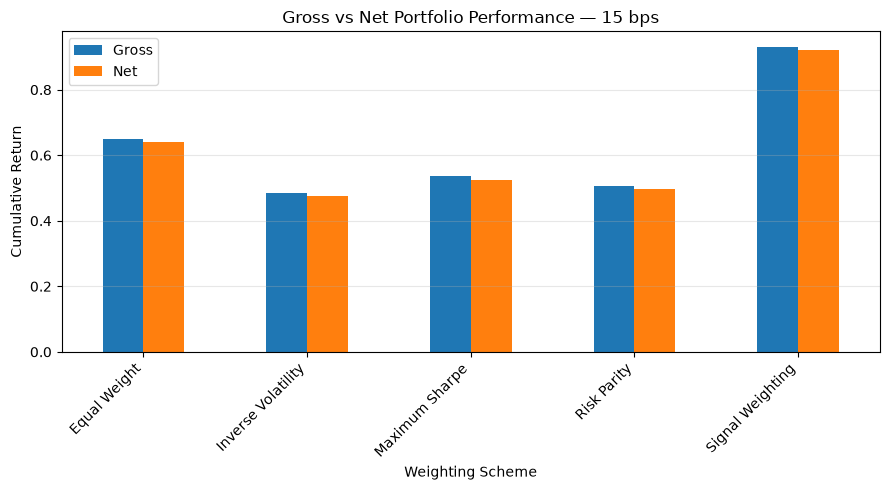

In [59]:
# =============================================================================
# Gross vs Net Performance by Weighting Scheme
# =============================================================================

table_1["weighting_scheme"] = table_1["portfolio"].apply(extract_weighting_scheme)

plot_data = (
    table_1
    .groupby("weighting_scheme")[
        [
            "gross_return",
            "net_return_base",
        ]
    ]
    .mean()
)

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Gross vs Net Portfolio Performance — 15 bps"
)

ax.set_ylabel(
    "Cumulative Return"
)

ax.set_xlabel(
    "Weighting Scheme"
)

ax.legend(
    [
        "Gross",
        "Net"
    ]
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

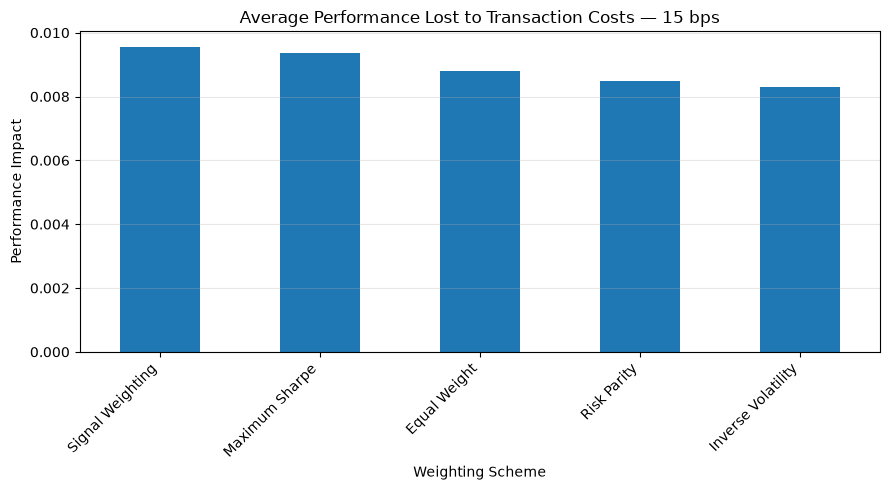

In [60]:
# =============================================================================
# Friction Cost by Weighting Scheme
# =============================================================================


table_1["weighting_scheme"] = table_1["portfolio"].apply(extract_weighting_scheme)

friction_plot = (
    table_1
    .groupby("weighting_scheme")[
        "friction_impact_base"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)


ax = friction_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Average Performance Lost to Transaction Costs — 15 bps"
)

ax.set_ylabel(
    "Performance Impact"
)

ax.set_xlabel(
    "Weighting Scheme"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

## 11. Conclusions & Transition to Portfolio Performance Analysis

El análisis del impacto de los costes de transacción y la rotación de activos sobre la muestra out-of-sample permite extraer tres conclusiones metodológicas y operativas fundamentales antes de la evaluación económica final:

1. **Magnitud de la Fricción Operativa:** La aplicación del modelo de costes all-in en el escenario base ($15\text{ bps}$) evidencia que la intensidad de rotación varía según el esquema de optimización utilizado. Mientras que las estrategias ponderadas por señal e igual ponderación mantienen un *turnover* contenido, los enfoques de optimización media-varianza (*Maximum Sharpe*) registran un desgaste operativo sensiblemente mayor, consumiendo una fracción superior de la rentabilidad bruta.

2. **Estanqueidad y Ausencia de Look-Ahead Bias:** La arquitectura del motor de ejecución —con un desfase estricto de una sesión ($t_k + 1$) entre la generación de la señal analítica y la efectividad operativa de los pesos— garantiza un marco de simulación libre de contaminación por anticipación de datos y completamente reproducible.

3. **Consolidación del Dataset Neto:** Con la generación y exportación del archivo `net_portfolio_returns.parquet`, queda completada la fase de construcción y filtrado operativo de las series temporales. Las curvas de patrimonio resultantes reflejan la rentabilidad real disponible para un inversor tras descontar el impacto del *slippage* y la ejecución de órdenes.


Con los datos de rentabilidad neta consolidados para todos los escenarios de costes, la evaluación económica, la comparativa frente a los *benchmarks* de mercado, el análisis de estabilidad por subperiodos y los test de sensibilidad se desarrollan íntegramente en el **Notebook 09: Portfolio Performance & Sensitivity Analysis**.